# ``EARLY DETECTION OF DEPRESSIVE DETERIORATION BASED ON BEHAVIORAL DATA``

### Structure and Content:
**I. The Problem**
- Section 0 — Problem Formulation

**II. Understanding the Dataset**
- Section 1 — Dataset Validation

**III. Data Preparation**
- Section 2 — Construction of the Individual Baseline
- Section 3 — Intra-subject Z-score
- Block 4 — Time Series
- Block 5 — Feature Engineering

**IV. Modeling**
- Block 6 — Modeling and Characterization of the Alert

**V. Evaluation**
- Block 7 — System Validation
- Block 8 — Individual Analysis and Trajectories by Type

---

## ``I. The Problem``

<h2>Block 0:  Problem Statement</h2>


Depression is one of the most prevalent and disabling mental disorders worldwide. According to the WHO, it affects more than 280 million people and is projected to be the leading cause of global disability by 2030. However, despite decades of clinical research, it remains a disorder with an unresolved structural problem: **it is detected late**, and people who are or have been in treatment **experience relapses** that cause them to temporarily lose their well-being and mental health.

The standard clinical assessment of depression is based on validated psychometric instruments, with the **PHQ-9** and the **BDI-II** being the most widely used. The PHQ-9 is a 9-item self-report questionnaire, developed by Kroenke, Spitzer, and Williams in 2001, which directly assesses the nine DSM diagnostic criteria for major depressive disorder. The individual indicates how frequently they have experienced each symptom over the **past two weeks**, on a scale from 0 to 3. The BDI-II, developed by Beck and colleagues, is a 21-item instrument with the same time frame and response range. Both instruments have robust psychometric properties, are widely validated across different populations and cultures, and serve as standard tools in both clinical practice and research.

The problem is not that these instruments are flawed. The problem lies in what they are designed to do—and what they are not. They are designed to measure the severity of symptoms at a given point in time, once those symptoms are already sufficiently noticeable for the person to report them. They are not designed for early detection, nor can they be by their very nature: they are point-in-time, episodic, and rely entirely on self-report.

Self-reporting has structural limitations in this context. For the instrument to work, the person must perceive their own symptoms, recall them accurately over a two-week period, and be willing to report them honestly. None of these conditions is reliably met in depression. Early deterioration occurs gradually and below the patient’s threshold of awareness. Retrospective memory spanning two weeks is subject to documented systematic biases. Furthermore, the stigma associated with the disorder causes self-reports to consistently underestimate actual severity: experimental research using the BDI-II has shown that both men and women report significantly more depressive symptoms when the purpose of the questionnaire is masked, suggesting that community surveys underestimate the actual prevalence.

> **Implications for validation:** If behavioral detection and self-report do not align, this does not prove that detection is failing. It may mean that the behavioral signal captures something that self-report does not, or that it captures it with a delay. This ambiguity is an expected consequence of comparing a continuous, objective signal with a point-in-time, subjective measure.

There is a specific clinical gap: there is a period of progressive deterioration, observable in behavior, that current systems do not capture. During that period, an “early intervention” would be more effective than any reactive intervention. This project addresses that gap.





### 0.1. What Has Been Tried and Why It Hasn’t Worked

Over the past decade, a field of research has emerged that seeks to leverage passive data from smartphones and wearables to monitor mental state continuously and noninvasively. Initial studies between 2014 and 2019 showed promising correlations between location, activity, sleep, and mobile phone usage signals and clinical measures of depression. However, they all shared a serious methodological limitation: small samples, short time periods, and evaluation using the same training data. The published results were optimistic but not generalizable.

To address this issue, a team of researchers at the University of Washington developed the **GLOBEM** (*Generalization of Longitudinal Behavior Modeling*) dataset, currently the most comprehensive and rigorous reference in the field of longitudinal modeling of human behavior for mental health. GLOBEM comprises four consecutive annual studies from 2018 to 2021, each lasting ten weeks, with **705 person-years and 497 unique participants**—undergraduate students recruited with intentional overrepresentation of minority groups. Each year, participants installed an app on their cell phones and wore a Fitbit, which passively collected data on activity, sleep, location, screen time, calls, and Bluetooth proximity. At the same time, they completed weekly questionnaires on depressive symptoms and underwent clinical assessments at the beginning and end of each study.

What makes GLOBEM particularly valuable is not only its size but also its design: with four years of data from different cohorts, it allows researchers to assess whether models generalize not only across individuals but also across different years and contexts, including the impact of COVID-19 on the 2020 data and the gradual recovery in 2021. It is the first public dataset that allows for rigorous measurement of the generalization of behavioral detection algorithms on a multi-year scale.

The benchmark results are compelling:

- **18 algorithms** evaluated: the 9 most-cited depression detection models in the literature + 8 domain generalization algorithms
- The best algorithm achieves **54.7% accuracy** on unseen data—just 9.7 percentage points above always predicting the majority class
- The difference compared to results published in the original papers: **an average of 18.9 percentage points**

The authors themselves identify the cause: **individual differences are likely the most decisive factor in the failure**. What is a sign of deterioration for one person is the normal state for another. A model trained to compare people against one another cannot capture that.

There is, however, a second problem that the benchmark does not address: that of the target variable. The 18 algorithms evaluated used scores from self-report questionnaires—the PHQ-4 and BDI-II—as their target, as if these were a reliable measure of deterioration. But these labels do not describe a process: they describe how someone feels at a given moment, once symptoms are already sufficiently noticeable to be reported. Predicting that label is not the same as detecting the progressive change that precedes it. Added to this is a problem of temporal resolution: the PHQ-4 was administered continuously throughout the study, while the BDI-II was collected only once at the end. Using them as if they were equivalent to construct the target introduces methodological noise, because they are not measuring the same thing or at the same time. This problem is independent of the issue of generalization, and this project addresses it separately.



### 0.2. Within-subject approach with longitudinal data

If the problem is that every person is different, the solution isn’t to train more sophisticated models. It’s to change the question. Instead of asking *“Does this person match the profile of someone with depression?”*, the correct question is: **“Is this person deviating from their own usual pattern of functioning?”**

Comparing each person to themselves rather than to the group: that is the **within-subject approach**.

This isn’t an entirely new idea. Some studies have begun building individual models or normalizing signals relative to each person’s historical average. Research in digital phenotyping explicitly points to personalization as one of the most promising directions. But these approaches maintain a classificatory focus: they continue to predict whether or not someone has depression using the clinical label as the target.

``What this project proposes`:

**To detect and quantify deviation from the individual baseline as a warning sign in and of itself**, **without the need for a clinical label**. The system does not end with a prediction. It ends with a decision.

When is the deviation sustained enough to warrant intervention?

The difference between *“this person probably has depression”* and *“this person has been deviating from their usual pattern for two weeks in a way that warrants attention”*.

### 0.3. Practical Implications and Transferability

This system is not designed to be integrated as a functional layer within actual digital health platforms.

**Direct Application to Existing Platforms**

The digital mental health market has grown significantly in recent years. Mental health companies and platforms such as Wysa, Headspace, Meru Health, and Woebot offer interventions based on cognitive-behavioral therapy, mindfulness, and emotional support, combining chatbots with access to professionals. Some integrate data from wearables and passive mobile sensors. These platforms already collect usage data: session frequency, access times, interaction patterns, and duration of use. What they lack is a system that automatically detects when a user is beginning to deviate from their baseline behavior, thereby enabling an intervention before deterioration becomes entrenched.


**Transferability to Other Domains**

But the system’s scope extends beyond mental health. The logic developed here—individual baseline, measurement of sustained deviation, convergence between behavioral dimensions, and intervention threshold—is transferable to any domain of digital health where signaling and early detection of change have practical value.

Psychology and depression are the application domains of this project. The system being developed is more general in nature. 

### 0.4. Context and Objective

#### Definition of Behavioral Deviation from the Baseline

Before establishing any baseline, before calculating any deviation, before choosing any algorithm, there is one decision that determines everything else: what exactly we mean by behavioral deviation.

The relevant question is not which label is available, but **what process we want to capture and how it manifests in the data before it becomes clinically evident**.

That process cannot be observed directly. There is no single variable that indicates deterioration. What is available are passive behavioral signals: physical activity, mobility, sleep patterns, and device usage. Each of these can change for many reasons unrelated to deterioration. A drop in activity may be due to an injury. A change in sleep may be due to temporary stress or travel. An increase in cell phone use may be associated with work or leisure. None of these signals, taken in isolation, allows us to reliably infer behavioral deviation.

The real challenge is not identifying changes in individual variables, but **distinguishing between normal behavioral variability (noise) and changes that reflect an actual impairment in a person’s functioning (signal)**.

For this distinction to be defensible, the definition of behavioral deviation must meet three conditions, which are discussed in detail in the following sections:

- **Relative to the individual baseline.** What matters is not the absolute level of a variable, but its deviation from that person’s usual pattern. The system does not compare individuals to one another, but rather each individual to their own baseline over time.

- **Convergent.** Behavioral deviation is not defined by a change in a single dimension, but by the simultaneous occurrence of changes across multiple behavioral dimensions. The combination of signals reduces the likelihood of alternative explanations based on a single, isolated cause.

- **Persistent.** One-off changes are part of normal behavior. For a signal to be interpretable, it must persist long enough to rule out noise or transient events.

These three conditions do not completely eliminate sources of confusion, but they allow us to construct an operational definition that is robust against them without the need to explicitly model each alternative cause.

Based on this definition, behavioral deviation is no longer understood as a static label but is instead conceptualized as a **dynamic process**: a sustained change in a person’s functioning pattern, observable through the combined evolution of their behavioral signals.

In this context, clinical questionnaires such as the BDI are used to provide an external reference for identifying a deviation. Their role is to provide an external reference (acknowledging that it is imperfect) to support the clinical diagnosis. They cannot serve as the ultimate truth, but rather as one additional element in the system’s evaluation.

What this project constructs is a **behavioral definition of impairment based on longitudinal data**, independent of direct clinical labels and aimed at detecting changes before they are formalized in a clinical measurement.

What follows is the explicit development of that definition and its translation into an operational framework.

#### **Analysis of Confounders by Behavioral Dimension**

Before defining what constitutes a behavioral deviation, we must understand what else might produce the same patterns in the data. Every available signal is subject to alternative causes unrelated to decline. If these are not identified and their impact on the definition is not taken into account, the system will detect real changes but misinterpret their origin.

The following analysis does not aim to eliminate each contaminant one by one. That would be impossible with the available data. The goal is to understand the nature of the noise in each dimension, in order to design a definition that is robust against it by design.

**Physical Activity and Mobility**

A decline in physical activity may be due to a specific illness, injury, accumulated fatigue, periods of heavy academic or work load, bad weather, or simply days of intentional rest. A reduction in mobility may reflect remote work, vacations, schedule changes, or more home-centered personal habits without any correlation to deviation.

The conceptual problem here is that less activity does not automatically mean apathy or functional withdrawal. It may indicate fatigue, illness, or a change in circumstances. This dimension alone has low specificity.

**Sleep and the Regularity of Daily Patterns**

Sleep is the most sensitive indicator of the group, but also the one most susceptible to external factors. Illness, occasional stress, exams, travel, jet lag, caffeine, alcohol, or medication, shift work, or simply weekends can disrupt sleep patterns without any underlying health issues. Irregular rhythms may simply reflect a less structured lifestyle due to external factors.

**Passive Use: Nighttime Screen Behavior**

An increase in nighttime cell phone use may be due to work, study, leisure, watching TV shows, changes in digital habits, or periods of insomnia unrelated to emotional distress. More nighttime screen time is not necessarily a sign of circadian activation altered by a clinical condition.

**The conclusion that frames everything that follows**

None of these dimensions, when analyzed independently, allows for a reliable inference of impairment. This does not invalidate the signals; it invalidates the approach of looking at them separately. The definition of deterioration must emerge from the combination of signals, designed so that it is difficult to explain by isolated alternative causes.



#### **The Three Criteria: Persistence, Convergence, and Individual Baseline**

The three criteria that structure the definition of behavioral deviation are not arbitrary conventions. They are direct responses to the problem of contamination identified in the previous section. Each criterion eliminates a class of noise that the others do not cover.

**Persistence**

A change lasting one or two days in any behavioral dimension could be anything: a bad day, a one-time illness, a different weekend. No system that triggers alerts for changes of this duration would be of practical use because it would constantly generate false alarms.

Temporal persistence requires that the change persist for at least **5 consecutive days** to be considered relevant. This threshold is not arbitrary. It is long enough to filter out most one-off “contaminants.” And it is short enough to be proactive: the DSM-5’s clinical criterion for a depressive episode requires two weeks. This system aims to detect what happens before that threshold is reached.

Persistence alone is not sufficient. A prolonged cold can also last 5 days and reduce activity. That is why it must be combined with the other two criteria.

**Convergence Across Dimensions**

If only one dimension is affected for 5 days, there are still too many possible alternative explanations. An injury can reduce activity and mobility for weeks without any emotional impairment. A period of exams can disrupt sleep in a sustained manner.

Convergence requires that the change be simultaneous across **at least two of the three behavioral dimensions**: arousal, sleep, and passive use. When two dimensions are altered at the same time in a sustained manner, the probability that a single, isolated cause explains everything decreases significantly.

Convergence is required in two out of three, not all three, for two reasons. 

**First**: the dataset contains measurement noise. There are days when the wearable wasn’t worn or the sensor malfunctioned. Requiring all three dimensions would always mean losing real cases due to technical failures. 

**Second**: a behavioral deviation due to possible decline does not manifest universally. For some people, the first sign is sleep. For others, it is activity. Requiring all three at once would replicate the same error found in population-based models: assuming that everyone declines in the same way.

**Deviation from the Individual Baseline**

The two previous criteria are based on relative changes, not absolute values. This requires a reference point. That reference cannot be the group average because people differ greatly from one another: some people sleep very little, and that is their normal state; others are very sedentary, for whom this represents no change at all.

The individual baseline is each person’s recent typical pattern of functioning, calculated on a rolling basis over the days preceding each assessment point. Deviation is not measured against an external standard, but against each individual’s own standard, which is updated based on their recent history rather than being fixed at the start of the record.

This criterion is what makes the system intra-subject by design. It does not compare people. It compares each person to themselves over time.


**The three criteria work together**

None of the three criteria is sufficient on its own. Persistence without convergence detects sustained changes in a single dimension, which may have clear alternative explanations. Convergence without persistence detects isolated coincidences between dimensions, which may be noise. The individual baseline without the other two criteria simply measures variability, without distinguishing whether it is relevant.

It is the combination of all three that produces a signal that is more difficult to explain by alternative causes and that is consistent as an indicator of possible actual functional decline.

#### **Formal Operational Definition**

Based on the above analysis, the operational definition guiding this project is as follows:

**Behavioral deviation = a deviation sustained for at least 7 days relative to the rolling individual baseline, converging in at least 2 of the 3 behavioral dimensions: arousal, sleep, and passive screen use.**

This definition has four properties that should be made explicit. 

**It is relative, not absolute.** There is no single level of activity, sleep, or screen use that constitutes a deviation in and of itself. What matters is the deviation from each person’s own normal pattern.

**It is behavioral, not clinical.** It does not depend on diagnostic labels or self-reports. It is constructed entirely from passive, longitudinal signals. Scores from questionnaires such as the PHQ or BDI are not part of the definition: they serve as an external reference to validate the system, not to construct it.

**It is dynamic, not static.** It does not label a person as impaired or non-impaired at a given moment. It describes a process: the sustained change in a person’s functioning pattern over time.

**It is operational with the available data.** Each of its components—rolling individual baseline, deviation by dimension, temporal persistence, and convergence across dimensions—can be calculated directly from the features provided by the GLOBEM dataset via RAPIDS.

What this definition does not guarantee is that all detected cases of behavioral deviation constitute clinical deterioration in the diagnostic sense. What it does guarantee is that the detected cases are unlikely to be explained by isolated confounders, and that when they do not align with self-reports, the first reasonable hypothesis will not be that the system is failing, but rather that it is detecting something the BDI has not captured accurately.

This definition does not translate directly into a binary classification. The system does not produce merely a “deviation” or “no deviation” label, but rather a continuous deviation index relative to the individual rolling baseline, constructed based on the intensity, persistence, and convergence of behavioral signals.

This index captures the gradual nature of the process being detected. A mild deviation in two dimensions over a few days is not equivalent to an intense, sustained, and convergent deviation across multiple dimensions. The continuous representation preserves this information and allows for the analysis of how the person’s condition evolves over time.

The decision to intervene does not stem directly from applying a trigger threshold to an index, but rather from the clinical interpretability of that trigger. This approach separates the measurement of the phenomenon from the decision-making process, which is more consistent with a system geared toward monitoring and early deviation detection.

This definition is the starting point for everything that follows. From here, the task is to translate it into code.

#### **The Problem of a Contaminated Baseline**

Defining how the baseline is constructed introduces a conceptual problem that affects the entire system: if the individual baseline is calculated over a period during which the person was already in transition, the system will measure deviations relative to a shifted baseline, which may cause relevant changes to be attenuated or go unnoticed.

There is no perfect solution to this problem with the available data. There is no label certifying that a person was in a normal functional state at any point in the record. Therefore, the baseline cannot be defined as a “healthy period,” but rather as the best available proxy for normality under this constraint.

The approach adopted is based on two structural decisions.


**First: rolling baseline over the previous 21 days**

The baseline is constructed on a rolling basis. For each person and each “day d” within the detection window, the individual baseline is the pair (mean, standard deviation) calculated over the 21 days preceding “day d.” The reference is updated over time rather than remaining fixed at the start of the record.

The rationale is structural: behavioral time series obtained using passive sensors are not stationary over short windows. Their statistical properties (mean, variance) change with the individual’s context—such as academic routines, exam periods, seasons, and specific life events—without these changes necessarily reflecting behavioral deviation. Assuming stationarity would imply measuring deviations against a snapshot of the past that may no longer be representative of the participant’s current context.

The literature on digital phenotyping explicitly documents this non-stationarity and agrees that the individual reference must be dynamic to capture the participant’s recent context (Aledavood et al., 2025).

The operational consequence is that the participant’s “normality” is redefined day by day based on their previous 21 days. If the person goes through a different phase, their baseline adjusts accordingly. If the change is real and sustained, the persistence and convergence criteria (discussed in the following sections) are what trigger the alert before the rolling baseline has had time to absorb the deviation as a new normal pattern.

**Second: Moving-Window Coverage Criterion**

For the rolling baseline of a specific day to be reliable, the preceding 21 days must include at least 15 days with a non-zero value (≥70% coverage). If a specific day does not meet this criterion, that day is classified as “not evaluable” in that dimension and is omitted from the convergence and persistence calculations for that day. If coverage improves on subsequent days, the participant becomes evaluable again.

The detectability decision is no longer a static classification of the participant (fully detectable, partially detectable, or undetectable), but rather a dynamic property of the person-day pair: each day d may or may not be evaluable in each dimension, depending on the coverage of the preceding 21 days. The 2/3 convergence rule across dimensions applies only to days on which the participant has at least 2 evaluable dimensions.

**Main Risk of the Rolling Baseline: Absorption of Gradual Deterioration**

If a person deteriorates gradually, their rolling baseline also decreases along with it, and the point z-score never triggers an alert because the baseline adjusts to the deviation. This is the most serious conceptual risk of the rolling baseline, and it is mitigated by design through three layers: 

1. The 5-day persistence rule triggers an alert when the z-score remains deviant for 5 consecutive days, which in many cases occurs before the rolling baseline has had time to absorb the change.
2. The 2/3 convergence rule makes it unlikely that the rolling baseline will absorb the drift at exactly the same rate in two dimensions simultaneously.
3. The validation methods to be developed in Block 7 (CUSUM, EWMA) detect slow structural changes that the point z-score versus the rolling z-score might fail to flag.

**Additional layer considered: initial filter using a clinical scale**

Rolling baseline does not detect individuals who entered the study already in a stable pathological state. Their preceding 21 days may appear stable because the pathology is already established, not because the individual is healthy. To mitigate this scenario, an additional layer is considered, based on a clinical scale measured once at the start. The distinction is important: the scale is not used as a model target (which the project explicitly rejects, because such tests reflect already established states and the goal is to anticipate them), but rather as an initial exclusion filter. 

The system does not make any predictions based on the test. It uses it only once to answer a specific question: Does this person begin the study in an already established pathological state? If so, their behavioral baseline is contaminated, and they are redirected to a specific “not detectable” category. If not, their behavioral baseline enters the normal pipeline. This use as a filter does not contradict the project’s philosophy—it reinforces it.

The instrument available at the start in INS-W_1 is the CES-D (Center for Epidemiologic Studies Depression Scale), recorded in `pre.csv` for 153 of the 155 cohort participants (the remaining 2 do not have a “pre” record; see Block 1). It is a validated scale for depressive symptoms.


#### **Mapping Signals to Behavioral Dimensions**

The definition of behavioral deviation operates across three dimensions: **arousal**, **circadian rhythm**, and **passive cell phone use**. Each dimension is derived from specific sensors in the GLOBEM dataset. Before constructing the baseline, it is necessary to specify which signals in the dataset correspond to each dimension and the logic used to group them.

**Arousal: physical activity and mobility**

This dimension captures the level of motor arousal and the extent of the person’s living space. It is derived from two sensors:

- **Steps (Fitbit):** daily steps, duration of active and sedentary episodes, and activity variability. The central signal is the ratio of active to sedentary time and how it changes relative to the individual’s usual pattern.
- **Location (mobile app):** distance traveled, turning radius, number of places visited, time spent away from home. The key metric is the contraction or expansion of the living space relative to the baseline.


**Circadian Rhythm: Regularity of Temporal Patterns**

This dimension captures the stability of a person’s circadian rhythms, primarily through sleep.

- **Sleep (Fitbit):** total sleep duration, sleep efficiency, bedtime and wake-up time, time spent awake during the night, and number of sleep episodes. The key indicator is not how much a person sleeps in absolute terms, but whether their sleep pattern is becoming more irregular, more fragmented, or more shifted relative to their baseline.

**Passive Use: Screen Behavior**

This dimension captures the pattern of interaction with the mobile device, especially in contexts and at times that may indicate disruption.

- **Screen (mobile app):** number of unlocks, total usage duration, first use after midnight, and usage segmented by location context (at home, in study area, in exercise area). The key indicator is an increase in nighttime usage and a change in the distribution of usage by context relative to the baseline.

**Exclusion Criteria**

The following are excluded from the core of the project: **call** (too scattered, as many participants do not make calls, so NaN can mean either missing data or a lack of activity), **Bluetooth** (measures nearby devices rather than actual social interaction: signal too noisy for the system’s purpose), and **Wi-Fi** (96.8% of values are missing, rendering the data unusable).

**Note on Feature Versions**

The dataset provides each feature in three versions (raw, discretized, and normalized) and in two time windows (7 days and 14 days). The project works with the raw version and the 7-day window: the 14dhist features require 14 days of valid prior data to be calculated, which results in massive amounts of NaN values during the first 13 days of the record. The 7dhist features have a 6-day warm-up period, so they offer better effective coverage for the pipeline. The choice of feature window is independent of the rolling baseline size, which is decided separately in Block 2 (21 days).

#### **Scientific Framework and Statistical Methodology**

**Scientific Framework: Longitudinal observational N-of-1 design.**

N-of-1 is a scientific design in which the unit of analysis is the individual, studied through repeated measurements over time. Rather than comparing groups to draw conclusions about a population, it examines how each person changes over time relative to their own baseline. There are decades of literature on this approach in clinical psychology (single-case experimental designs) and in personalized medicine. The question that defines the project—“Is this person deviating from their own pattern?”—is pure N-of-1. It is not a population-based approach in disguise.

**Statistical technique: Statistical Process Control with modern extensions.**

The system’s operational logic (establishing a baseline, measuring deviation, distinguishing signal from noise, detecting sustained change, deciding on intervention) aligns point by point with the SPC developed by Walter Shewhart in the 1920s. The difference is that behavioral signals have properties that industrial signals do not: autocorrelation, weekly seasonality, contextual drift, missing data, and non-stationary series in short windows. 

That is why Shewhart’s “textbook” approach is not applied. Adapted versions are used: individual rolling baselines instead of population-based or fixed ones, intra-subject z-scores against the rolling baseline for a specific day, a multi-day persistence criterion, convergence across dimensions, and modern tools such as CUSUM and EWMA to capture slow drifts that a point z-score compared to a rolling baseline might not flag.


---

# ``II. Understanding the Dataset``

<h2>Block 1: Dataset Validation · Coverage · Feasibility</h2>

Before building any technical component, there is one question that needs to be answered: Does the available dataset actually allow us to address the problem as it has been framed? Validating the dataset is not merely a matter of verifying that the signals have sufficient coverage, adequate temporal resolution, and the necessary structure to answer the project’s research question.

The outcome is a binary decision: the dataset is suitable for the project, or it is not. In this case, the answer is yes, but this assertion must be demonstrated.

The GLOBEM dataset collects passive signals via Fitbit and a mobile app based on the AWARE framework, which captures location, screen status, calls, and Bluetooth activity. The Fitbit tracks activity and sleep. The signals were processed using **RAPIDS**, a feature extraction tool for passive sensing data, which generates aggregated variables with different time windows and time slots.

The four core signals of this project are **physical activity, sleep, mobility, and screen behavior**. This selection is supported by direct empirical evidence from the dataset itself:

- According to the correlation analysis of the GLOBEM dataset itself, **sleep duration** over the past two weeks and the **number of screen unlocks during the night** are the signals with the strongest correlation with depression scores.

- Analysis of the dataset indicates that participants with higher scores tended to have **less physical activity, lower mobility, and more time spent at home**.

- The literature supports reduced motor activity as a risk indicator preceding clinical symptoms, and nighttime screen use as a marker of circadian disruptions associated with the onset of depressive symptoms.

These four signals can be observed passively, continuously, and without burden to the participant, and they have **interpretable behavioral significance**. 

### 1.1. Cohort Selection

GLOBEM publishes four annual cohorts (INS-W_1, INS-W_2, INS-W_3, INS-W_4). The project works exclusively with **INS-W_1** for three reasons:

- It is pre-COVID, which ensures a behavioral context free of massive external distortions. COVID introduces a structural change in mobility, sleep, and screen-use patterns that confounds the signal of individual decline with the signal of an external shock common to the entire cohort.
- The intra-subject approach must first be tested in a “clean” environment before being extended to contexts with distortion.
- Each cohort is self-contained: 92 consecutive days of observation, with complete sensor data and questionnaires. There is no need to combine cohorts to obtain a viable working sample.


### 1.2. Verified Data from INS-W_1

The cohort contains **155 unique participants** with **92 days of observation per participant**. The unit of analysis is the person-day pair (`pid-date`). The identifiers range from `INS-W_001` to `INS-W_208` with gaps (they are not consecutive), which is common in studies involving real-world recruitment and partial dropout.

All participants began the study on the same day: **2018-04-03**. This property is relevant because it allows us to work with a common relative time axis (day 0, day 1, ..., day 91) without the absolute temporal position confounding the analysis.

The dataset is sorted by design: `pid` in ascending order and, within each `pid`, `date` in ascending order.


### 1.3. Warmup of Pre-Aggregated Features

GLOBEM provides pre-aggregated features with different time windows. The `14dhist` features require 14 days of valid data prior to calculation, which results in massive NaN values for the first 13 days of each participant. The `7dhist` features have a 6-day warmup period.

The project uses **7dhist** features for two reasons: the warmup period is shorter (6 days versus 13), and the effective coverage of participants within this window is substantially better. This choice is not merely a matter of preference: it is the difference between having a viable dataset and having a dataset in which half the participants are unusable due to excessive warmup.


### 1.4. Coverage by Dimension

For days 7–91 (post-warmup), applying a reasonable coverage threshold (≤30% NaN), the number of participants with sufficient data per dimension is:

- Sleep: 110 / 155
- Steps: 117 / 155
- Screen: 143 / 155
- Location: 149 / 155
- All four dimensions simultaneously: 103 / 155

These figures correspond to the coverage of the raw data. They do not yet represent the effective coverage of evaluable person-day pairs in the final system: that additional filter—which is dynamic by day and by dimension—is applied in Block 2 when the rolling baseline is constructed using its moving-window coverage criterion.

The critical figure is the last one: **103 participants** have sufficient simultaneous coverage across the four behavioral dimensions. This number allows for statistically meaningful analysis without being so small as to compromise generalizability within the cohort itself.


### 1.5. External Validation Datasets

The project does not use any clinical labels as model targets (that decision is finalized in Block 0). However, before ruling out all external references, the clinical sources available in the cohort are examined to verify which ones exist and which ones meet the criteria for subsequent comparison in the evaluation blocks:

- **dep_endterm.csv**: 142 PIDs. Contains BDI2, a single measurement at the end of the study (mean 12.8, std 10.2). It is the cleanest clinical measurement in the dataset and the only one that will be used as an external benchmark in the evaluation blocks.

- **dep_weekly.csv**: 2,360 rows, 154 PIDs. Its BDI2 contains 94% missing values, rendering it unusable as a temporal reference.

- **ema.csv**: 4,789 rows, 195 PIDs. The variable `negative_affect_EMA` (scale 0–20) was collected several times a week at the time. It is temporally aligned with the alerts, but its comparison with them does not yield a signal, so it is not used as a benchmark either.

Of the sources examined, only dep_endterm meets the conditions for comparison: a clean clinical measurement, albeit a single point-in-time measurement taken at the end of the study. This nature (single point-in-time and late) is consistent with the criticism of self-reporting raised in Block 0, and it explains why a weak association with the alerts does not refute the system. The remaining sources are ruled out as external benchmarks.


### 1.6. Project Timeline

Combining the warm-up of the 7dhist features, the cleaning of days 0–6 (described in section 1.4), and the design of the rolling baseline for Block 2, the project timeline for INS-W_1 is as follows.

Before detailing it, it is important to understand a characteristic of the baseline that determines when evaluable days begin. Each primary feature is a 7-day moving sum: the value for a given day is not the data for that day, but rather the sum of that day and the 6 preceding days. Therefore, two consecutive days share 6 of those 7 days of data. If a day’s baseline were calculated using the days immediately preceding it, it would include data that is also part of the very observation being compared to it, and the comparison would be skewed (the day would resemble its baseline only because they share data, not because the behavior is stable). 

To avoid this, we’ll use a **buffer**—that is, we’ll leave a 7-day gap between the end of the baseline and the evaluated day: the baseline for day d does not use the 21 days preceding d, but rather the 21 days ending 7 days before d. As a result of this gap, the baseline window for day d consists of the days ranging from d-28 to d-8. The detailed technical justification is expanded upon in Block 2.

With that, the timeline looks like this:

- **Days 0–6**: warm-up of the 7dhist features. After the pre-rolling cleanup, all days 0–6 are set to NaN.

- **Days 7–27**: Initial accumulation. There are still no evaluable days: rolling with a buffer requires 15 non-zero values in the window [d–28, d–8], and that condition is only met starting on day 28.

- **Day 28**: first evaluable day. Its rolling baseline is calculated over days 7 through 21 (15 consecutive clean values), which is the first time that min_periods=15 is met.
Days 28–91: effective detection window. 64 days per participant during which the system can assess intra-subject deviation.

The number 28 represents the first evaluable day as a theoretical threshold (when individual coverage is complete). For participants with lower coverage on days 7–21, the first actual evaluable day may occur later.

### 1.7. Completion of Block 1

- **Decision**: Work exclusively with the GLOBEM INS-W_1 cohort (155 participants, 92 days, pre-COVID), using the 7dhist features due to their shorter warm-up period and better coverage, with 103 participants having simultaneous data across all four behavioral dimensions and an effective detection window of 64 days per participant.

- **Exclusion**: The INS-W_2, INS-W_3, and INS-W_4 cohorts (COVID and post-COVID contexts) and the 14dhist features (excessive warm-up and poorer coverage) are excluded. The use of the weekly BDI2 is also excluded due to its 94% rate of missing values.

- **Real-world application**: On a digital health platform, this block corresponds to the initial feasibility audit before committing resources to development. It demonstrates that the available data source has the necessary density, duration, and structure to support the construction of an intra-subject detection system. Without this step, everything that follows is speculation.

- **Trade-off**: A small but clean cohort is prioritized over a larger sample with external distortion. A rolling baseline with a buffer and pre-cleaning of the warm-up period (free from contamination by partial sums) is also prioritized in exchange for the first 28 days of each participant’s data as the onboarding period. The project sacrifices volume and duration in exchange for internal validity.


---

# ``III. Data Preparation``

<h2>Block 2: Construction of the Individual Baseline</h2>

### 2.1. What Is the Baseline and Why Is It the First Technical Component of the System

Everything the system must do—measure deviation, detect persistence, and evaluate convergence—requires a reference. That reference is the baseline: each person’s recent typical pattern of behavior, estimated from their own data.

The baseline is not a single number. For each person, each behavioral signal, and each day d within the detection window, the baseline is a pair of statistics: the mean and the standard deviation calculated over the 21 days preceding day d. The mean captures the recent typical level. The standard deviation captures how much variability is normal for that person at that time. Both are necessary: without the mean, there is no reference point, and without the standard deviation, it is impossible to distinguish a real change from normal fluctuation.

The individual reference is updated over time rather than being fixed at the start of the recording. This decision, central to the baseline design, adapts the idea of a “usual pattern” to the reality of human behavior observed by sensors: it is not stationary over short time windows, especially for context-sensitive variables.

This decision has a direct implication for how deterioration will be measured in the following section 3. The intra-subject z-score is the system’s central metric. It is calculated as the distance between the current value and the mean of the rolling baseline, divided by the standard deviation of the rolling baseline, on each specific day d. Each person has their own scale, and that scale is updated based on their recent history. 

### 2.2. Which Signals Are Included in the Baseline

Each behavioral dimension is represented by a **primary feature**: the most direct, interpretable signal with the best empirical coverage within that dimension.

``Activation`` (physical activity and mobility)
- **Steps**: total number of steps in the window (primary feature).
- **Location**: time spent away from home or radius of movement (primary feature).

``Circadian rhythm`` (regularity of temporal patterns)
- **Sleep**: total duration of the main sleep episode (primary feature).

``Mobile phone use`` (screen behavior)
- **Screen**: total screen time (primary feature).

The remaining 7dhist features for each sensor are present in the dataset but are not used: the project works with a single primary feature per dimension throughout all its phases. For the baseline, the goal is to find a clean and stable signal for each dimension; mixing multiple features here introduces noise and makes interpretation difficult when something deviates.


### 2.3. Rolling Window Coverage Criterion

The rolling baseline for a given day requires sufficient valid data so that the mean and standard deviation are reliable estimates. The operational criterion is established as follows:

**Minimum coverage.** At least 15 of the 21 days must have a non-zero value (≥70%). If a given day d does not meet this condition, the rolling baseline is not calculated for that day, and the observation is marked as non-evaluable in that dimension. On subsequent days, if coverage improves, the participant becomes evaluable again.

Operationally, this criterion translates to `min_periods=15` within the rolling operation: pandas calculates the mean and standard deviation only if there are at least 15 non-zero values in the window, and returns `NaN` otherwise.

**Structural buffer** of 7 days between the baseline and the observation. The project’s primary features are 7-day moving sums (`7dhist`): the value for day d covers the 7 days ending on d. Without a buffer, the last 7 values of the rolling baseline would partially overlap with the 7 days covered by the observation, artificially attenuating the z-score. To avoid this, the rolling calculation is applied with a 7-day offset: for day d, the baseline is calculated over the days [d-28, d-8], not over the days [d-21, d-1]. The operational consequence of this, combined with the prior cleaning of days 0–6 (Section 1.4), is that the first evaluable day for each participant is day 28: after cleaning days 0–6, the first 15 available cleaned values are days 7–21, and the window [d–28, d–8] contains them when d = 28.

No slope stability filter is applied. The reason is structural: with a rolling baseline, a transition during a 21-day window does not permanently contaminate the baseline; rather, it shifts the baseline itself and is absorbed into the recent typical level.

No absolute variance threshold is set. Some people are naturally highly variable, and that is their normal state. Excluding them because they are variable would introduce a bias that the within-subject approach is designed precisely to avoid.


### 2.4. Detectability Module Output

Applying the moving-window coverage criterion with a buffer produces a dynamic classification for each person and each day within the detection window:

- **Evaluable day for the dimension.** Rolling baseline can be calculated (coverage ≥70% over the 21 days ending 7 days prior). The system can measure deviation from the recent individual baseline.
- **Day not evaluable for the dimension.** Rolling baseline cannot be calculated. The dimension is omitted from the convergence and persistence calculations for that day.

This classification is not a static label for the participant, but rather a property of the person-day pair. A participant may be evaluable in a dimension on day 40, not evaluable on day 55 (due to isolated NaN values in their recent history), and evaluable again on day 70. The 2/3 convergence rule across dimensions applies only to days on which the participant has at least two evaluable dimensions.

The **activation** dimension has two sensors (steps and location). A specific day is considered evaluable if at least one of the two has a calculable rolling baseline on that day.

This logic is a system feature that reduces alert fatigue caused by unreliable baselines and explicitly documents which points in each user’s history the system operates on and which it does not.



### 2.5 Baseline Implementation

This is where the system implementation begins. First, the data is loaded; then, the primary features are identified for each sensor; and finally, an individual baseline is constructed for each participant.

In [1]:
import sys
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import fisher_exact
from statsmodels.tsa.stattools import acf, pacf

from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

The four sensors that form the core of the project—sleep, steps, screen, and location—have been loaded.
A dictionary is used to group the four data frames under a single name, which avoids the need for individual variables and facilitates organized access to each sensor. We store each data frame from the dictionary in a variable to make it easier to use.

In [2]:
dfs = {
    "df_sleep": pd.read_csv("../../datasets/sleep.csv"),
    "df_steps": pd.read_csv("../../datasets/steps.csv"),
    "df_screen": pd.read_csv("../../datasets/screen.csv"),
    "df_location": pd.read_csv("../../datasets/location.csv")
}

# guardamos cada df del diccionario en una variable para facilitar su uso
df_sleep = dfs["df_sleep"]
df_steps = dfs["df_steps"]
df_screen = dfs["df_screen"]
df_location = dfs["df_location"]

# Cargar puntuaciones BDI-II al final del estudio
df_bdi = pd.read_csv("../../datasets/dep_endterm.csv")



C:\Users\aleja\AppData\Local\Temp\ipykernel_9416\3470406688.py:4: DtypeWarning: Columns (808,809,810,811,812,813,814) have mixed types. Specify dtype option on import or set low_memory=False.
  "df_screen": pd.read_csv("../../datasets/screen.csv"),


#### ``2.5.1. Sleep ``
#### 2.5.1 - I. Identification of the Primary Feature

Each CSV file contains three versions of each feature (raw, normalized, discretized) and two time windows (7dhist, 14dhist). For the baseline, we use only the raw version with the 7dhist window.

The selection process consists of three steps: first, we filter by the 7dhist window; next, we exclude the normalized and discretized versions; and finally, we identify the specific column corresponding to the total duration of the main nighttime sleep.

In [3]:
# vemos qué columnas tienen "7dhist" en su nombre. Solo consultamos, no modificamos el dataframe
df_sleep.columns[df_sleep.columns.str.contains("7dhist")]

Index(['f_slp:fitbit_sleep_summary_rapids_sumdurationafterwakeupmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_sumdurationawakemain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_sumdurationtofallasleepmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_sumdurationinbedmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_avgefficiencymain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_avgdurationafterwakeupmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_avgdurationasleepmain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_avgdurationawakemain:7dhist',
       'f_slp:fitbit_sleep_summary_rapids_avgdurationtofallasleepmain:7dhist',
       ...
       'f_slp:fitbit_sleep_intraday_rapids_stddurationasleepunifiedmain_norm:7dhist',
       'f_slp:fitbit_sleep_intraday_rapids_stddurationawakeunifiedmain_norm:7dhist',
       'f_slp:fitbit_sleep_intraday_rapids_mindurationasleepunifiedmain_n

In [4]:
# de esas 102, vemos solo las raw (sin _norm ni _dis) 
df_sleep.columns[(df_sleep.columns.str.contains("7dhist")) & ~(df_sleep.columns.str.contains("norm")) & ~(df_sleep.columns.str.contains("dis"))].tolist(), df_sleep.columns.shape

(['f_slp:fitbit_sleep_summary_rapids_sumdurationafterwakeupmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_sumdurationawakemain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_sumdurationtofallasleepmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_sumdurationinbedmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgefficiencymain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgdurationafterwakeupmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgdurationasleepmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgdurationawakemain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgdurationtofallasleepmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_avgdurationinbedmain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_countepisodemain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_firstbedtimemain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_lastbedtimemain:7dhist',
  'f_slp:fitbit_sleep_summary_rapids_firstwaketime

The sleep dataset contains 921 columns. To identify the primary feature, we examined which columns have a 7-day window and are in the raw format: there are 34 candidates. Of those 34, we selected ``sumdurationasleepmain`` as the primary feature for the following reasons:

- **sum** — cumulative sum over 7 days, not a single-point value
- **duration** — measures duration in minutes
- **asleep** — time actually spent asleep, not time in bed
- **main** — primary nighttime episode; excludes naps

`sumdurationinbed` is discarded because it includes time spent awake. `avgdurationasleep` is discarded because its internal aggregation does not match what the subsequent rolling calculation requires: the rolling calculation averages the 7-day sums on a day-to-day basis, not averages of averages. `avgefficiency` is discarded because it measures quality, not duration.




In [5]:
# guardamos el nombre de la feature primaria de sleep:
# suma de minutos dormidos en episodio principal nocturno

col_sleep = 'f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist'

#### 2.5.1 - II. Preparing the `day` Column

To apply the rolling baseline to the days preceding each evaluation day, we first need a column that indicates the relative day for each row (days since the start of each participant’s record). This `day` column allows us to sort the observations chronologically by participant and will serve as the time axis for the subsequent rolling operation. The dataframe is not filtered to a fixed initial window: the rolling operation is performed on the entire time series (days 0–91), and the combination of the prior cleaning (days 0–6 set to NaN) with the 7-day buffer yields its first evaluable value on day 28.

In [6]:
df_sleep.head()


,Unnamed: 0,pid,date,f_slp:fitbit_sleep_summary_rapids_sumdurationafterwakeupmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationawakemain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationtofallasleepmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationinbedmain:14dhist,f_slp:fitbit_sleep_summary_rapids_avgefficiencymain:14dhist,f_slp:fitbit_sleep_summary_rapids_avgdurationafterwakeupmain:14dhist,...,f_slp:fitbit_sleep_intraday_rapids_stddurationasleepunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_stddurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mindurationasleepunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mindurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mediandurationasleepunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mediandurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiocountasleepunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiocountawakeunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiodurationasleepunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiodurationawakeunifiedwithinmain_norm:weekend
0,0,INS-W_001,2018-04-03,0.0,347.0,17.0,0.0,364.0,95.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,INS-W_001,2018-04-04,0.0,742.0,56.0,0.0,798.0,93.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,INS-W_001,2018-04-05,5.0,1313.0,85.0,0.0,1403.0,93.666667,1.666667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,INS-W_001,2018-04-06,5.0,1667.0,100.0,0.0,1772.0,94.250000,1.250000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,INS-W_001,2018-04-07,5.0,2264.0,133.0,0.0,2402.0,94.400000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The `date` column contains actual calendar dates. To calculate how many days have passed since the start of the study, we first store each participant’s earliest date in a variable. In INS-W_1, all participants started on 2018-04-03, but doing it this way ensures that the operation remains general and reusable for datasets where start dates vary by participant.

In [7]:
start_date = df_sleep.groupby("pid")["date"].min()
start_date

pid
INS-W_001    2018-04-03
INS-W_002    2018-04-03
INS-W_003    2018-04-03
INS-W_004    2018-04-03
INS-W_005    2018-04-03
                ...    
INS-W_201    2018-04-03
INS-W_202    2018-04-03
INS-W_203    2018-04-03
INS-W_205    2018-04-03
INS-W_208    2018-04-03
Name: date, Length: 155, dtype: object

Before calculating each participant's relative day, we need to check how the `date` and `start_date` columns we created earlier are stored. If they are stored as text rather than actual dates, pandas cannot subtract dates. We check their data types before performing operations on them.

In [8]:
df_sleep["date"].dtype, start_date.dtype

(dtype('O'), dtype('O'))

The result `dtype(‘O’)` indicates that both columns are stored as text (object), not as actual dates. Pandas cannot subtract text. Before calculating the relative day, we must convert these columns to date format.

In [9]:
df_sleep["date"] = pd.to_datetime(df_sleep["date"])
start_date = pd.to_datetime(start_date)
df_sleep["date"].dtype, start_date.dtype

(dtype('<M8[ns]'), dtype('<M8[ns]'))

The `date` and `start_date` columns now function as actual dates, allowing us to calculate time differences between records: the basis for calculating each participant’s relative day.

To calculate the relative day for each participant, we need to add a column to `df_sleep` containing the start date for each `pid`. The `start_date` variable contains this information: for each `pid`, its earliest date. For each row in the dataframe, we look up the `pid` in `start_date` and retrieve its start date.

In [10]:
df_sleep["start_date"] = df_sleep["pid"].map(start_date)
df_sleep["start_date"].head(10)

0   2018-04-03
1   2018-04-03
2   2018-04-03
3   2018-04-03
4   2018-04-03
5   2018-04-03
6   2018-04-03
7   2018-04-03
8   2018-04-03
9   2018-04-03
Name: start_date, dtype: datetime64[ns]

Each row in `df_sleep` now has its start date correctly assigned. The first rows all correspond to INS-W_001, which began on 2018-04-03. The next step is to calculate the relative day—that is, to subtract `start_date` from `date` to determine how many days have passed since each participant's start date.

In [11]:
df_sleep.head()

,Unnamed: 0,pid,date,f_slp:fitbit_sleep_summary_rapids_sumdurationafterwakeupmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationawakemain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationtofallasleepmain:14dhist,f_slp:fitbit_sleep_summary_rapids_sumdurationinbedmain:14dhist,f_slp:fitbit_sleep_summary_rapids_avgefficiencymain:14dhist,f_slp:fitbit_sleep_summary_rapids_avgdurationafterwakeupmain:14dhist,...,f_slp:fitbit_sleep_intraday_rapids_stddurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mindurationasleepunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mindurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mediandurationasleepunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_mediandurationawakeunifiedmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiocountasleepunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiocountawakeunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiodurationasleepunifiedwithinmain_norm:weekend,f_slp:fitbit_sleep_intraday_rapids_ratiodurationawakeunifiedwithinmain_norm:weekend,start_date
0,0,INS-W_001,2018-04-03,0.0,347.0,17.0,0.0,364.0,95.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03
1,1,INS-W_001,2018-04-04,0.0,742.0,56.0,0.0,798.0,93.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03
2,2,INS-W_001,2018-04-05,5.0,1313.0,85.0,0.0,1403.0,93.666667,1.666667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03
3,3,INS-W_001,2018-04-06,5.0,1667.0,100.0,0.0,1772.0,94.250000,1.250000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03
4,4,INS-W_001,2018-04-07,5.0,2264.0,133.0,0.0,2402.0,94.400000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03


In order for the rolling method to work correctly on each participant’s time series, we need to know which relative day of the study each row corresponds to. The `date` column contains actual calendar dates. The `start_date` column contains each participant’s start date. By subtracting one from the other, we get the number of days that have passed since each person’s start date, which will serve as the time axis for the rolling method.


In [12]:
df_sleep["day"] = df_sleep["date"] - df_sleep["start_date"]
df_sleep["day"]

0        0 days
1        1 days
2        2 days
3        3 days
4        4 days
          ...  
14255   87 days
14256   88 days
14257   89 days
14258   90 days
14259   91 days
Name: day, Length: 14260, dtype: timedelta64[ns]

The result of subtracting two dates in Pandas is not an integer but a `Timedelta`: a duration expressed as `0 days`, `1 day`, etc. To filter the data, we need a clean integer. We extract only the days portion using `.dt.days` and overwrite the `day` column.

In [13]:
df_sleep["day"] = df_sleep["day"].dt.days
df_sleep["day"].head(10)

0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
Name: day, dtype: int64

The `day` column now contains integers (`int64`) representing each participant's relative day, ranging from 0 to 91. With this column, we can now calculate the rolling baseline over each participant's entire time series.


#### 2.5.1 - III. Working with the Complete DataFrame

The rolling baseline is calculated using the complete time series for each participant. For each day d, it calculates the individual baseline based on the corresponding previous 21 days (with a 7-day buffer; see the next section). The operation is applied directly to the entire `df_sleep` dataset, and the 70% coverage criterion is managed internally within each moving window using the `min_periods=15` parameter of the rolling operation.

Each day for each participant is evaluated independently: if the 21 days preceding that day have sufficient coverage, the rolling baseline is calculated; if not, that day is marked as unevaluable for sleep, but the participant may become evaluable on subsequent days when coverage improves.


#### 2.5.1 - IV. Filter Days 0–6 for Each Participant

Before calculating the rolling baseline with a buffer, we need to clean up an artifact in the dataset: the `:7dhist` column for each feature does not contain NaN values on days 0–6 for each participant (as one might expect from the warmup), but rather **cumulative partial sums**. Day 0 contains the sum of 1 day of raw data, day 1 the sum of 2 days, day 2 the sum of 3 days, and so on until day 6, which is the actual sum of 7 days. This occurs in the `sleep`, `steps`, and `location` features. In the `screen` feature, days 0–6 are indeed NaN.

If these values are not filtered out, the first rolling baselines (those that fall within the initial window) treat these partial sums as if they were full 7-day sums, which skews the baseline mean downward in the initial period.

The operational consequence is that the first evaluable day is day 28: after cleaning out days 0–6, the first 15 available clean values are days 7–21, and the [d–28, d–8] window of the rolling average with a buffer contains them precisely when d = 28 (satisfying `min_periods=15`).


In [14]:
# Filtrar a NaN los días 0-6 de cada participante en las columnas :7dhist.
# Motivo: esos días contienen sumas parciales acumuladas en sleep/steps/location
# (no NaN), y si entran al rolling sesgan la media del baseline en el tramo inicial.

cols_to_clean = {
    'df_sleep':    'f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist',
    'df_steps':    'f_steps:fitbit_steps_intraday_rapids_sumsteps:7dhist',
    'df_location': 'f_loc:phone_locations_barnett_rog:7dhist',
    'df_screen':   'f_screen:phone_screen_rapids_sumdurationunlock:7dhist',
}

for nombre_df, col in cols_to_clean.items():
    df = dfs[nombre_df]
    mask_warmup = df.groupby('pid').cumcount() <= 6
    df.loc[mask_warmup, col] = np.nan

# Verificación: tras la limpieza, los días 0-6 de cualquier pid son NaN en las 4 dimensiones
df_sleep[df_sleep['pid'] == 'INS-W_001'].head(8)[['pid','date',cols_to_clean['df_sleep']]]


,pid,date,f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist
0,INS-W_001,2018-04-03,NaN
1,INS-W_001,2018-04-04,NaN
2,INS-W_001,2018-04-05,NaN
3,INS-W_001,2018-04-06,NaN
4,INS-W_001,2018-04-07,NaN
5,INS-W_001,2018-04-08,NaN
6,INS-W_001,2018-04-09,NaN
7,INS-W_001,2018-04-10,3389.0


#### 2.5.1 - V. Calculation of the Rolling Baseline with a Buffer

To construct each participant’s individual baseline in the sleep dataset, their rolling baseline with a buffer is calculated. For each day d, the mean and standard deviation of the primary feature are calculated over the 21 days ending 7 days before d (i.e., days [d-28, d-8]).

The reason for the 7-day buffer is structural. The primary feature `col_sleep` is a 7-day moving sum: the value for day d covers the 7 days ending on d. The value for day d-1 covers the 7 days ending on d-1. Both share 6 days of raw data. If the rolling baseline were calculated over the 21 days immediately preceding d (days [d-21, d-1]), the last 7 values in the window would partially overlap with the observation for day d, which would artificially attenuate the z-score and reduce the system’s sensitivity.

With the 7-day buffer, the last value included in the baseline (day d-8) covers the days [d-14, d-8], which no longer overlap with the days [d-6, d] covered by the observation. The comparison between the observation and the baseline is free of structural overlap.

Temporal implication: following the prior cleaning of days 0–6 (Section 1.4), the first evaluable day is day 28. On that day, the rolling window [d-28, d-8] = [0, 20] contains exactly 15 non-zero values (days 7 through 21 of the original series after the shift), which is exactly the threshold `min_periods=15`. The resulting effective detection window is 64 days per participant (days 28–91).


La operación rolling con buffer combina cuatro elementos:

- `groupby("pid")` para que cada participante tenga su propia serie temporal independiente.
- `.shift(7)` para desplazar la serie 7 días hacia adelante antes de aplicar el rolling. Esto es lo que produce el buffer: cuando el rolling lea "los 21 días previos al día d", esos días serán en realidad los 21 días que terminaron 7 días antes de d.
- `.rolling(window=21, min_periods=15)` para calcular la ventana móvil de 21 días con criterio de cobertura del 70% (al menos 15 valores no nulos para que el cálculo se realice).
- `.agg(["mean", "std"])` para obtener la media y desviación típica de cada ventana.

El resultado tiene una fila por participante-día y dos columnas (`mean` y `std`), con `NaN` cuando la cobertura es insuficiente o cuando el día está demasiado al inicio de la serie como para tener 21 días previos disponibles tras aplicar el shift.


In [15]:
baseline_sleep = (
    df_sleep.groupby("pid")[col_sleep]
    .apply(lambda s: s.shift(7).rolling(window=21, min_periods=15).agg(["mean", "std"]))
)

baseline_sleep.head(30)


mean         std
pid                                  
INS-W_001 0           NaN         NaN
          1           NaN         NaN
          2           NaN         NaN
          3           NaN         NaN
          4           NaN         NaN
          5           NaN         NaN
          6           NaN         NaN
          7           NaN         NaN
          8           NaN         NaN
          9           NaN         NaN
          10          NaN         NaN
          11          NaN         NaN
          12          NaN         NaN
          13          NaN         NaN
          14          NaN         NaN
          15          NaN         NaN
          16          NaN         NaN
          17          NaN         NaN
          18          NaN         NaN
          19          NaN         NaN
          20          NaN         NaN
          21          NaN         NaN
          22          NaN         NaN
          23          NaN         NaN
          24          NaN         NaN
          25          NaN         NaN
          26          NaN         NaN
          27          NaN         NaN
          28  3009.266667  405.066920
          29  3000.187500  393.013353

`baseline_sleep` contains, for each participant and each day of the dataset, their rolling baseline for sleep on that specific day: the mean and standard deviation calculated over the 21 days ending 7 days prior. Days with insufficient coverage or too many missing values at the beginning of the dataset are marked as `NaN` and will be omitted from the convergence and persistence calculations in Block 3.

Starting on day 28 for each participant, their rolling baseline can be calculated if there is sufficient coverage. Before that day, there are not enough non-zero values in the window [d-28, d-8] after removing days 0–6.


#### 2.5.1 - VI. Visualization of the Rolling Baseline for Sleep

The rolling baseline produces a series of values per participant (one per evaluable day). To visually inspect how the individual baseline is distributed among participants, we calculate for each participant the average of their rolling baseline: the mean of the means and the mean of the standard deviations, across all their evaluable days. This summary per participant allows us to understand the distribution of the typical level and individual variability among participants with a single figure per person, which is useful for descriptive analysis.

These visualizations are exploratory. The actual system operation uses the complete rolling baseline (one value per participant-day), not these averages.


In [16]:
baseline_sleep_summary = baseline_sleep.groupby("pid").mean()
baseline_sleep_summary.head()

,mean,std
pid,,
INS-W_001,2406.673996,546.225283
INS-W_002,NaN,NaN
INS-W_003,1582.784333,635.468387
INS-W_004,2844.381403,296.471963
INS-W_005,3205.247543,176.060134


**Distribution of Usual Sleep Levels**

We visualize the distribution of each participant’s rolling baseline average (the `mean` column in `baseline_sleep_resumen`). This allows us to determine whether usual sleep levels are consistent across participants or whether there is high variability, and to identify outliers.


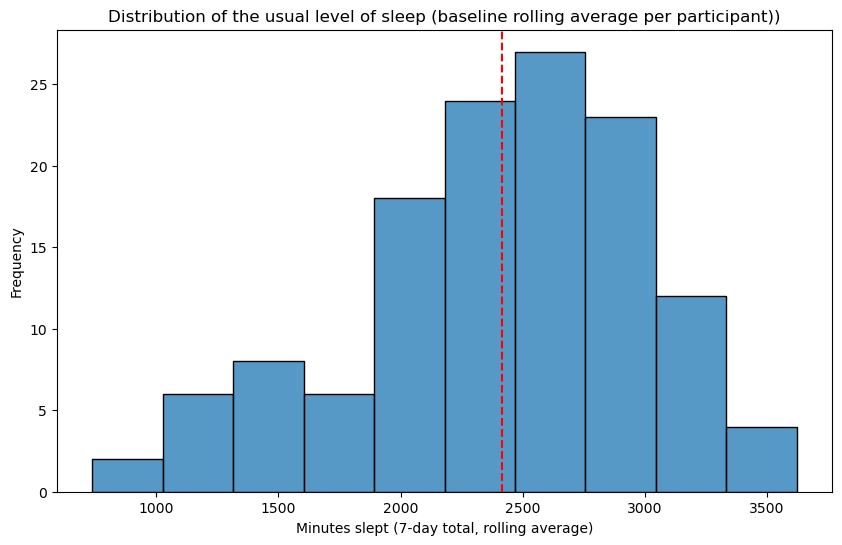

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_sleep_summary, x="mean")
plt.axvline(baseline_sleep_summary["mean"].mean(), color="red", linestyle="--")
plt.title("Distribution of the usual level of sleep (baseline rolling average per participant))")
plt.xlabel("Minutes slept (7-day total, rolling average)")
plt.ylabel("Frequency")
plt.show()


The distribution of typical sleep duration is roughly symmetrical, with most participants falling within the 2,000–3,000-minute range over a 7-day window (equivalent to 3.6–8.3 hours per night). The peak lies between 2,500 and 2,750 minutes (approximately 6–6.5 hours per night), and the group mean (red line) is around 2,400 minutes. There is a left tail with a small group of participants around 1,000–1,250 minutes (less than 3 hours per night), which already indicates heterogeneity in the usual level and justifies the within-subject logic: what constitutes 6 hours of usual sleep for one participant constitutes 3 hours of usual sleep for another, and both represent their recent normal.

**Distribution of Individual Variability**

We visualize the distribution of the mean standard deviation of each participant’s rolling baseline (the `std` column in `baseline_sleep_summary`). This allows us to characterize how regular or irregular sleep patterns are among participants.


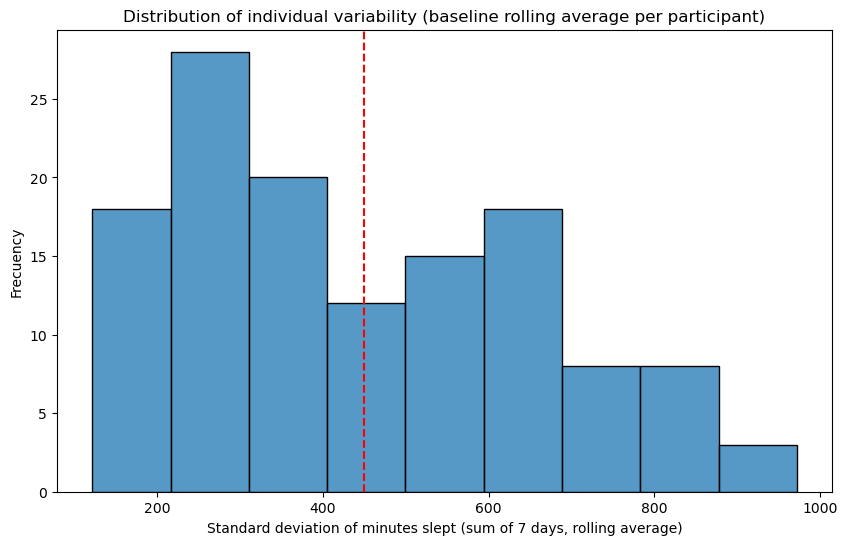

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_sleep_summary, x="std")
plt.axvline(baseline_sleep_summary["std"].mean(), color="red", linestyle="--")
plt.title("Distribution of individual variability (baseline rolling average per participant)")
plt.xlabel("Standard deviation of minutes slept (sum of 7 days, rolling average)")
plt.ylabel("Frecuency")
plt.show()


The distribution of individual variability is clearly skewed to the right. Most participants show low-to-moderate standard deviation, with a marked peak around 300–400 minutes. The group mean (red line) is close to 500, pulled upward by a long tail extending up to 1,000 minutes. This asymmetry reflects genuine heterogeneity among participants: most have relatively regular sleep patterns in their recent history, while a minority exhibit high standard deviations that the system must interpret as inherent variability, not as deviation. The intra-subject z-score for Block 3 will normalize each day’s deviation by the individual’s standard deviation over the previous 21 days, which automatically adjusts the sensitivity to these individual differences.


**Relationship Between Level and Variability**

We visualize the relationship between the two columns of `baseline_sleep_summary` using a scatter plot. This allows us to determine whether there is an association between the usual level of sleep and the regularity of the sleep pattern.


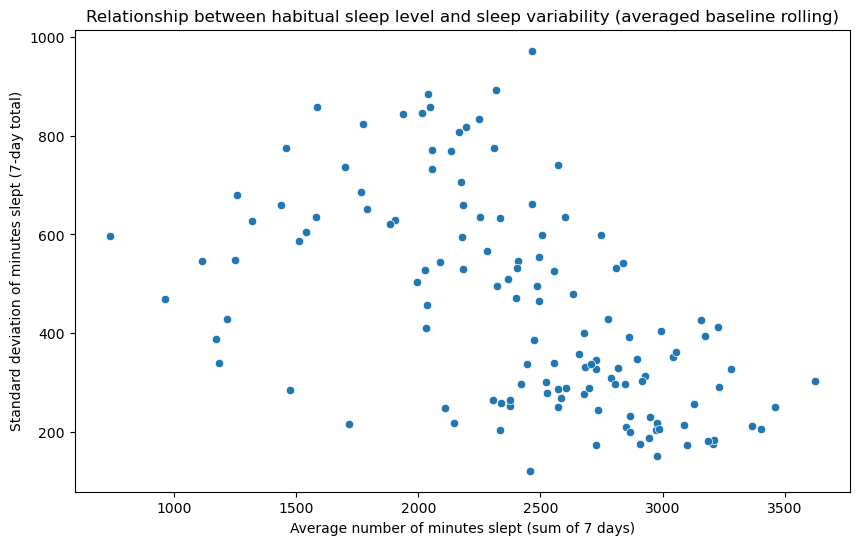

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=baseline_sleep_summary, x="mean", y="std")
plt.title("Relationship between habitual sleep level and sleep variability (averaged baseline rolling)")
plt.xlabel("Average number of minutes slept (sum of 7 days)")
plt.ylabel("Standard deviation of minutes slept (7-day total)")
plt.show()


The scatter plot shows a clear negative correlation between typical sleep duration and individual variability: participants with a high `mean` (2500–3500 minutes) tend to have a low `std` (200–500), whereas participants with a low `mean` (less than 2,000 minutes) exhibit a more dispersed `std` that is predominantly high (500–1,000). This pattern is consistent with the behavioral interpretation that people who habitually sleep for long periods have more stable routines, while habitually short sleep tends to coexist with greater irregularity.

This association is informative but does not condition the system: the intra-subject z-score is calculated against each participant’s own `mean` and `std` from their recent history. People with high `std` will have more conservative z-scores; people with low `std` will have more sensitive z-scores. That is the logic behind the intra-subject approach.


This completes the construction of the rolling sleep baseline:

- Primary feature: `f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:7dhist`.
- Structure: for each participant and each day d starting on day 28, a pair (mean, std) calculated over the 21 days ending 7 days before d, with a minimum coverage of 15 non-null days in that window.
- Interim results reviewed: 155 participants; unimodal distribution of typical sleep duration between 1,000 and 3,500 minutes; right-skewed distribution of individual variability; and a negative correlation between sleep duration and variability.
- Some participants have an uncalculable rolling baseline (NaN in the summary) due to insufficient coverage. They are not excluded from the project: they may become evaluable again on subsequent days if their coverage improves.

Based on this reference, the day-to-day within-subject z-score will be calculated in Block 3. The same logic is then applied to steps, location, and screen.


#### `2.5.2 Steps`
#### 2.5.2 - I. Identification of the primary feature


In [20]:
df_steps.columns[(df_steps.columns.str.contains("7dhist")) & ~(df_steps.columns.str.contains("norm")) & ~(df_steps.columns.str.contains("dis"))], df_steps.columns.shape


(Index(['f_steps:fitbit_steps_summary_rapids_maxsumsteps:7dhist',
        'f_steps:fitbit_steps_summary_rapids_minsumsteps:7dhist',
        'f_steps:fitbit_steps_summary_rapids_avgsumsteps:7dhist',
        'f_steps:fitbit_steps_summary_rapids_mediansumsteps:7dhist',
        'f_steps:fitbit_steps_summary_rapids_stdsumsteps:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_sumsteps:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_maxsteps:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_minsteps:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_avgsteps:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_stdsteps:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_countepisodesedentarybout:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_sumdurationsedentarybout:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_maxdurationsedentarybout:7dhist',
        'f_steps:fitbit_steps_intraday_rapids_mindurationsedentarybout:7dhist',
        'f_steps:fitbit_st

The “steps” dataset contains 597 columns. To identify the primary feature, we examined which columns had a 7-day window and were in raw format. We selected `sumsteps` (intraday sum of steps) as the primary feature because it is the most direct and interpretable measure of physical activity.


In [21]:
col_steps = 'f_steps:fitbit_steps_intraday_rapids_sumsteps:7dhist'


#### 2.5.2 - II. Preparing the `day` Column

We apply the same procedure to `df_steps` as we did to `df_sleep`: for each participant, we calculate their start date, convert the date columns to the `datetime` type, and derive the `day` column as the integer number of days since each participant’s start date. This `day` column serves as the time axis on which the subsequent rolling operation is performed.


In [22]:
# creamos una serie con la fecha inicial de cada participante
start_date = df_steps.groupby("pid")["date"].min()
start_date.head()

pid
INS-W_001    2018-04-03
INS-W_002    2018-04-03
INS-W_003    2018-04-03
INS-W_004    2018-04-03
INS-W_005    2018-04-03
Name: date, dtype: object

In [23]:
start_date.dtype, df_steps["date"].dtype

(dtype('O'), dtype('O'))

`start_date` and `df_steps[“date”]` are stored as strings. We convert them to their native date type so we can work with them.


In [24]:
df_steps["date"] = pd.to_datetime(df_steps["date"])
start_date = pd.to_datetime(start_date)
df_steps["date"].dtype, start_date.dtype


(dtype('<M8[ns]'), dtype('<M8[ns]'))

We assign each row of `df_steps` the start date of its participant by creating a new column called `start_date`.


In [25]:
df_steps["start_date"] = df_steps["pid"].map(start_date)
df_steps["start_date"].head()


0   2018-04-03
1   2018-04-03
2   2018-04-03
3   2018-04-03
4   2018-04-03
Name: start_date, dtype: datetime64[ns]

In [26]:
# comprobamos que el dataset tiene la nueva columna 'start_date'
df_steps.head(3)

,Unnamed: 0,pid,date,f_steps:fitbit_steps_summary_rapids_maxsumsteps:14dhist,f_steps:fitbit_steps_summary_rapids_minsumsteps:14dhist,f_steps:fitbit_steps_summary_rapids_avgsumsteps:14dhist,f_steps:fitbit_steps_summary_rapids_mediansumsteps:14dhist,f_steps:fitbit_steps_summary_rapids_stdsumsteps:14dhist,f_steps:fitbit_steps_intraday_rapids_sumsteps:14dhist,f_steps:fitbit_steps_intraday_rapids_maxsteps:14dhist,...,f_steps:fitbit_steps_intraday_rapids_mindurationsedentarybout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_avgdurationsedentarybout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_stddurationsedentarybout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_countepisodeactivebout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_sumdurationactivebout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_maxdurationactivebout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_mindurationactivebout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_avgdurationactivebout_norm:weekend,f_steps:fitbit_steps_intraday_rapids_stddurationactivebout_norm:weekend,start_date
0,0,INS-W_001,2018-04-03,17287.0,17287.0,17287.0,17287.0,NaN,17287.0,151.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03
1,1,INS-W_001,2018-04-04,17287.0,14958.0,16122.5,16122.5,1646.851693,32245.0,151.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03
2,2,INS-W_001,2018-04-05,17287.0,14958.0,16245.0,16490.0,1183.671830,48735.0,151.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-03


Calculamos el día relativo de cada fila como diferencia entre `date` y `start_date`. El resultado es un timedelta del que extraemos solo la parte entera de días.


In [27]:
df_steps["day"] = (df_steps["date"] - df_steps["start_date"]).dt.days
df_steps["day"].head(10)


0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
Name: day, dtype: int64

The `day` column now contains the relative day for each row, ranging from 0 to 91, in integer format.


#### 2.5.2 - III. Working with the Complete DataFrame

As with sleep, rolling baseline analysis requires access to all available days for each participant. `df_steps` is not filtered to an initial window. The 70% coverage criterion is applied internally as `min_periods=15` within the rolling process, and participants are not filtered a priori: each day is evaluated independently.


#### 2.5.2 - IV. Calculating the Rolling Baseline with a Buffer

We apply the same 7-day buffer rolling operation to `col_steps` as was applied to `sleep`. The rationale for the buffer is the same: the primary feature is a 7-day moving sum, and without a buffer, the observation for day d would share raw data with the latest baseline values, attenuating the subsequent z-score.


In [28]:
baseline_steps = (
    df_steps.groupby("pid")[col_steps]
    .apply(lambda s: s.shift(7).rolling(window=21, min_periods=15).agg(["mean", "std"]))
)

baseline_steps.head(30)

mean          std
pid                                  
INS-W_001 0          NaN          NaN
          1          NaN          NaN
          2          NaN          NaN
          3          NaN          NaN
          4          NaN          NaN
          5          NaN          NaN
          6          NaN          NaN
          7          NaN          NaN
          8          NaN          NaN
          9          NaN          NaN
          10         NaN          NaN
          11         NaN          NaN
          12         NaN          NaN
          13         NaN          NaN
          14         NaN          NaN
          15         NaN          NaN
          16         NaN          NaN
          17         NaN          NaN
          18         NaN          NaN
          19         NaN          NaN
          20         NaN          NaN
          21         NaN          NaN
          22         NaN          NaN
          23         NaN          NaN
          24         NaN          NaN
          25         NaN          NaN
          26         NaN          NaN
          27         NaN          NaN
          28  99366.8000  7356.756780
          29  98122.0625  8677.769802

`baseline_steps` contains, for each participant and each day of the dataset, their rolling baseline of steps on that specific day. Days with insufficient coverage or that occur too early in the dataset are recorded as `NaN`.


#### 2.5.2 - V. Visualization of the Rolling Baseline for Steps

As with sleep, we calculate the average rolling baseline per participant to visually inspect the distribution across participants. These visualizations are exploratory; the actual system operation uses the complete rolling baseline.


In [29]:
baseline_steps_summary = baseline_steps.groupby("pid").mean()
baseline_steps_summary


,mean,std
pid,,
INS-W_001,81623.027268,15765.924066
INS-W_002,35445.410706,18459.262666
INS-W_003,51222.244751,17777.381599
INS-W_004,79796.247761,12108.853822
INS-W_005,89786.998704,12255.154353
...,...,...
INS-W_201,57741.695043,33090.784297
INS-W_202,43656.479361,19382.473565
INS-W_203,60432.518094,30341.483713


**Distribution of the Usual Number of Steps**


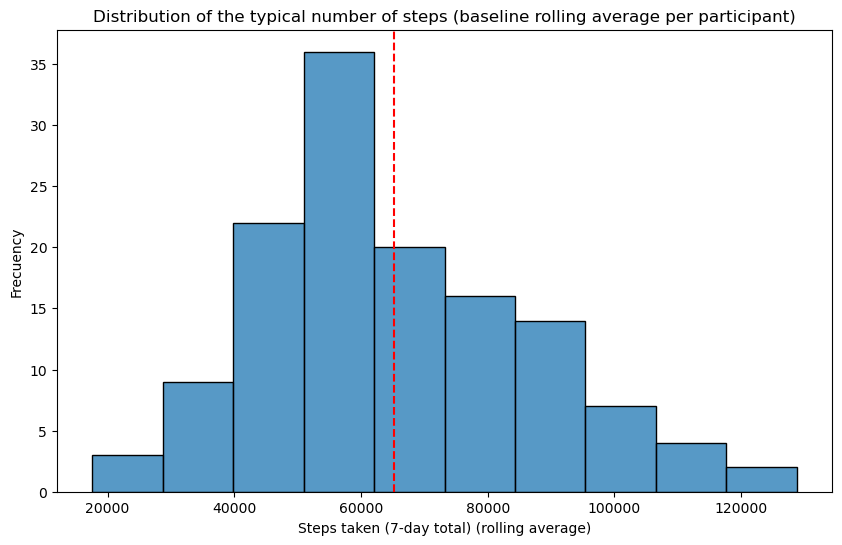

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_steps_summary, x="mean")
plt.axvline(baseline_steps_summary["mean"].mean(), color="red", linestyle="--")
plt.title("Distribution of the typical number of steps (baseline rolling average per participant)")
plt.xlabel("Steps taken (7-day total) (rolling average)")
plt.ylabel("Frecuency")
plt.show()


The distribution of typical activity levels is unimodal with a right-skewed distribution. Most participants fall between 30,000 and 90,000 steps over 7 days (equivalent to 4,300–12,900 steps/day), with a marked peak between 50,000 and 60,000 steps (7,100–8,600 steps/day). The group mean (red line) is around 65,000 steps, pulled upward by a right tail that extends to 120,000–130,000 (more than 17,000 steps per day). There is also a small group at the lower end (15,000–25,000 steps over 7 days, less than 3,600 steps/day).

The observed heterogeneity is to be expected: there are participants with very active lifestyles and participants who are mostly sedentary, and both extremes are within the normal range for each individual. The within-subject approach avoids comparing participants with one another: what matters is not whether one person walks more than another, but whether each person deviates from their own recent usual level.


**Distribution of Individual Variability**


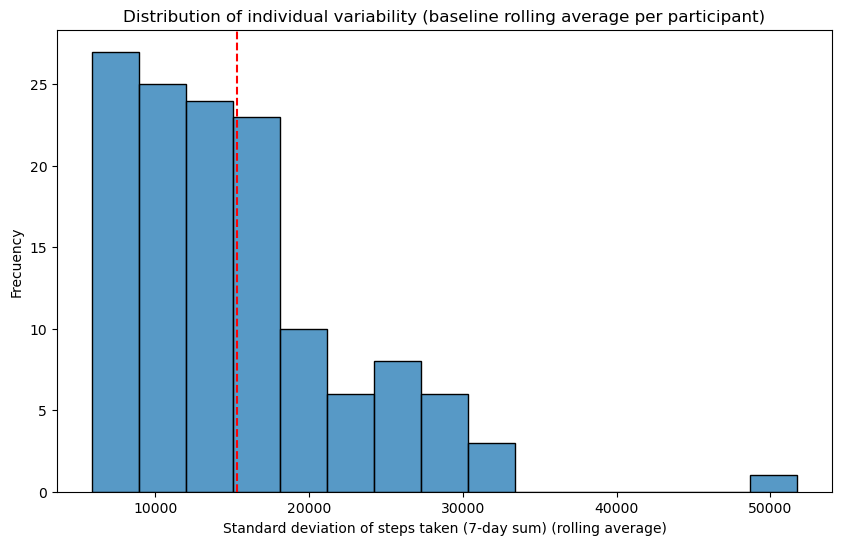

In [31]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_steps_summary, x="std")
plt.axvline(baseline_steps_summary["std"].mean(), color="red", linestyle="--")
plt.title("Distribution of individual variability (baseline rolling average per participant)")
plt.xlabel("Standard deviation of steps taken (7-day sum) (rolling average)")
plt.ylabel("Frecuency")
plt.show()


The distribution of individual variability is clearly right-skewed. Most participants are concentrated within a range of 8,000–12,000 steps, with a marked peak in that range. The group mean (red line) is around 16,000, driven by a long tail extending up to 30,000, plus a few isolated cases around 50,000.

This asymmetry reflects that steps is a signal with greater structural variability than sleep. Physical activity depends heavily on daily context (work, leisure time, occasional sports, holidays, weather), and a participant with a high standard deviation is not necessarily irregular in a pathological sense; they simply lead a life with a wider range of activity. The intra-subject z-score for Block 3 normalizes each day’s deviation against the individual’s own standard deviation over the previous 21 days, which automatically adjusts the sensitivity to each participant’s variability profile.


**Relación entre nivel y variabilidad**


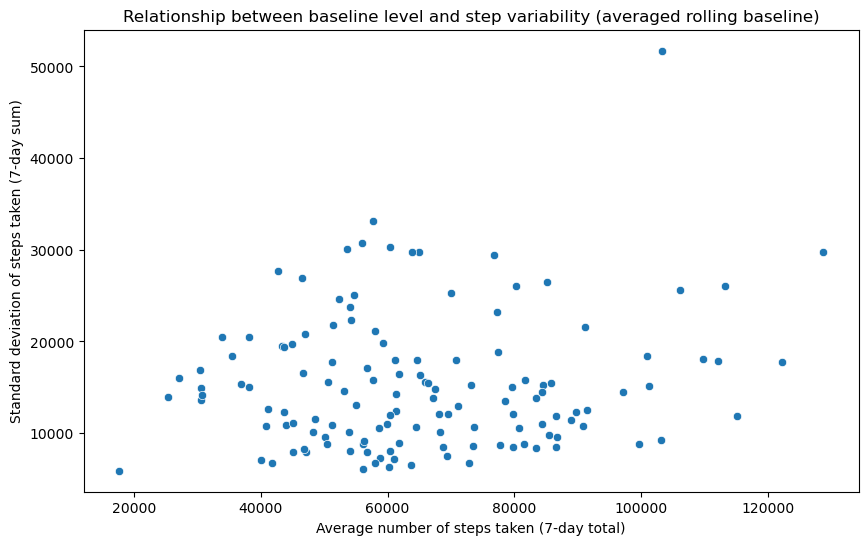

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=baseline_steps_summary, x="mean", y="std")
plt.title("Relationship between baseline level and step variability (averaged rolling baseline)")
plt.xlabel("Average number of steps taken (7-day total)")
plt.ylabel("Standard deviation of steps taken (7-day sum)")
plt.show()


The scatter plot shows no clear linear correlation between the usual activity level and individual variability. The scatter plot is concentrated around moderate values on both dimensions (mean between 40,000 and 90,000 steps over 7 days, standard deviation between 8,000 and 20,000), with no systematic pattern linking level and variability.

The absence of correlation contrasts with sleep, where a negative association between a high mean and a low standard deviation was observed. For steps, participants with similar usual activity levels may have very different variability profiles, and participants with high standard deviations appear among both low and high activity levels. This reinforces the intra-subject logic: the level-variability combination is unique to each person and cannot be summarized by a population-wide trend.


This completes the construction of the rolling baseline for steps:

- Primary feature: `f_steps:fitbit_steps_intraday_rapids_sumsteps:7dhist`.
- Structure: for each participant and each day d starting on day 28, a pair (mean, std) calculated over the 21 days ending 7 days before d, with a minimum coverage of 15 non-missing days in that window.
- Inspected interim result: 155 participants, unimodal distribution of usual level with right-skewed distribution between 15,000 and 130,000 steps, right-skewed distribution of variability, and no linear correlation between level and variability.
- As with sleep, participants for whom the rolling baseline cannot be calculated due to insufficient coverage are not excluded: they may become evaluable again on subsequent days.


#### `2.5.3. Location`
#### 2.5.3 - I. Identification of the primary feature


In [33]:
df_location.columns[(df_location.columns.str.contains("7dhist")) & ~(df_location.columns.str.contains("norm")) & ~(df_location.columns.str.contains("dis"))], df_location.columns.shape


(Index(['f_loc:phone_locations_barnett_avgflightdur:7dhist',
        'f_loc:phone_locations_barnett_avgflightlen:7dhist',
        'f_loc:phone_locations_barnett_circdnrtn:7dhist',
        'f_loc:phone_locations_barnett_hometime:7dhist',
        'f_loc:phone_locations_barnett_maxdiam:7dhist',
        'f_loc:phone_locations_barnett_probpause:7dhist',
        'f_loc:phone_locations_barnett_rog:7dhist',
        'f_loc:phone_locations_barnett_siglocentropy:7dhist',
        'f_loc:phone_locations_barnett_siglocsvisited:7dhist',
        'f_loc:phone_locations_barnett_stdflightdur:7dhist',
        'f_loc:phone_locations_barnett_stdflightlen:7dhist',
        'f_loc:phone_locations_barnett_wkenddayrtn:7dhist',
        'f_loc:phone_locations_doryab_avglengthstayatclusters:7dhist',
        'f_loc:phone_locations_doryab_avgspeed:7dhist',
        'f_loc:phone_locations_doryab_homelabel:7dhist',
        'f_loc:phone_locations_doryab_locationentropy:7dhist',
        'f_loc:phone_locations_doryab_locat

The location dataset contains 1,110 columns. To identify the primary feature, we filtered the columns that have a 7dhist window and are in raw format. We selected `rog` (radius of gyration) as the primary feature. It measures the user’s spatial dispersion around their geographic center of mass, summarizing in a single value how broad or restricted their living space is.


In [34]:
col_location = 'f_loc:phone_locations_barnett_rog:7dhist'

#### 2.5.3 - II. Preparing the `day` Column
 
We apply the same procedure to `df_location` as we did to `df_sleep`: we calculate each participant’s start date, convert the date columns to the `datetime` data type, and derive the `day` column as the integer number of days since each participant’s start date. This `day` column serves as the time axis on which the subsequent rolling operation is performed.


In [35]:
start_date = df_location.groupby("pid")["date"].min()
start_date.dtype, df_location["date"].dtype


(dtype('O'), dtype('O'))

`start_date` and `df_location[“date”]` are stored as strings. We convert them to their native date type so we can work with them.


In [36]:
df_location["date"] = pd.to_datetime(df_location["date"])
start_date = pd.to_datetime(start_date)
df_location["date"].dtype, start_date.dtype


(dtype('<M8[ns]'), dtype('<M8[ns]'))

We assign each row in `df_location` the start date of its participant by creating a new column called `start_date`.


In [37]:
df_location["start_date"] = df_location["pid"].map(start_date)
df_location["start_date"].head(10)


0   2018-04-03
1   2018-04-03
2   2018-04-03
3   2018-04-03
4   2018-04-03
5   2018-04-03
6   2018-04-03
7   2018-04-03
8   2018-04-03
9   2018-04-03
Name: start_date, dtype: datetime64[ns]

We calculate the relative day for each row as the difference between `date` and `start_date`. The result is a `timedelta`, from which we extract only the integer part representing the number of days.


In [38]:
df_location["day"] = (df_location["date"] - df_location["start_date"]).dt.days
df_location["day"].head(10)


0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
Name: day, dtype: int64

The `day` column now contains the relative day for each row, ranging from 0 to 91, in integer format.


#### 2.5.3 - III. Working with the Complete DataFrame

As with sleep, rolling baseline analysis requires access to all available days for each participant. `df_location` is not filtered to an initial window. The 70% coverage criterion is applied internally as `min_periods=15` within the rolling process, and participants are not filtered a priori: each day is evaluated independently.


#### 2.5.3 - IV. Calculating the Rolling Baseline with a Buffer

We apply the same rolling operation with a 7-day buffer to `col_location` as was applied to the previous dimensions. The rationale for the buffer is structural: `rog:7dhist` is the turning radius calculated over a 7-day moving window, so the values for consecutive days share 6 days of raw data. Without a buffer, the latest baseline values would partially overlap with the observation on day d, attenuating the subsequent z-score.


In [39]:
baseline_location = (
    df_location
    .groupby("pid")[col_location]
    .apply(lambda s: s.shift(7).rolling(window=21, min_periods=15).agg(["mean", "std"]))
)

baseline_location.head(40)


mean         std
pid                                  
INS-W_001 0           NaN         NaN
          1           NaN         NaN
          2           NaN         NaN
          3           NaN         NaN
          4           NaN         NaN
          5           NaN         NaN
          6           NaN         NaN
          7           NaN         NaN
          8           NaN         NaN
          9           NaN         NaN
          10          NaN         NaN
          11          NaN         NaN
          12          NaN         NaN
          13          NaN         NaN
          14          NaN         NaN
          15          NaN         NaN
          16          NaN         NaN
          17          NaN         NaN
          18          NaN         NaN
          19          NaN         NaN
          20          NaN         NaN
          21          NaN         NaN
          22          NaN         NaN
          23          NaN         NaN
          24          NaN         NaN
          25          NaN         NaN
          26          NaN         NaN
          27          NaN         NaN
          28          NaN         NaN
          29          NaN         NaN
          30          NaN         NaN
          31          NaN         NaN
          32          NaN         NaN
          33          NaN         NaN
          34          NaN         NaN
          35  1924.725008  608.033849
          36  1884.295420  609.270857
          37  1843.809146  613.086979
          38  1780.518287  652.586011
          39  1710.060899  704.648684

`baseline_location` contains, for each participant and each day of the dataset, their rolling baseline location on that specific day. Days with insufficient coverage or too early in the dataset are marked as `NaN`.


#### 2.5.3 - V. Visualization of the rolling baseline for location

As with sleep, we calculate the average rolling baseline per participant to visually inspect the distribution across participants. These visualizations are exploratory; the actual system operation uses the complete rolling baseline.


In [40]:
baseline_location_summary = baseline_location.groupby("pid").mean()
baseline_location_summary

,mean,std
pid,,
INS-W_001,1718.554503,570.365056
INS-W_002,16366.340236,13577.012790
INS-W_003,2808.076261,3757.370162
INS-W_004,2928.644068,1942.110924
INS-W_005,2690.507547,1912.366961
...,...,...
INS-W_201,2340.299649,880.308045
INS-W_202,27460.253991,36166.922234
INS-W_203,5210.717203,2892.848955


**Distribution of the typical rental rate**


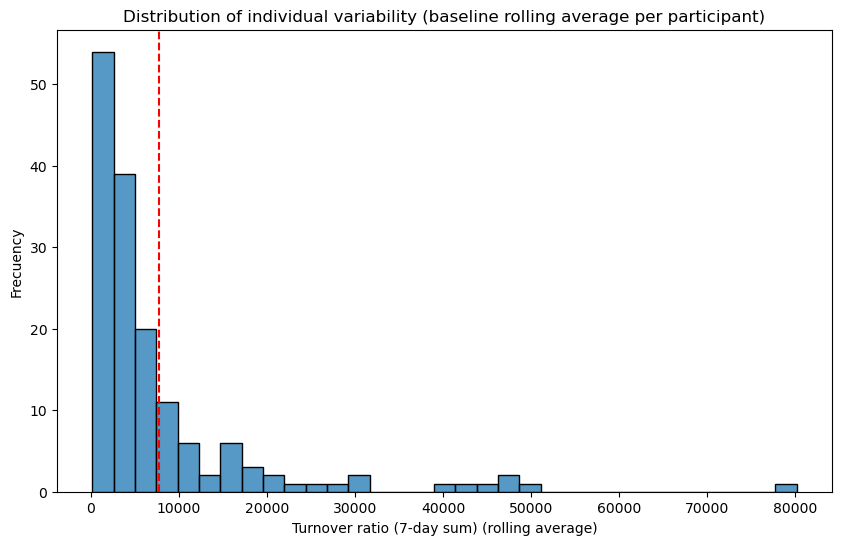

In [41]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_location_summary, x="mean")
plt.axvline(baseline_location_summary["mean"].mean(), color="red", linestyle="--")
plt.title("Distribution of individual variability (baseline rolling average per participant)")
plt.xlabel("Turnover ratio (7-day sum) (rolling average)")
plt.ylabel("Frecuency")
plt.show()


The distribution of typical spatial mobility shows extreme right-skewed asymmetry. Most participants are concentrated at low values: the highest peak is in the 0–2,500-meter range (more than 50 participants), followed by a sharp drop-off toward the 10,000–15,000-meter range. The group’s mean (red line) is around 8,000 meters, pulled upward by a very long tail with values scattered up to 80,000.

This distribution pattern reflects structural heterogeneity in lifestyles: most participants operate within a limited spatial radius (home, nearby work, or school), while a minority has much broader mobility patterns (long trips, multiple geographic contexts throughout the week). With rolling baseline, this heterogeneity is not treated as a problem, but rather as information: each participant is compared to their own previous data, and a short radius is the norm for some, while a long radius is the norm for others.


**Distribution of Individual Variability**


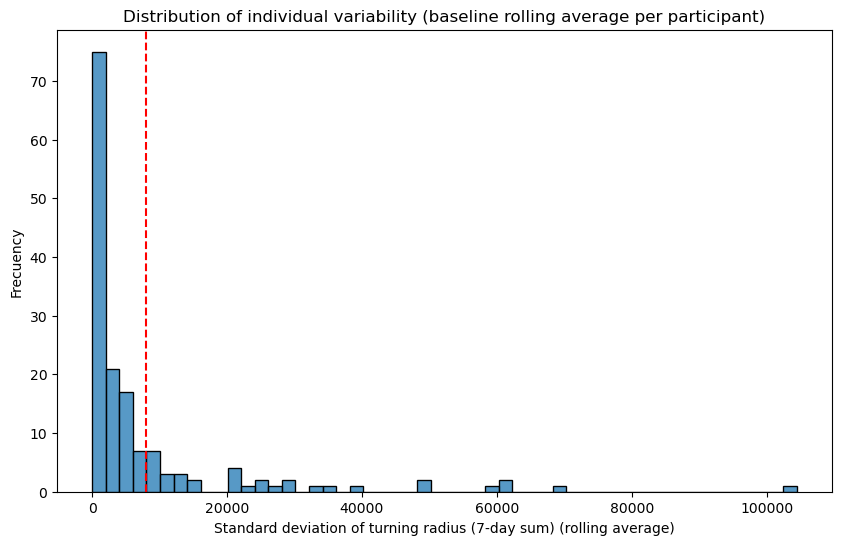

In [42]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_location_summary, x="std")
plt.axvline(baseline_location_summary["std"].mean(), color="red", linestyle="--")
plt.title("Distribution of individual variability (baseline rolling average per participant)")
plt.xlabel("Standard deviation of turning radius (7-day sum) (rolling average)")
plt.ylabel("Frecuency")
plt.show()


The distribution of individual variability is even more right-skewed than that of the usual level. The peak is enormous in the 0–5,000 range (with about 75 participants concentrated there). The group mean (red line) lies near 9,000, and the tail extends to over 100,000 with isolated cases.

The interpretation is consistent with the previous plot: most participants have a very stable spatial pattern from week to week (similar geographic routines), and a minority with extensive mobility also exhibits greater spatial variability. As with steps, a high standard deviation is not automatically interpreted as pathological irregularity, but rather as the amplitude of the individual’s own pattern. The intra-subject z-score for Block 3 is normalized against each person’s own standard deviation, which adjusts the sensitivity to these highly diverse profiles.


**Relationship Between Level and Variability**


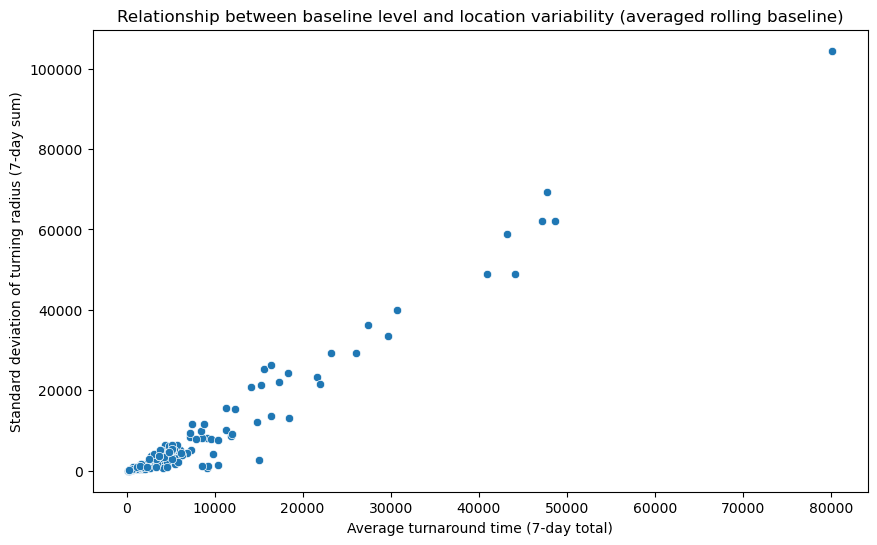

In [43]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=baseline_location_summary, x="mean", y="std")
plt.title("Relationship between baseline level and location variability (averaged rolling baseline)")
plt.xlabel("Average turnaround time (7-day total)")
plt.ylabel("Standard deviation of turning radius (7-day sum)")
plt.show()


The scatter plot shows a very clear positive linear correlation between the typical level of mobility and individual variability. The scatter plot aligns along a clear diagonal axis: participants with a low `mean` (0–10,000) have a low `std` (0–5,000), and as `mean` increases, `std` increases proportionally, up to participants with the largest turning radius (over 50,000), who also exhibit the greatest spatial variability (over 50,000).

This association is very different from those observed in sleep (negative correlation) and steps (no clear correlation). For location, the positive association is to be expected: a person with a broad spatial pattern has more opportunities to vary geographically from week to week, and the turning radius is lower in people with more sedentary lifestyles. The association is informative but does not constrain the system: the within-subject z-score is calculated against each participant’s own `mean` and `std` from their recent history, so the sensitivity automatically adjusts to each person’s spatial profile.


Con esto queda construido el baseline rolling de location:

- Feature primaria: `f_loc:phone_locations_barnett_rog:7dhist`.
- Estructura: para cada participante y cada día d a partir del día 28, par (media, std) calculado sobre los 21 días que terminaron 7 días antes de d, con cobertura mínima de 15 días no nulos en esa ventana.
- Resultado intermedio inspeccionado: 155 participantes, distribución del nivel habitual con asimetría derecha extrema (concentración en 0-15000 metros y cola hasta 80000), distribución de variabilidad muy sesgada a la derecha y correlación lineal positiva clara entre nivel y variabilidad.
- Como en sleep y steps, los participantes con baseline rolling no calculable por cobertura insuficiente no son excluidos: pueden volver a ser evaluables en días posteriores.


#### `2.5.4. Screen`
#### 2.5.4. - I. Identification of the primary feature


In [44]:
df_screen.columns[(df_screen.columns.str.contains("7dhist")) & ~(df_screen.columns.str.contains("norm")) & ~(df_screen.columns.str.contains("dis"))], df_screen.columns.shape

(Index(['f_screen:phone_screen_rapids_countepisodeunlock:7dhist',
        'f_screen:phone_screen_rapids_sumdurationunlock:7dhist',
        'f_screen:phone_screen_rapids_maxdurationunlock:7dhist',
        'f_screen:phone_screen_rapids_mindurationunlock:7dhist',
        'f_screen:phone_screen_rapids_avgdurationunlock:7dhist',
        'f_screen:phone_screen_rapids_stddurationunlock:7dhist',
        'f_screen:phone_screen_rapids_firstuseafter00unlock:7dhist',
        'f_screen:phone_screen_rapids_countepisodeunlock_locmap_exercise:7dhist',
        'f_screen:phone_screen_rapids_sumdurationunlock_locmap_exercise:7dhist',
        'f_screen:phone_screen_rapids_maxdurationunlock_locmap_exercise:7dhist',
        'f_screen:phone_screen_rapids_mindurationunlock_locmap_exercise:7dhist',
        'f_screen:phone_screen_rapids_avgdurationunlock_locmap_exercise:7dhist',
        'f_screen:phone_screen_rapids_stddurationunlock_locmap_exercise:7dhist',
        'f_screen:phone_screen_rapids_firstuseafter00

The screen dataset contains 1,137 columns. To identify the primary feature, we filtered for those with a 7-day window and the “raw” version. We selected `sumdurationunlock` (total duration of unlocked use) as the primary feature because it is the most direct measure of total interaction time with the device.


In [45]:
col_screen = 'f_screen:phone_screen_rapids_sumdurationunlock:7dhist'


#### 2.5.4. - II. Preparing the `day` Column

We apply the same procedure to `df_screen` as we did to `df_sleep`: for each participant, we calculate their start date, convert the date columns to the `datetime` type, and derive the `day` column as the integer number of days since each participant’s start date. This `day` column serves as the time axis on which the subsequent rolling operation is based.


In [46]:
start_date = df_screen.groupby("pid")["date"].min()
start_date.dtype, df_screen["date"].dtype


(dtype('O'), dtype('O'))

`start_date` and `df_screen[“date”]` are stored as strings. We convert them to their native date type so we can work with them.


In [47]:
df_screen["date"] = pd.to_datetime(df_screen["date"])
start_date = pd.to_datetime(start_date)
df_screen["date"].dtype, start_date.dtype


(dtype('<M8[ns]'), dtype('<M8[ns]'))

We assign each row in `df_screen` the participant's start date by creating a new column called `start_date`.

In [48]:
df_screen["start_date"] = df_screen["pid"].map(start_date)
df_screen["start_date"].head(10)


0   2018-04-03
1   2018-04-03
2   2018-04-03
3   2018-04-03
4   2018-04-03
5   2018-04-03
6   2018-04-03
7   2018-04-03
8   2018-04-03
9   2018-04-03
Name: start_date, dtype: datetime64[ns]

We calculate the relative day for each row as the difference between `date` and `start_date`. The result is a `timedelta`, from which we extract only the integer part of the days.

In [49]:
df_screen["day"] = (df_screen["date"] - df_screen["start_date"]).dt.days
df_screen["day"].head(10)


0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
Name: day, dtype: int64

The `day` column now contains the relative day for each row, ranging from 0 to 91, in integer format.


#### 2.5.4. - III. Working with the Complete DataFrame

As with sleep, rolling baseline analysis requires access to all available days for each participant. `df_screen` is not filtered to an initial window. The 70% coverage criterion is applied internally as `min_periods=15` within the rolling process, and participants are not filtered a priori: each day is evaluated independently.


#### 2.5.4. - IV. Calculating the Rolling Baseline with a Buffer

We apply the same 7-day buffer rolling operation to `col_screen` as was applied to `sleep`. The rationale for the buffer is the same: the primary feature is a 7-day moving sum, and without a buffer, the observation on day d would share raw data with the latest baseline values, attenuating the subsequent z-score.


In [50]:
baseline_screen = (
    df_screen
    .groupby("pid")[col_screen]
    .apply(lambda s: s.shift(7).rolling(window=21, min_periods=15).agg(["mean", "std"]))
)

baseline_screen.head(80)

mean         std
pid                                 
INS-W_001 0          NaN         NaN
          1          NaN         NaN
          2          NaN         NaN
          3          NaN         NaN
          4          NaN         NaN
...                  ...         ...
          75  347.207426  175.509386
          76  340.592052  177.362305
          77  333.280322  179.098828
          78  325.156178  180.652809
          79  321.493326  185.522403

[80 rows x 2 columns]

`baseline_screen` contains, for each participant and each day of the study, their rolling baseline screen value for that specific day. Days with insufficient coverage or too early in the study are recorded as `NaN`.


#### 2.5.4. - V. Visualization of the rolling baseline for screen

As with sleep, we calculate the average rolling baseline per participant to visually inspect the distribution across participants. These visualizations are exploratory; the actual system operation uses the complete rolling baseline.


In [51]:
baseline_screen_summary = baseline_screen.groupby("pid").mean()
baseline_screen_summary

,mean,std
pid,,
INS-W_001,960.844599,377.668884
INS-W_002,1329.192759,323.338269
INS-W_003,3377.564831,415.883399
INS-W_004,1788.637988,383.208390
INS-W_005,2557.013354,438.930769
...,...,...
INS-W_201,2310.091396,353.543745
INS-W_202,1866.029210,482.316809
INS-W_203,1835.357276,186.438927


**Distribution of the typical screen level**


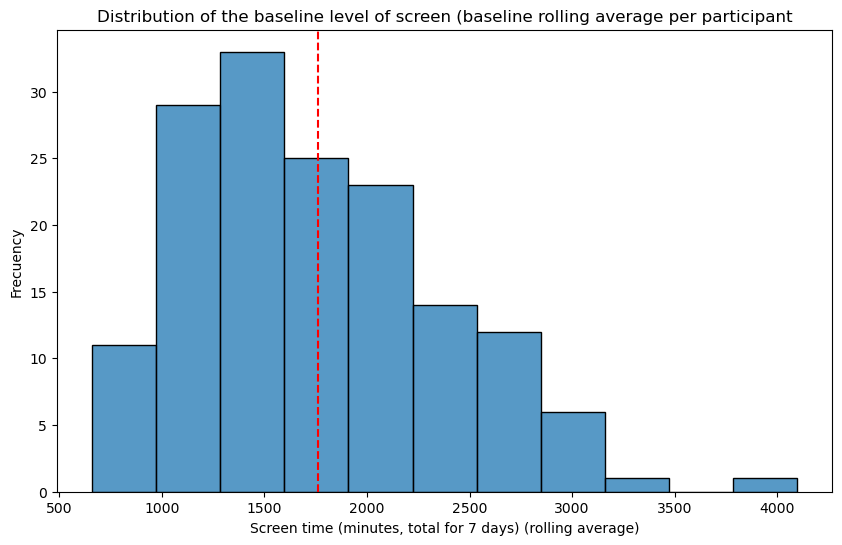

In [52]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_screen_summary, x="mean")
plt.axvline(baseline_screen_summary["mean"].mean(), color="red", linestyle="--")
plt.title("Distribution of the baseline level of screen (baseline rolling average per participant")
plt.xlabel("Screen time (minutes, total for 7 days) (rolling average)")
plt.ylabel("Frecuency")
plt.show()

The distribution of typical screen time shows a right-skewed pattern. Most participants fall within the range of 1,000 to 2,500 minutes over a 7-day period, with a marked peak at 1,000–1,500 (more than 30 participants) and a second high-frequency zone at 1,500–2,000 with a similar frequency. The group average (red line) is around 1,750 minutes. The tail tapers off gradually and extends up to 3,500–4,000 minutes with isolated cases.

This intermediate shape (asymmetric but without the extreme concentration seen in location data) is consistent with the fact that screen use is more evenly distributed across the cohort than spatial mobility. There are notable differences in habitual usage among participants, but all make some use of the device, which reduces the left tail. As in the previous dimensions, the system does not compare participants with one another but instead uses each participant’s recent habitual level as their own reference.


**Distribution of Individual Variability**

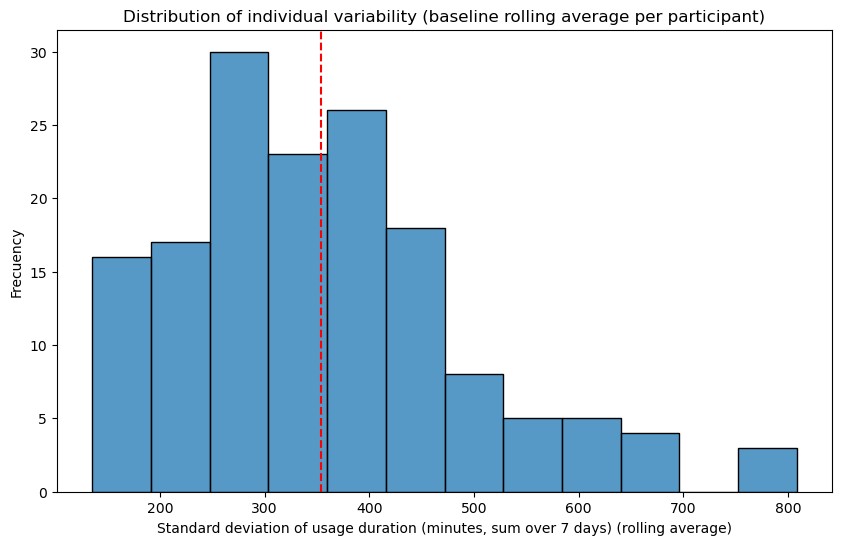

In [53]:
plt.figure(figsize=(10, 6))
sns.histplot(baseline_screen_summary, x="std")
plt.axvline(baseline_screen_summary["std"].mean(), color="red", linestyle="--")
plt.title("Distribution of individual variability (baseline rolling average per participant)")
plt.xlabel("Standard deviation of usage duration (minutes, sum over 7 days) (rolling average)")
plt.ylabel("Frecuency")
plt.show()


The distribution of individual variability shows a clear right-skewed asymmetry. The peak is located at 250–300 minutes, with most participants concentrated between 150 and 500. The group mean (red line) is around 350 minutes, and the tail extends to 800 with decreasing frequency.

This interpretation is consistent with the finding that screen time, while variable, is less extreme than steps or location. Most participants maintain a relatively regular pattern of use from week to week, with a minority showing greater variability. The intra-subject z-score for Block 3 is normalized against each person’s own standard deviation, which automatically adjusts the sensitivity to each participant’s regularity profile.


**Relationship Between Level and Variability**


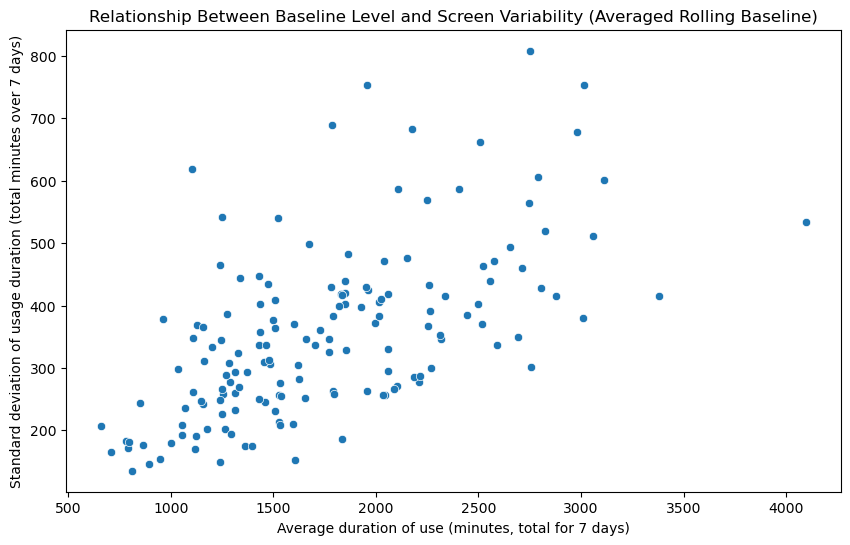

In [54]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=baseline_screen_summary, x="mean", y="std")
plt.title("Relationship Between Baseline Level and Screen Variability (Averaged Rolling Baseline)")
plt.xlabel("Average duration of use (minutes, total for 7 days)")
plt.ylabel("Standard deviation of usage duration (total minutes over 7 days)")
plt.show()


The scatter plot shows a moderate positive correlation between the usual level of use and individual variability. The trend is visible (high mean tends to correspond to high standard deviation), but with wide dispersion: for the same average level of use, participants exhibit very different standard deviations. The pattern is clearer than in sleep or steps, but less pronounced than in location.

This intermediate position has a reasonable behavioral interpretation: a participant who uses their cell phone more in absolute terms also has more opportunities for variation from week to week, but the upper limit of variability is more constrained than in spatial mobility. The association is informative but does not constrain the system, because the intra-subject z-score is calculated against each participant’s own `mean` and `std`.


This completes the construction of the rolling baseline for screen:

- Primary feature: `f_screen:phone_screen_rapids_sumdurationunlock:7dhist`.
- Structure: for each participant and each day d starting on day 28, a pair (mean, std) calculated over the 21 days ending 7 days before d, with a minimum coverage of 15 non-null days in that window.
- Inspected interim result: 155 participants; a distribution of usual level with right-skewed distribution between 500 and 4,000 minutes; a right-skewed distribution of variability; and a moderate positive correlation between level and variability.
- As with sleep, steps, and location, participants for whom the rolling baseline cannot be calculated due to insufficient coverage are not excluded: they may become evaluable again on subsequent days.


### 2.6. Completion of Block 2

The system now has four individual rolling baselines, one per dimension, calculated over the 21 days ending 7 days before each evaluation day. Each baseline contains, for each person-day pair, the mean and standard deviation that will serve as an individual reference in the calculation of the intra-subject z-score for Block 3.

Participants for whom a baseline cannot be calculated in a given dimension on a specific day are omitted from that dimension on that day, without being excluded from the project. The 2/3 convergence rule across dimensions will be applied in Block 3 on days when the participant has at least two evaluable dimensions.


---

<h2>Bloque 3: Z-score intra-sujeto</h2>

### 3.1. Cálculo del Z-score intra-sujeto del sistema

El Bloque 2 produjo cuatro baselines, uno por dimensión, que contienen para cada par persona-día la media y la desviación típica del comportamiento habitual reciente de esa persona. 

El Bloque 3 usa esos baselines para responder a una pregunta concreta: para cada día evaluable, **¿cuánto se aleja la observación de hoy del patrón habitual reciente de esta persona?**

La medida es el z-score intra-sujeto: `z = (observación − mean) / std`. Es la fórmula convencional del z-score, pero su semántica aquí es la del marco N-of-1. La media y la desviación típica no provienen de la población, sino que provienen del propio historial reciente de la persona. El resultado no compara a la persona con un grupo de referencia, la compara consigo misma a lo largo del tiempo.

La salida del bloque son cuatro `Series`, una por dimensión (`z_sleep`, `z_steps`, `z_location`, `z_screen`), indexadas por `(pid, idx)` igual que los baselines. Cada Series tiene valor numérico en los pares persona-día evaluables y `NaN` en los no evaluables. Los pares con NaN en **mean** o **std** (por baseline no calculable) quedan automáticamente excluidos por aritmética: cualquier operación con NaN produce NaN.

La decisión de mantener el z-score como Series separada por dimensión, y no como columna añadida al DataFrame de cada dimensión, responde a tres razones: 

* El z-score no es una propiedad de la observación cruda sino una relación con un baseline concreto. 
* Su dominio natural son los pares evaluables, no todos los pares.
* Los bloques posteriores operan sobre las cuatro dimensiones simultáneamente, lo que se resuelve trivialmente con cuatro Series del mismo índice.

### 3.2. Construcción del z-score para sleep

Aplicamos la fórmula del z-score sobre la dimensión sleep como dimensión piloto. La operación combina dos objetos ya construidos: la columna `col_sleep` de **df_sleep**, que contiene la observación cruda 7dhist de cada par persona-día, y el DataFrame `baseline_sleep`, que contiene la **media** y la **desviación típica** del baseline rolling de esa misma persona para ese mismo día.

In [55]:
z_sleep = pd.Series(
    (df_sleep[col_sleep].values - baseline_sleep["mean"].values) / baseline_sleep["std"].values,
    index=baseline_sleep.index
)
z_sleep.dropna().head()

pid          
INS-W_001  28   -0.588216
           29   -0.478832
           30    0.416003
           31    0.664682
           32    1.654369
dtype: float64

INS-W_001 empieza a tener z-scores numéricos en el registro 28, que coincide con la primera posición donde el baseline rolling cumple la regla de cobertura tras la limpieza de los días 0-6 (al menos 15 valores no-NaN en la ventana [d-28, d-8]). 

Los valores iniciales oscilan entre −0.58 y +1.65, mostrando una tendencia ascendente desde valores ligeramente por debajo del patrón habitual hacia valores moderadamente por encima, sin desviaciones grandes en el tramo inicial.


#### 3.3. Construcción del z-score para steps

La operación es estructuralmente idéntica a la de sleep: combina la columna `col_steps` de **df_steps** con la **media** y la **desviación típica** del baseline rolling correspondiente, almacenadas en `baseline_steps`.

In [56]:
z_steps = pd.Series(
    (df_steps[col_steps].values - baseline_steps["mean"].values) / baseline_steps["std"].values,
    index=baseline_steps.index
)
z_steps.dropna().head()

pid          
INS-W_001  28   -0.851843
           29    0.370595
           30    1.182795
           31    1.121695
           32    0.517294
dtype: float64

La estructura del resultado es similar al observado en sleep. INS-W_001 empieza a tener z-scores numéricos en el registro 28 (mismo punto de arranque que en sleep, lo que es coherente: ambas dimensiones tienen cobertura inicial completa en este participante tras la limpieza). Los valores iniciales oscilan entre −0.85 y +1.18.


#### 3.4. Construcción del z-score para location

Misma operación que en sleep y steps, aplicada ahora a la observación 7dhist de location y a su baseline rolling correspondiente.

In [57]:
z_location = pd.Series(
    (df_location[col_location].values - baseline_location["mean"].values) / baseline_location["std"].values,
    index=baseline_location.index
)
z_location.dropna().head()

pid          
INS-W_001  35   -1.258978
           36   -1.226573
           37   -1.128970
           38   -0.136753
           39    0.278221
dtype: float64

INS-W_001 empieza a tener z-scores numéricos en el registro 35, más tarde que sleep y steps. Esto refleja una cobertura inicial menor en la dimensión location para este participante: el baseline rolling necesita más días para acumular los 15 valores mínimos exigidos. Los valores iniciales son moderadamente negativos (entre -1.0 y -1.3), seguidos de un acercamiento al centro (-0.14, +0.28) en los días posteriores, lo que sugiere una semana inicial de movilidad reducida y recuperación gradual hacia el patrón habitual.

#### 3.5. Construcción del z-score para screen

Replicamos el cáculo del z-score sobre la dimensión screen, completando así las cuatro Series del Bloque 3. La operación es idéntica a las tres anteriores: combina la observación 7dhist con la media y la desviación típica del baseline rolling de la dimensión.

In [58]:
z_screen = pd.Series(
    (df_screen[col_screen].values - baseline_screen["mean"].values) / baseline_screen["std"].values,
    index=baseline_screen.index
)
z_screen.dropna().head()

pid          
INS-W_001  41   -0.715838
           42   -1.197431
           43   -1.273110
           44   -1.690295
           45   -1.451637
dtype: float64

INS-W_001 empieza a tener z-scores numéricos en el registro 41, el arranque más tardío de las cuatro dimensiones para este participante. La cobertura inicial de screen es menor, lo que retrasa el primer día evaluable. 
Los valores iniciales muestran una desviación consistentemente negativa entre -0.7 y -1.7, lo que indica un periodo de uso de pantalla por debajo del patrón personal reciente. 

Con esto quedan calculadas las cuatro Series del Bloque 3 (`z_sleep`, `z_steps`, `z_location`, `z_screen`), una por dimensión, indexadas por `(pid, idx)`.

### 3.6. Diagnóstico empírico de normalidad y justificación de la decisión de no transformar

La fórmula del z-score asume implícitamente que la distribución intra-sujeto de cada feature es aproximadamente normal. Bajo ese supuesto, los umbrales clásicos tipo `|z| > 3` corresponden al percentil 99.73% y la tasa de falsas alarmas es predecible. Si la distribución no es normal, esos umbrales producen una tasa de falsas alarmas distinta de la teórica.

Antes de continuar al paso de inspección visual, conviene verificar empíricamente si las features primarias se comportan como aproximadamente normales dentro de cada participante o no, y decidir si hay que transformar las variables antes del cálculo del z-score. Esta verificación tiene dos partes: medir la asimetría intra-sujeto en cada dimensión, y probar si la transformación logarítmica reduce esa asimetría.

In [59]:
dimensions = {
    "sleep":    (df_sleep,    col_sleep),
    "steps":    (df_steps,    col_steps),
    "location": (df_location, col_location),
    "screen":   (df_screen,   col_screen),
}

print("INTRA-SUBJECT ASYMMETRY BY DIMENSION")
print("For each participant with at least 20 non-zero values in the dimension,")
print("we calculate the skewness of your time series. Then we look at the")
print("distribution of these skewness values among participants.")

for name, (df, col) in dimensions.items():
    skew_per_person = df.groupby("pid")[col].apply(
        lambda s: stats.skew(s.dropna()) if s.dropna().shape[0] >= 20 else np.nan
    ).dropna()
    print(f"\n  {name}:")
    print(f"    participants evaluated:    {len(skew_per_person)}")
    print(f"    median skewness:           {skew_per_person.median():+.3f}")
    n_symmetrical    = (skew_per_person.abs() < 0.5).sum()
    n_asym_moderate = ((skew_per_person.abs() >= 0.5) & (skew_per_person.abs() < 1.0)).sum()
    n_asym_strong  = (skew_per_person.abs() >= 1.0).sum()
    total = len(skew_per_person)
    print(f"    symmetrical    |skew| < 0.5:        {n_symmetrical:>3}/{total}  ({100*n_symmetrical/total:.0f}%)")
    print(f"    moderate asym 0.5 <= |skew| < 1.0: {n_asym_moderate:>3}/{total}  ({100*n_asym_moderate/total:.0f}%)")
    print(f"    asym strong    |skew| >= 1.0:       {n_asym_strong:>3}/{total}  ({100*n_asym_strong/total:.0f}%)")

print()
print("="*75)
print("EFFECT OF THE LOGARITHMIC TRANSFORMATION")
print("We compare the median skewness before and after applying log(x+1) per")
print("participant. If log reduces |skew| systematically, the transformation")
print("makes sense. If not, the transformation does not contribute.")
print("="*75)
for name, (df, col) in dimensions.items():
    if (df[col].dropna() < 0).any():
        print(f"\n  {name}: contains negative values, log does not apply")
        continue
    skew_original = df.groupby("pid")[col].apply(
        lambda s: stats.skew(s.dropna()) if s.dropna().shape[0] >= 20 else np.nan
    ).dropna()
    skew_logged = df.groupby("pid")[col].apply(
        lambda s: stats.skew(np.log1p(s.dropna())) if s.dropna().shape[0] >= 20 else np.nan
    ).dropna()
    print(f"\n  {name}:")
    print(f"    |skew| median WITHOUT transform: {skew_original.abs().median():.3f}")
    print(f"    |skew| median WITH log(x+1):     {skew_logged.abs().median():.3f}")
    improvement = skew_original.abs().median() - skew_logged.abs().median()
    verdict = "(log helps)" if improvement > 0.2 else "(log adds nothing)" if improvement < 0.05 else "(small effect)"
    print(f"    absolute improvement:            {improvement:+.3f}  {verdict}")

INTRA-SUBJECT ASYMMETRY BY DIMENSION
For each participant with at least 20 non-zero values in the dimension,
we calculate the skewness of your time series. Then we look at the
distribution of these skewness values among participants.

  sleep:
    participants evaluated:    130
    median skewness:           -1.430
    symmetrical    |skew| < 0.5:         32/130  (25%)
    moderate asym 0.5 <= |skew| < 1.0:  23/130  (18%)
    asym strong    |skew| >= 1.0:        75/130  (58%)

  steps:
    participants evaluated:    133
    median skewness:           -0.765
    symmetrical    |skew| < 0.5:         46/133  (35%)
    moderate asym 0.5 <= |skew| < 1.0:  31/133  (23%)
    asym strong    |skew| >= 1.0:        56/133  (42%)

  location:
    participants evaluated:    155
    median skewness:           +1.809
    symmetrical    |skew| < 0.5:         28/155  (18%)
    moderate asym 0.5 <= |skew| < 1.0:  23/155  (15%)
    asym strong    |skew| >= 1.0:       104/155  (67%)

  screen:
    partici

El diagnóstico muestra dos resultados claros.

**Asimetría intra-sujeto.** Las cuatro dimensiones presentan asimetría fuerte en una proporción significativa de participantes: 58% en sleep, 42% en steps, 67% en location y 49% en screen tienen |skew| >= 1 dentro de su propia serie temporal. La mediana de la skewness es negativa en sleep, steps y screen (cola izquierda), y positiva en location (cola derecha). Es decir, la no-normalidad no es un caso aislado, es el comportamiento típico de cada participante en este dominio.

**Transformación logarítmica.** La prueba muestra que la transformación logarítmica solo reduce la asimetría en location, donde la cola es a la derecha. En sleep, steps y screen la empeora, porque la cola está a la izquierda y la transformación logarítmica solo corrige asimetrías hacia la derecha. Una transformación uniforme no funciona para todas las dimensiones, y aplicar transformaciones distintas por dimensión rompería la coherencia del sistema.

**Decisión adoptada.** No transformar las variables. Mantener el z-score directo sobre la observación cruda. La justificación es metodológica: la asimetría intra-sujeto es señal informativa en este dominio. Los días que se alejan drásticamente del patrón personal son justamente lo que el sistema quiere detectar; aplastarlos con una transformación destruiría parte de la información que define el deterioro conductual. Una persona que durante una semana entera duerme dos horas por noche, cuando habitualmente duerme siete, es exactamente el tipo de caso que tiene que producir un z-score grande, no un valor moderado por efecto de una transformación correctora.

**Consecuencia estadística y mitigación estructural.** Aplicar umbrales tipo `|z| > 2` a distribuciones no normales produce una tasa de falsas alarmas superior a la predicha por la teoría 3σ (Montgomery 6.4, Borror et al. 1999). Esta consecuencia no se aborda en el cálculo del z-score sino en las reglas operativas posteriores: la regla de persistencia 5 días filtra desviaciones puntuales que no representan deterioro real, y la regla de convergencia 2/3 entre dimensiones reduce la probabilidad de que una asimetría dimensional individual produzca alertas espurias. La viabilidad efectiva de esta mitigación se evaluará empíricamente en el Bloque 7.

**Plan de contingencia para el Bloque 7.** Si la tasa de falsas alarmas del sistema completo (z-score + persistencia 5d + convergencia 2/3) resulta inaceptable cuando se mida sobre la cohorte INS-W_1, se harán los siguientes cambios:

1. Subir el umbral de z-score (de 2 a 2.5, por ejemplo). Reversible, no toca arquitectura.
2. Endurecer la regla de persistencia (de 5 a 7 días, por ejemplo). También reversible.

### 3.7. Inspección visual conjunta de las cuatro distribuciones

Con las cuatro Series del z-score calculadas, antes de cerrar el bloque conviene inspeccionar visualmente la forma de sus distribuciones. La pregunta no es si el z-score se distribuye como una normal estándar (ya sabemos que no, por el diagnóstico de normalidad de las features primarias realizado antes), sino dejar documentadas las propiedades reales de cada distribución: dónde está el centro, qué simetría tiene, dónde están las colas, qué proporción de valores cae fuera de los rangos habituales del z-score teórico.

Se usan dos gráficas por dimensión:

- **Histograma**: para ver la forma global de la distribución, el centro, la dispersión y la asimetría.
- **QQ-plot** (gráfico de probabilidad normal): para comparar la distribución empírica con la distribución normal teórica que tendría la misma media y desviación típica. 

Si los puntos caen sobre la línea diagonal, los datos son aproximadamente normales. Si se desvían, la forma de la desviación informa del tipo de no-normalidad: colas pesadas, asimetría, o ambas.

El objetivo de esta inspección no es validar el z-score (la decisión de mantenerlo está tomada y documentada), sino entender de un vistazo qué tipo de objeto está sobre la mesa al entrar al Bloque 4.

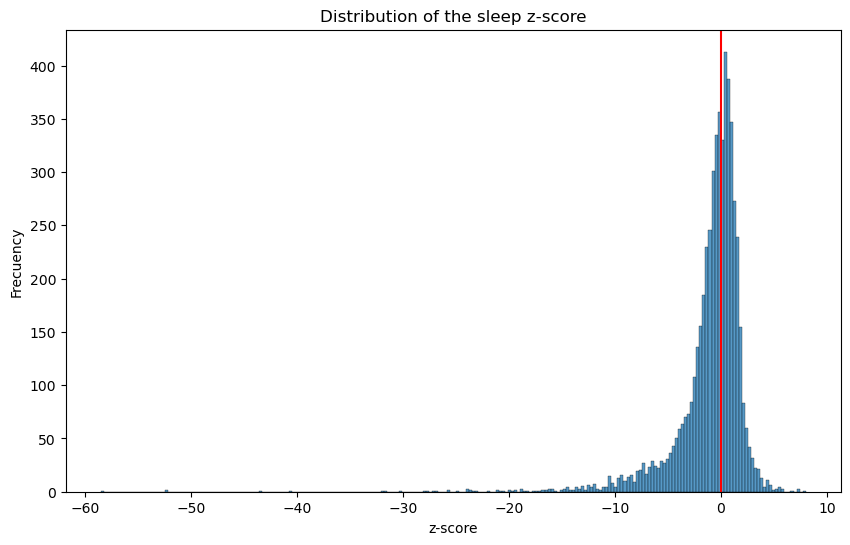

In [60]:
# Histograma z-score sleep

plt.figure(figsize=(10, 6))
sns.histplot(z_sleep.dropna())
plt.axvline(0, color="red", linestyle="-")
plt.title("Distribution of the sleep z-score")
plt.xlabel("z-score")
plt.ylabel("Frecuency")
plt.show()

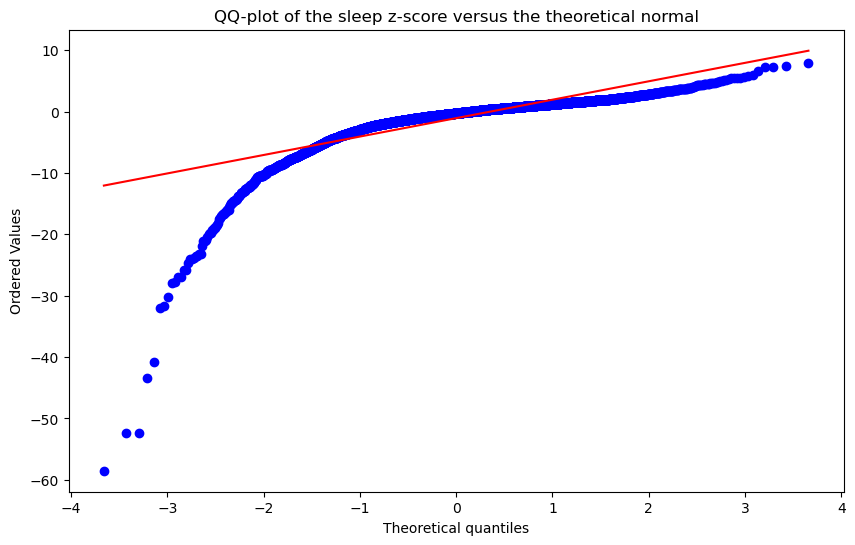

In [61]:
# QQ-plot del z-score de sleep

plt.figure(figsize=(10, 6))
sp.stats.probplot(z_sleep.dropna(), dist="norm", plot=plt)
plt.title("QQ-plot of the sleep z-score versus the theoretical normal")
plt.show()

La distribución de `z_sleep` presenta un pico estrecho en torno a 0 y una cola izquierda muy pesada que se extiende hasta valores cercanos a -60. La cola derecha es corta y se queda alrededor de +8. En el QQ-plot, la parte central de los datos (entre los cuantiles teóricos -2 y +2) sigue razonablemente la diagonal: en ese rango los z-scores se comportan como una normal. 

A partir de ahí, los puntos del lado izquierdo se hunden muy por debajo de la línea, lo que indica observaciones reales mucho más extremas en la cola negativa de lo que predice la normal teórica. La cola derecha, en cambio, queda ligeramente por debajo de la diagonal: las observaciones reales en esa cola son menos extremas que la normal. 

La distribución es asimétrica negativa con cola izquierda pesada, coherente con lo esperado: corresponden a casos de personas que durante una semana entera redujeron drásticamente su sueño respecto a su patrón habitual.

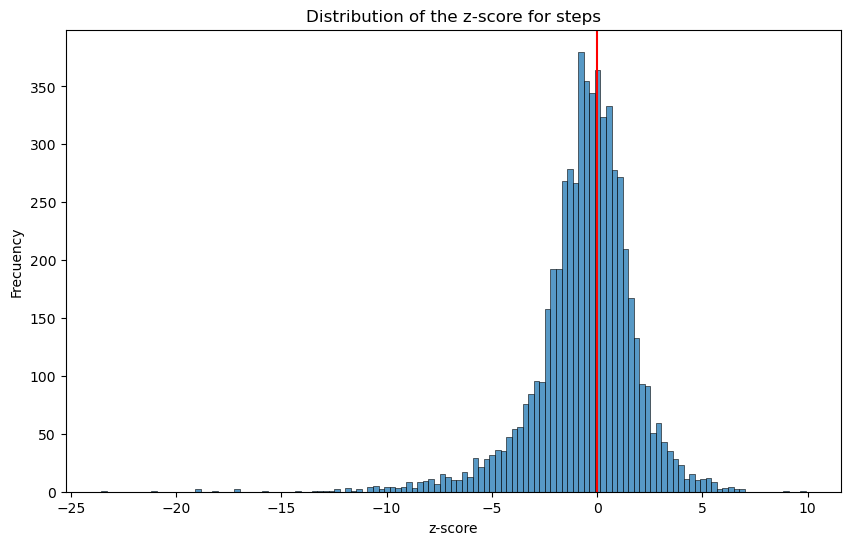

In [62]:
# Histograma z-score steps

plt.figure(figsize=(10,6))
sns.histplot(z_steps.dropna())
plt.axvline(0, color="red", linestyle="-")
plt.title("Distribution of the z-score for steps")
plt.xlabel("z-score")
plt.ylabel("Frecuency")
plt.show()

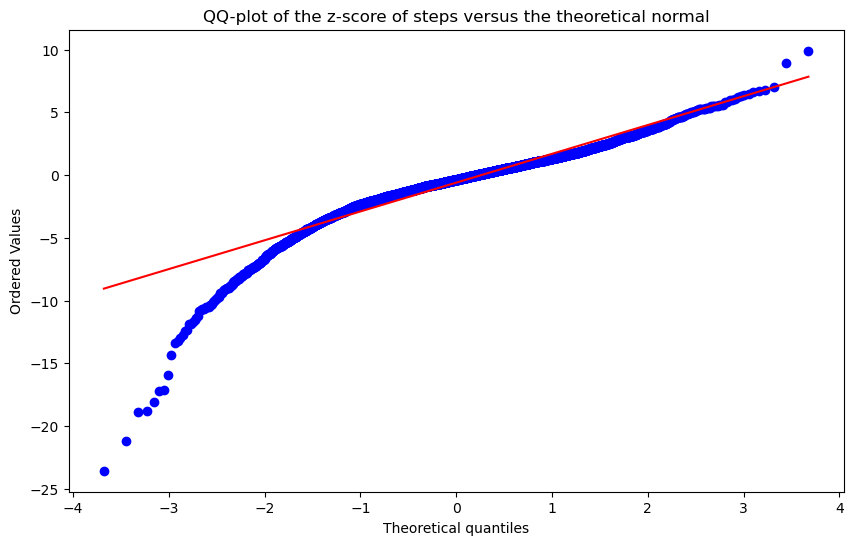

In [63]:
# QQ-plot del z-score de steps

plt.figure(figsize=(10, 6))
sp.stats.probplot(z_steps.dropna(), dist="norm", plot=plt)
plt.title("QQ-plot of the z-score of steps versus the theoretical normal")
plt.show()

La distribución de `z_steps` muestra un pico estrecho centrado ligeramente a la izquierda de 0 y una cola izquierda larga que se extiende hasta -23 aproximadamente. La cola derecha es más corta y simétrica de lo habitual, quedándose en torno a +10. En el QQ-plot, la parte central (entre los cuantiles teóricos -2 y +2) sigue la diagonal con bastante fidelidad. 

Los puntos del lado izquierdo se separan claramente hacia abajo a partir del cuantil -2, indicando una cola izquierda significativamente más pesada que la normal teórica. La cola derecha se mantiene cerca de la diagonal con desviación leve. La distribución es asimétrica negativa pero menos extrema que la de sleep, lo que es coherente con que las caídas drásticas de actividad física a lo largo de una semana sean menos frecuentes en magnitud que las privaciones de sueño extremas.

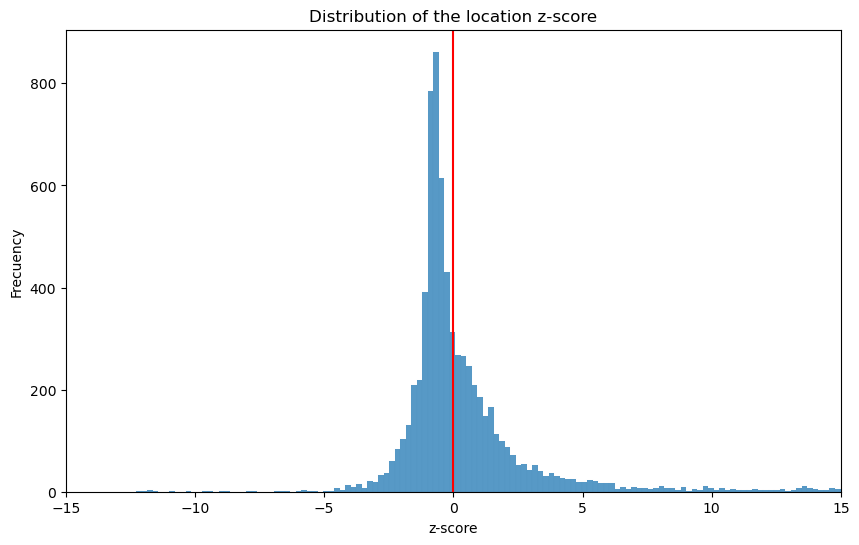

In [64]:
# Histograma z-score location

plt.figure(figsize=(10,6))
sns.histplot(z_location.dropna())
plt.axvline(0, color="red", linestyle="-")
plt.title("Distribution of the location z-score")
plt.xlabel("z-score")
plt.ylabel("Frecuency")
plt.xlim(-15, 15)
plt.show()

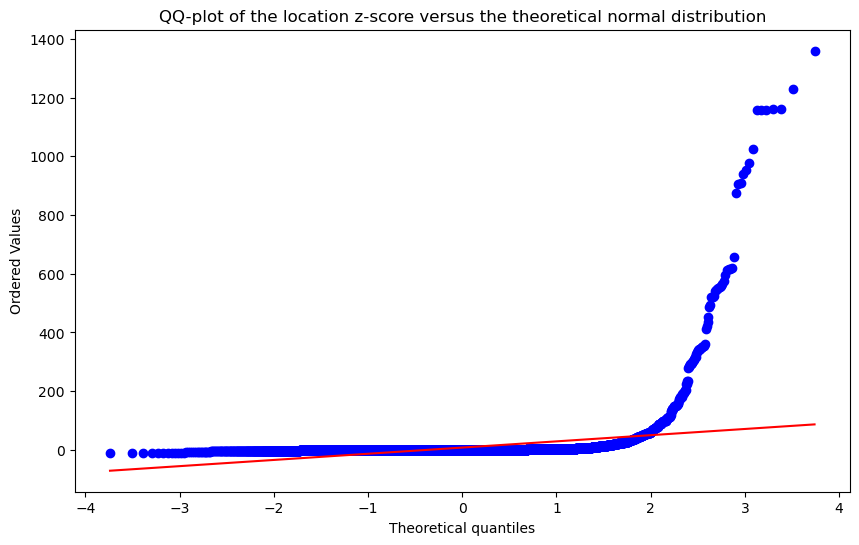

In [65]:
# QQ-plot del z-score de location

plt.figure(figsize=(10, 6))
sp.stats.probplot(z_location.dropna(), dist="norm", plot=plt)
plt.title("QQ-plot of the location z-score versus the theoretical normal distribution")
plt.show()

La distribución de `z_location` presenta un pico estrecho centrado ligeramente a la izquierda de 0 y una asimetría visible hacia la derecha: la cola derecha es notablemente más larga que la izquierda. El histograma se ha recortado al rango [-15, +15] para hacer visible la forma central de la distribución, ya que los valores extremos llegan hasta z=+1360 y harían ilegible el gráfico con escala automática. 

En el QQ-plot (que sí muestra todo el rango sin recorte) se aprecia con claridad esta naturaleza: la parte central de los datos sigue la diagonal hasta el cuantil teórico +2, pero a partir de ahí los puntos se disparan verticalmente alcanzando valores reales superiores a 1000. La cola izquierda apenas se desvía de la diagonal. 

La distribución es por tanto asimétrica positiva con cola derecha extremadamente pesada, coherente con la naturaleza de la dimensión: días aislados de movilidad muy elevada (viajes, mudanzas) sobre un patrón habitual de movilidad reducida producen z-scores muy grandes en el lado positivo.

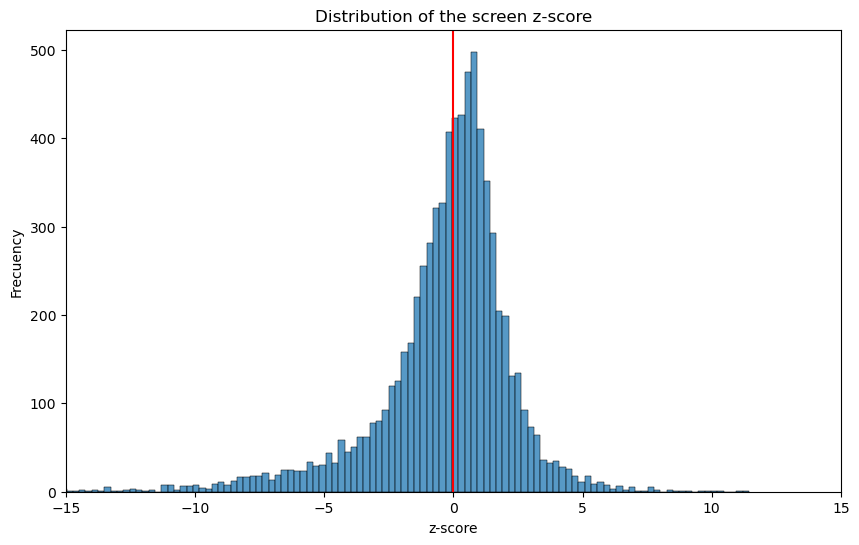

In [66]:
# Histograma z-score screen

plt.figure(figsize=(10,6))
sns.histplot(z_screen.dropna())
plt.axvline(0, color="red", linestyle="-")
plt.title("Distribution of the screen z-score")
plt.xlabel("z-score")
plt.ylabel("Frecuency")
plt.xlim(-15, 15)
plt.show()

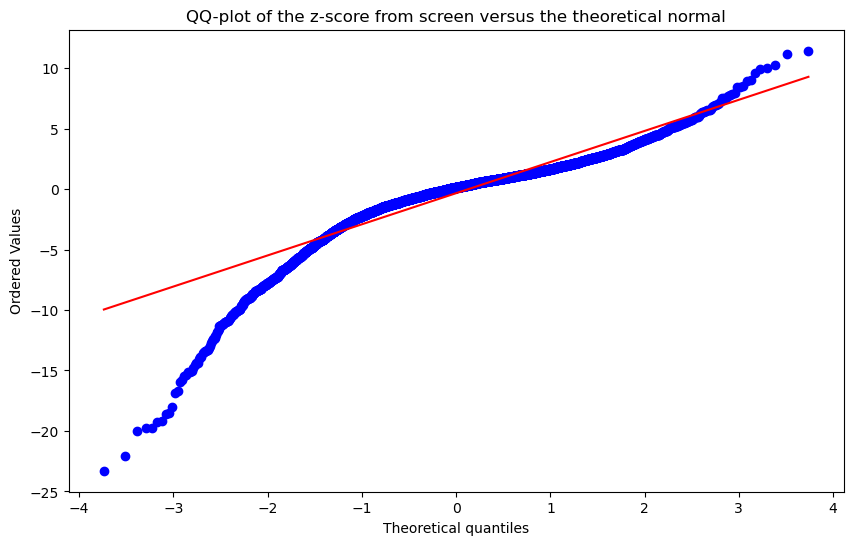

In [67]:
# QQ-plot del z-score de location

plt.figure(figsize=(10, 6))
sp.stats.probplot(z_screen.dropna(), dist="norm", plot=plt)
plt.title("QQ-plot of the z-score from screen versus the theoretical normal")
plt.show()

La distribución de `z_screen` muestra un pico estrecho centrado ligeramente a la derecha de 0 y dos colas asimétricas: la izquierda se extiende hasta valores cercanos a -23, claramente más pesada que la derecha, que se queda en torno a +11. En el QQ-plot, la parte central sigue la diagonal con buena fidelidad entre los cuantiles teóricos -2 y +2. 

A partir del cuantil -2 los puntos del lado izquierdo se separan hacia abajo de forma marcada, llegando hasta valores reales próximos a -23. La cola derecha se desvía ligeramente por encima de la diagonal pero con magnitudes mucho más contenidas. 

La distribución es asimétrica negativa con cola izquierda pesada, similar en forma a sleep y steps aunque con magnitudes intermedias. Corresponde a casos de personas que durante una semana redujeron drásticamente su uso de pantalla respecto a su patrón habitual.

#### Conclusiones de la inspección visual conjunta

La inspección de las cuatro dimensiones permite identificar tres patrones comunes y una asimetría diferencial entre dimensiones.

**Patrones comunes a las cuatro Series:**

- **La zona central de cada distribución sigue razonablemente la normal teórica.** Entre los cuantiles teóricos -2 y +2, los QQ-plots de las cuatro dimensiones se mantienen cerca de la diagonal. Eso significa que para valores moderados del z-score (los que ocurren la mayor parte del tiempo), la aproximación normal funciona razonablemente bien.

- **Las colas son consistentemente más pesadas que la normal.** En las cuatro dimensiones, los QQ-plots se separan de la diagonal en al menos uno de los extremos, con magnitudes que superan claramente lo predicho por la normal teórica.

- **El pico central es estrecho.** Los histogramas muestran que la mayor parte de la masa se concentra cerca de 0, lo que es consistente con un sistema donde la mayoría de los días una persona está cerca de su patrón habitual, con desviaciones grandes ocurriendo solo de forma puntual.

**Asimetría diferencial entre dimensiones:**

- **Sleep, steps y screen** tienen asimetría negativa: cola izquierda pesada. Las desviaciones grandes ocurren predominantemente por defecto respecto al patrón habitual (semanas de menos sueño, menos actividad, menos uso de pantalla).
- **Location** tiene asimetría positiva: cola derecha pesada. Las desviaciones grandes ocurren predominantemente por exceso (semanas de movilidad muy superior al patrón habitual, asociadas a viajes o mudanzas).

Esta diferencia es coherente con la naturaleza de cada variable: el sueño y la actividad tienen un techo natural (no se puede dormir o moverse arbitrariamente más), mientras que la movilidad tiene un techo mucho más alto (un viaje puede multiplicar el radio de giro habitual por varios órdenes de magnitud).

**Conexión con la decisión de diseño.**

Los gráficos confirman visualmente lo que la sección 3.6 demostró empíricamente: las cuatro distribuciones del z-score son no-normales, con asimetría diferencial entre dimensiones (negativa en sleep, steps y screen; positiva en location) y colas pesadas en todas. 

Esta es exactamente la forma esperada bajo la decisión de no transformar las variables: la asimetría intra-sujeto es la señal que el sistema quiere capturar, no es ruido a eliminar, y los QQ-plots la hacen visible como separación clara de la diagonal en al menos uno de los extremos.

La consecuencia operativa (tasa de falsas alarmas superior a la teórica si se aplican umbrales clásicos directamente sobre el z individual) se mitiga estructuralmente con las reglas de persistencia 5 días y convergencia 2/3, y se evaluará empíricamente en el Bloque 7.

### 3.8. Cierre del Bloque 3

El Bloque 3 produce cuatro `Series` con MultiIndex `(pid, idx)`, una por dimensión conductual (`z_sleep`, `z_steps`, `z_location`, `z_screen`), que materializan el z-score intra-sujeto `(observación − mean) / std` sobre los pares persona-día evaluables. 

La media y la desviación típica son las del baseline rolling construido en el Bloque 2. Los z-scores se mantienen como Series separadas por dimensión y no como columnas añadidas al DataFrame, por tres razones: el z-score no es propiedad de la observación cruda sino una relación con un baseline concreto; su dominio natural son los pares evaluables, no todos los pares; y los bloques posteriores operan sobre las cuatro dimensiones simultáneamente, lo que se resuelve trivialmente con cuatro Series del mismo índice.

El sistema renuncia a comparar entre personas. Una persona con `z_sleep = -3` y otra con `z_sleep = -3` no son comparables entre sí: cada uno se compara contra su propio patrón habitual reciente, no contra una población. 

El z-score numérico habla de la desviación relativa de cada persona respecto a sí misma, no de severidad absoluta. Por la misma razón, el sistema renuncia a normalidad estadística: la inspección visual del paso 5 confirma que las distribuciones no son normales y la decisión es no transformar las variables.

La elección del z-score como pieza central del sistema acepta tres compromisos:

- El z-score combina centro y dispersión en una sola fórmula, lo que hace al sistema más compacto pero le quita la capacidad de detectar por separado cambios de centro y cambios de dispersión. Esa pérdida se compensa parcialmente en el Bloque 7 con métodos acumulativos (CUSUM, EWMA) que detectan derivas estructurales independientemente del baseline rolling.

- El z-score depende del baseline rolling, que adapta la referencia día a día. Esto permite seguir cambios contextuales de la vida de la persona (mudanzas, cambios de trabajo) sin disparar falsas alertas, pero también significa que un deterioro muy gradual puede ser absorbido por el propio baseline. Esta absorción está mitigada por la regla de persistencia 5 días y por los métodos del Bloque 7.

- La no-normalidad observada (verificada empíricamente en la sección 3.6 y visualizada en 3.7) implica que los umbrales clásicos tipo `|z| > 3` producirían más falsas alarmas que la teoría predice. La regla de persistencia 5 días + convergencia 2/3 entre dimensiones está diseñada para mitigar esta consecuencia, y el plan de contingencia del Bloque 7 define las opciones de respaldo si la mitigación no es suficiente.

---

<h2>Bloque 4: Series temporales</h2>

Hasta el Bloque 3 hemos producido cuatro `Series` del z-score (`z_sleep`, `z_steps`, `z_location`, `z_screen`), cada una con un valor numérico por par persona-día evaluable. Hemos caracterizado su distribución (histogramas, QQ-plots, asimetría) y hemos documentado que esa distribución no es normal, con asimetría diferencial entre dimensiones y colas pesadas en todas. La inspección del Bloque 3 fue una foto estática del z-score: agregamos todos los valores sin distinguir cuándo ocurrieron y miramos cómo se reparten en terminos de magnitud.

El Bloque 4 abre otra dimensión: el tiempo. Las cuatro `Series` son secuencias ordenadas día a día, no nubes de valores. Si una persona tuvo z-score -2 el día 30 y z-score +1 el día 60, en el histograma esos dos valores aparecen sin relación, pero en la realidad temporal son dos puntos de una trayectoria que conecta uno con otro a lo largo de 30 días intermedios.

Esa trayectoria contiene información que la distribución no captura: si hay tendencias sostenidas, si los días se parecen entre sí, si la señal cambia de régimen, si hay ciclos o estacionalidades. Toda esa información es necesaria para los bloques posteriores.

El Bloque 4 aborda tres tareas en este orden:

1. **Inspección visual de trayectorias temporales** de los z-scores en participantes representativos. Establece cualitativamente cómo se mueve la señal en el tiempo antes de medir nada cuantitativamente.

2. **Análisis de autocorrelación** de las cuatro dimensiones. Medir cuánta dependencia temporal existe entre días consecutivos y a distintos lags, ya que los z-scores no son independientes por construcción (el baseline rolling crea correlación inducida).

3. **Caracterización con ventanas rolling** sobre los z-scores. Complementa la inspección visual con métricas cuantitativas de variabilidad local, estabilidad y tendencias suaves.

En definitiva, este es un bloque de diagnóstico temporal. Las features para el sistema se construirán en el Bloque 5, una vez se conozca el comportamiento temporal que diagnostique este bloque.

### 4.1. Inspección visual de trayectorias temporales

Antes de medir nada, se miran las series del z-score como secuencias día a día, para comprobar de forma cualitativa que las trayectorias tienen estructura temporal (no son ruido plano alrededor de cero) y que las dimensiones no comparten escala. Lo que aquí se ve a ojo se confirmará cuantitativamente en las secciones siguientes.

El primer paso es unir las cuatro Series del z-score (Bloque 3) en un único DataFrame con multiIndex (pid, idx) y una columna por dimensión. Este objeto, `df_z`, es la base sobre la que operan todos los pasos del Bloque 4, y de él parten el truncamiento (4.2) y el rolling (4.4) que alimentan el sistema de detección.

In [68]:
# ── Bloque 4 · Setup (punto de re-entrada) ─────────────────────────
# Reconstruimos df_z desde las cuatro Series del z-score (Bloque 3) y
# guardamos una copia intacta. Esta es la única celda que crea df_z.
df_z = pd.concat(
    [z_sleep, z_steps, z_location, z_screen],
    axis=1,
    keys=["sleep", "steps", "location", "screen"]
)
df_z_original = df_z.copy()   # copia congelada: NUNCA se modifica
df_z.head(35)

sleep     steps  location  screen
pid                                               
INS-W_001 0        NaN       NaN       NaN     NaN
          1        NaN       NaN       NaN     NaN
          2        NaN       NaN       NaN     NaN
          3        NaN       NaN       NaN     NaN
          4        NaN       NaN       NaN     NaN
          5        NaN       NaN       NaN     NaN
          6        NaN       NaN       NaN     NaN
          7        NaN       NaN       NaN     NaN
          8        NaN       NaN       NaN     NaN
          9        NaN       NaN       NaN     NaN
          10       NaN       NaN       NaN     NaN
          11       NaN       NaN       NaN     NaN
          12       NaN       NaN       NaN     NaN
          13       NaN       NaN       NaN     NaN
          14       NaN       NaN       NaN     NaN
          15       NaN       NaN       NaN     NaN
          16       NaN       NaN       NaN     NaN
          17       NaN       NaN       NaN     NaN
          18       NaN       NaN       NaN     NaN
          19       NaN       NaN       NaN     NaN
          20       NaN       NaN       NaN     NaN
          21       NaN       NaN       NaN     NaN
          22       NaN       NaN       NaN     NaN
          23       NaN       NaN       NaN     NaN
          24       NaN       NaN       NaN     NaN
          25       NaN       NaN       NaN     NaN
          26       NaN       NaN       NaN     NaN
          27       NaN       NaN       NaN     NaN
          28 -0.588216 -0.851843       NaN     NaN
          29 -0.478832  0.370595       NaN     NaN
          30  0.416003  1.182795       NaN     NaN
          31  0.664682  1.121695       NaN     NaN
          32  1.654369  0.517294       NaN     NaN
          33  1.205828  0.775507       NaN     NaN
          34  0.908583  1.083414       NaN     NaN

Para elegir tres participantes representativos calculamos **dos métricas** por participante a partir de **df_z**: 

- ``cobertura``: número total de pares persona-día evaluables sumando las cuatro dimensiones.
- ``variabilidad``: desviación típica promedio de los z-scores de las cuatro dimensiones. 

El **primer perfil** se busca como alta cobertura y baja variabilidad (trayectoria estable), el **segundo** como alta cobertura y alta variabilidad (trayectoria con cambios visibles), el **tercero** como cobertura intermedia.

In [69]:
# Calculamos las métricas de cada participante recorriéndolos uno a uno
rows = []
for pid, group in df_z_original.groupby("pid"):
    coverage = group.notna().sum().sum()   # nº total de valores no vacíos del grupo
    variability = group.std().mean()       # desviación típica media de las columnas
    rows.append({"pid": pid, "coverage": coverage, "variability": variability})

metrics = pd.DataFrame(rows).set_index("pid")

# Umbrales (percentiles) sobre las dos métricas
p50_cov = metrics["coverage"].median()
p75_cov = metrics["coverage"].quantile(0.75)
p25_var = metrics["variability"].quantile(0.25)
p75_var = metrics["variability"].quantile(0.75)

# Perfil 1: alta cobertura + baja variabilidad
mask_stable = (metrics["coverage"] >= p75_cov) & (metrics["variability"] <= p25_var)
stable = metrics[mask_stable].sort_values("variability")
pid_stable = stable.index[0]

# Perfil 2: alta cobertura + alta variabilidad
mask_changes = (metrics["coverage"] >= p75_cov) & (metrics["variability"] >= p75_var)
changes = metrics[mask_changes].sort_values("variability", ascending=False)
pid_changes = changes.index[0]

# Perfil 3: cobertura intermedia (en torno a la mediana)
mask_intermediate = (metrics["coverage"] >= p50_cov * 0.9) & (metrics["coverage"] <= p50_cov * 1.1)
intermediate = metrics[mask_intermediate].sort_values("coverage")
middle_position = len(intermediate) // 2
pid_intermediate = intermediate.index[middle_position]

selected_participants = {
    "stable":                pid_stable,
    "with changes":          pid_changes,
    "intermediate coverage": pid_intermediate,
}

print("Participants selected for visual inspection:")
print()
for profile, pid in selected_participants.items():
    cov = metrics.loc[pid, "coverage"]
    var = metrics.loc[pid, "variability"]
    print(f"  {profile:<25} {pid}  (coverage={cov:.0f}/{4*92}, variability={var:.3f})")

Participants selected for visual inspection:

  stable                    INS-W_126  (coverage=213/368, variability=1.920)
  with changes              INS-W_157  (coverage=224/368, variability=63.220)
  intermediate coverage     INS-W_036  (coverage=197/368, variability=6.324)


La salida confirma los tres participantes elegidos, uno por perfil:

- INS-W_126 (estable) tiene buena cobertura (213 de 368 posibles) y la variabilidad más baja (1.92), señal de una conducta sostenida alrededor de su patrón. 
- INS-W_157 (con cambios) tiene cobertura similar (224) pero una variabilidad muy alta (63.22), lo que anticipa trayectorias con desplazamientos marcados. 
- INS-W_036 (cobertura intermedia) se sitúa en torno a la mediana (197) con variabilidad moderada (6.32). 


### 4.2. Truncamiento por participante y dimensión

Las trayectorias de z-score presentan una caída marcada hacia valores muy negativos en los últimos días del registro de muchos participantes. No es señal conductual: es consecuencia de cómo se construye la ventana móvil cuando los datos diarios no están completos.

El dataset GLOBEM trae dos familias paralelas: 

- `7dhist`: suma móvil de 7 días sobre la que se construye todo el sistema.
- `allday`: el valor diario crudo. 

El `7dhist[d]` se calcula sobre los siete `allday` de `[d-6, d]`. Cuando uno o más de esos siete `allday` están a NaN, el agregado se hace con menos sumandos y queda artificialmente bajo. 

El z-score, contra un baseline construido con datos íntegros, hereda el sesgo y produce la caída.

Sin tratarlo, el sistema dispararía alertas masivas sobre días contaminados por agregados incompletos, no sobre cambios conductuales. Hay que cortar cada serie antes de que entre en su zona de caida. El corte no puede ser común a toda la cohorte porque el momento en que cada participante empieza a tener huecos en allday varía.

La solución adoptada es un corte por participante y dimensión: para cada combinación se identifica el último día con la ventana de siete `allday` completa, y todos los z-scores posteriores se ponen a NaN. Es propio de cada participante porque cada uno pierde cobertura en un momento distinto, y propio de cada dimensión porque sueño, pasos, movilidad y uso del móvil pueden degradarse en días distintos para una misma persona.

In [70]:
# Partimos de la copia intacta para que el truncamiento sea
# re-ejecutable y no arrastre los NaN de una ejecución anterior.
df_z = df_z_original.copy()

# Truncamiento por (participante, dimensión):
# poner a NaN los z-scores posteriores al último día con ventana :allday[d-6:d+1] íntegra.
allday_cols = {
    "sleep":    (df_sleep,    "f_slp:fitbit_sleep_summary_rapids_sumdurationasleepmain:allday"),
    "steps":    (df_steps,    "f_steps:fitbit_steps_intraday_rapids_sumsteps:allday"),
    "location": (df_location, "f_loc:phone_locations_barnett_rog:allday"),
    "screen":   (df_screen,   "f_screen:phone_screen_rapids_sumdurationunlock:allday"),
}

# 1. Identificar el último día con ventana :allday íntegra por participante y dimensión
last_valid_day = {}
for dim, (df, col) in allday_cols.items():
    df_sorted = df.sort_values(["pid", "day"]).copy()

    # Recorremos participante a participante
    last_day_per_pid = {}
    for pid, group in df_sorted.groupby("pid"):
        # ¿Tiene dato cada día? (True/False)
        has_data = group[col].notna()
        # ¿Cuántos de los últimos 7 días tienen dato? (ventana de 7, exige los 7)
        sum_7days = has_data.rolling(window=7, min_periods=7).sum()
        # La ventana está íntegra cuando los 7 días tienen dato
        full_window = sum_7days == 7
        valid_days = group["day"][full_window]
        # Guardamos el último día válido (si lo hay) de este participante
        if len(valid_days) > 0:
            last_day_per_pid[pid] = valid_days.max()

    last_valid_day[dim] = pd.Series(last_day_per_pid)

# 2. Aplicar el truncamiento: NaN para todos los días posteriores al corte
# Posición relativa de cada día dentro de cada participante (0, 1, 2, ...)
day_relative = df_z.groupby(level="pid").cumcount()

# pid que le corresponde a cada fila de df_z
pids_z = df_z.index.get_level_values("pid")
pid_per_row = pd.Series(pids_z, index=df_z.index)

for dim in ["sleep", "steps", "location", "screen"]:
    # Día de corte que le toca a cada fila según su participante (-1 si no tiene corte)
    last_day = pid_per_row.map(last_valid_day[dim]).fillna(-1)
    # Marcamos como inválidos los días posteriores al corte
    mask_invalid = day_relative.values > last_day.values
    df_z.loc[mask_invalid, dim] = np.nan

# 3. Verificación
print("Person-day pairs kept per dimension after per-participant truncation:")
for dim in ["sleep", "steps", "location", "screen"]:
    n = df_z[dim].notna().sum()
    print(f"  {dim:<10}: {n}")

print("\nCut-off day per participant and dimension:")
for pid in selected_participants.values():
    cuts = {dim: last_valid_day[dim].get(pid, None) for dim in ["sleep","steps","location","screen"]}
    print(f"  {pid}: {cuts}")

Person-day pairs kept per dimension after per-participant truncation:
  sleep     : 4386
  steps     : 5060
  location  : 6579
  screen    : 6489

Cut-off day per participant and dimension:
  INS-W_126: {'sleep': 69, 'steps': 77, 'location': 72, 'screen': 72}
  INS-W_157: {'sleep': 76, 'steps': 77, 'location': 77, 'screen': 78}
  INS-W_036: {'sleep': 70, 'steps': 71, 'location': 70, 'screen': 70}


Los tres participantes seleccionados cortan en días distintos según la dimensión, que es la propiedad clave del método: cada (pid, dim) cierra en su propio día efectivo, sin fijar la cota manualmente.

El truncamiento deja el z-score limpio de los descensos terminales por datos incompletos, listo para el análisis temporal. El siguiente paso, el análisis de autocorrelación, cuantifica la dependencia temporal de las series: qué fracción es estructural (inducida por construcción del baseline rolling sobre ventanas solapadas) y qué fracción es señal conductual auténtica.

### 4.3. Análisis de autocorrelación

Este análisis cuantifica la dependencia temporal de las series del z-score y la separa en dos componentes: una estructural, inducida por la propia construcción del baseline rolling, y una conductual, que sería la señal temporal real del comportamiento. Separar ambas es el resultado central de la sección.

**Por qué hace falta.** Los z-scores de días vecinos no son independientes por construcción. El baseline del día d se calcula sobre la ventana [d-28, d-8] y el del día d+1 sobre [d-27, d-7]: comparten 20 de sus 21 días, así que son casi idénticos y los z-scores que se derivan heredan correlación entre días próximos. Esa correlación aparecería incluso si la conducta fuera ruido puro. Por eso, antes de construir features en el Bloque 5, hay que saber cuánta de la autocorrelación observada es señal real y cuánta es artefacto del cálculo.

**Cómo se mide.** Se usan dos funciones complementarias: la ACF, que mide la correlación entre un día y los anteriores a distintas distancias (lags), y la PACF, que mide esa correlación descontando la influencia de los días intermedios. Leídas juntas indican qué tipo de dependencia temporal tiene la serie.

**Cómo se separa lo estructural de lo conductual.** Se generan 1000 series de ruido aleatorio sin señal conductual y se procesan por el mismo pipeline que los datos reales (7dhist, baseline rolling, z-score). Su autocorrelación media es la línea base estructural: la que el cálculo introduce por sí solo. Comparar las curvas reales con esa línea base deja al descubierto la autocorrelación conductual neta.

El análisis se realiza primero sobre los tres participantes seleccionados (INS-W_126, INS-W_157, INS-W_036) y después a nivel de cohorte, sobre todos los participantes con cobertura suficiente. El rango llega hasta el lag 21, suficiente para ver la huella temporal de las series.

In [71]:
N_LAGS_ACF = 21
N_LAGS_PACF = 20

# Calcular ACF y PACF observadas para cada (pid, dim) de los tres seleccionados
acf_pacf_results = {}
for dim in ["sleep", "steps", "location", "screen"]:
    acf_pacf_results[dim] = {}
    for profile, pid in selected_participants.items():
        # Serie de este participante en esta dimensión, sin huecos
        series = df_z.loc[pid, dim].dropna()
        # Si hay pocas observaciones, no se puede calcular PACF de forma fiable
        if len(series) < 2 * N_LAGS_PACF + 2:
            print("Skipped:", pid, dim, "only has", len(series), "observations")
            continue
        acf_vals = acf(series, nlags=N_LAGS_ACF, fft=False)
        pacf_vals = pacf(series, nlags=N_LAGS_PACF, method="ywm")
        acf_pacf_results[dim][pid] = {
            "acf": acf_vals,
            "pacf": pacf_vals,
            "profile": profile,
            "n_obs": len(series),
        }

# Mostramos el ACF en el lag 1 (la dependencia con el día anterior) de cada serie
print("ACF at lag 1 (correlation with the previous day):")
for dim in ["sleep", "steps", "location", "screen"]:
    for pid in acf_pacf_results[dim]:
        lag1_value = acf_pacf_results[dim][pid]["acf"][1]
        rounded_value = round(lag1_value, 3)
        print(dim, pid, "->", rounded_value)

ACF at lag 1 (correlation with the previous day):
sleep INS-W_126 -> 0.843
sleep INS-W_157 -> 0.847
sleep INS-W_036 -> 0.851
steps INS-W_126 -> 0.919
steps INS-W_157 -> 0.878
steps INS-W_036 -> 0.866
location INS-W_126 -> 0.896
location INS-W_157 -> 0.795
location INS-W_036 -> 0.765
screen INS-W_126 -> 0.693
screen INS-W_157 -> 0.899
screen INS-W_036 -> 0.384


La salida muestra el ACF en el lag 1 (la correlación de cada día con el día anterior) para los tres participantes en las cuatro dimensiones. Los valores son altos y muy parecidos entre sí: rondan 0.85 en sleep (0.843, 0.847, 0.851), suben por encima de 0.86 en steps, y se mueven entre 0.76 y 0.90 en location y screen. La única excepción baja es screen en INS-W_036 (0.384).

Esa uniformidad es el dato relevante: en casi todas las series, el valor de hoy está fuertemente ligado al de ayer, con una magnitud similar entre dimensiones y entre personas. Si la dependencia fuera señal conductual real, no habría razón para que apareciera tan parecida en todos. Que sea tan constante apunta a que la genera el propio cálculo (los baselines de días vecinos comparten 20 de 21 días), no el comportamiento. El valor de referencia, en torno a 0.85, es el que la simulación de ruido del siguiente paso usa para separar lo estructural de lo conductual.

**Línea base estructural por simulación de ruido.**

Queda por determinar cuánto de esa autocorrelación es señal real y cuánto es efecto del propio cálculo. Para separarlo se procesa ruido aleatorio sin señal por el mismo pipeline: la autocorrelación que resulta es el efecto puro del cálculo, y la diferencia respecto a la observada es la conexión conductual real.

In [72]:
# Parámetros del pipeline
N_SIM = 1000
N_DAYS_RAW = 92
W_7D = 7         # ventana :7dhist
W_BASELINE = 21  # ventana del baseline rolling
BUFFER = 7       # buffer entre fin de baseline y día evaluado

def apply_zscore_pipeline(raw):
    "Aplica raw -> :7dhist -> baseline rolling -> z-score."
    n = len(raw)
    sevendhist = np.full(n, np.nan)
    for d in range(n):
        start = d - W_7D + 1
        if start < 0:
            start = 0
        sevendhist[d] = raw[start : d + 1].sum()
    for d in range(W_7D):
        sevendhist[d] = np.nan
    z = np.full(n, np.nan)
    for d in range(n):
        start = d - W_BASELINE - BUFFER + 1
        if start < 0:
            start = 0
        window = sevendhist[start : d - BUFFER + 1]
        valid_window = window[~np.isnan(window)]
        if len(valid_window) >= 15:
            b_mean = valid_window.mean()
            b_std = valid_window.std(ddof=1)
            if b_std > 0:
                z[d] = (sevendhist[d] - b_mean) / b_std
    return z

# Generación de N_SIM series y cálculo de ACF/PACF estructurales
np.random.seed(42)
acf_struct_list = []
pacf_struct_list = []

for _ in range(N_SIM):
    raw = np.random.randn(N_DAYS_RAW)
    z = apply_zscore_pipeline(raw)
    z_valid = z[~np.isnan(z)]
    if len(z_valid) < 2 * N_LAGS_PACF + 2:
        continue
    acf_struct_list.append(acf(z_valid, nlags=N_LAGS_ACF, fft=False))
    pacf_struct_list.append(pacf(z_valid, nlags=N_LAGS_PACF, method="ywm"))

acf_struct_arr = np.array(acf_struct_list)
pacf_struct_arr = np.array(pacf_struct_list)
acf_struct_mean = acf_struct_arr.mean(axis=0)
pacf_struct_mean = pacf_struct_arr.mean(axis=0)
acf_struct_p2_5 = np.percentile(acf_struct_arr, 2.5, axis=0)
acf_struct_p97_5 = np.percentile(acf_struct_arr, 97.5, axis=0)
pacf_struct_p2_5 = np.percentile(pacf_struct_arr, 2.5, axis=0)
pacf_struct_p97_5 = np.percentile(pacf_struct_arr, 97.5, axis=0)

# Mostramos la linea estructural: el ACF medio del ruido en los primeros lags
print("Valid simulations:", len(acf_struct_list), "of", N_SIM)
print("Structural line (mean ACF of the simulated noise):")
for lag in range(1, 6):
    value = round(acf_struct_mean[lag], 3)
    print("  lag", lag, "->", value)

Valid simulations: 1000 of 1000
Structural line (mean ACF of the simulated noise):
  lag 1 -> 0.841
  lag 2 -> 0.682
  lag 3 -> 0.528
  lag 4 -> 0.377
  lag 5 -> 0.23


La salida muestra la línea estructural: el ACF medio de 1000 series de ruido procesadas por el mismo pipeline. Vale 0.841 en el lag 1 y baja de forma gradual (0.682, 0.528, 0.377, 0.230 en los lags siguientes). El dato clave es que ese 0.841 del ruido coincide casi exactamente con el ACF lag 1 observado en los participantes reales (en torno a 0.85, según la salida anterior).

Esto implica que la mayor parte de la autocorrelación visible en las series del z-score es subproducto del cálculo, no señal conductual real: el ruido puro, sin ninguna conducta dentro, genera la misma dependencia día a día que los datos reales. El componente conductual neto (lo que separa a una persona del ruido) es pequeño. Donde un participante se aparta de esta línea estructural, esa diferencia sí es señal conductual real y queda registrada para análisis posteriores.

**Consecuencia para el diseño de features.** Cualquier feature construido sobre lags cortos del z-score heredará esta dependencia estructural y aportará poca información. Las que capten señal real deben construirse sobre horizontes donde esa dependencia ya se ha disipado, o sobre cambios más amplios (deltas semanales, persistencia de desviaciones sostenidas). La regla operativa del proyecto, convergencia 2/3 con persistencia de 5 días, ya cumple esa condición porque opera sobre el valor sostenido del z-score.

Para validar que el resultado se mantiene a nivel de cohorte, se repite el cálculo de ACF y PACF sobre todos los participantes con al menos 42 observaciones evaluables (mínimo que exige la PACF), se promedia lag a lag y se obtiene una curva media por dimensión con su banda del 95%. Superponerla a la línea base estructural confirma si el patrón visto en los casos individuales es una propiedad de toda la cohorte.

Minimum observations required per participant: 42
Total participants: 155

Participants included per dimension:
  sleep -> 70 participants ( 45.2 % )
  steps -> 90 participants ( 58.1 % )
  location -> 106 participants ( 68.4 % )
  screen -> 102 participants ( 65.8 % )



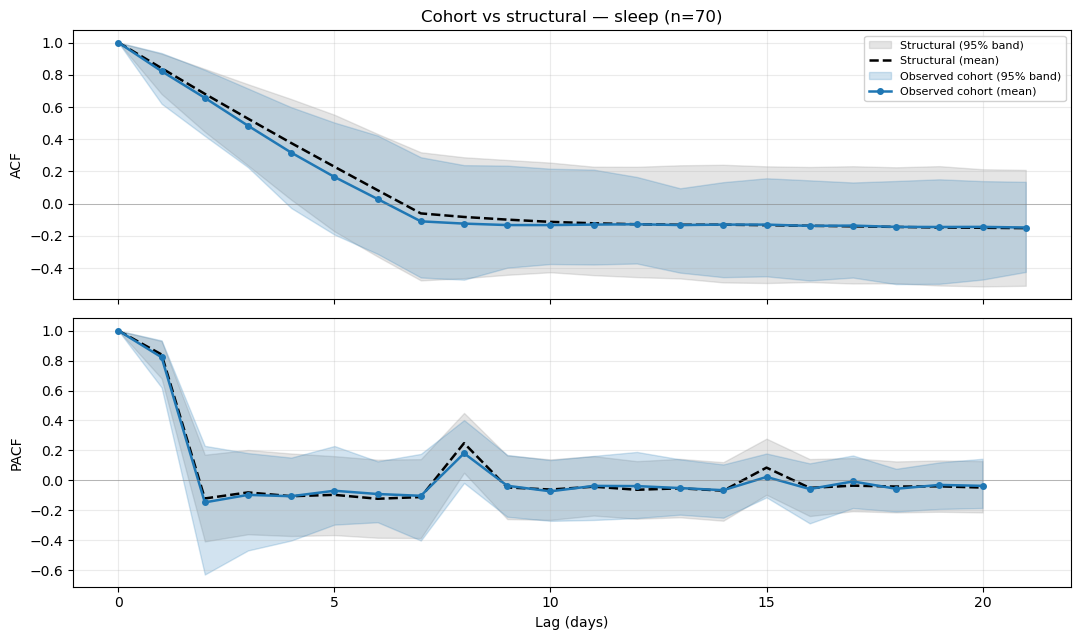

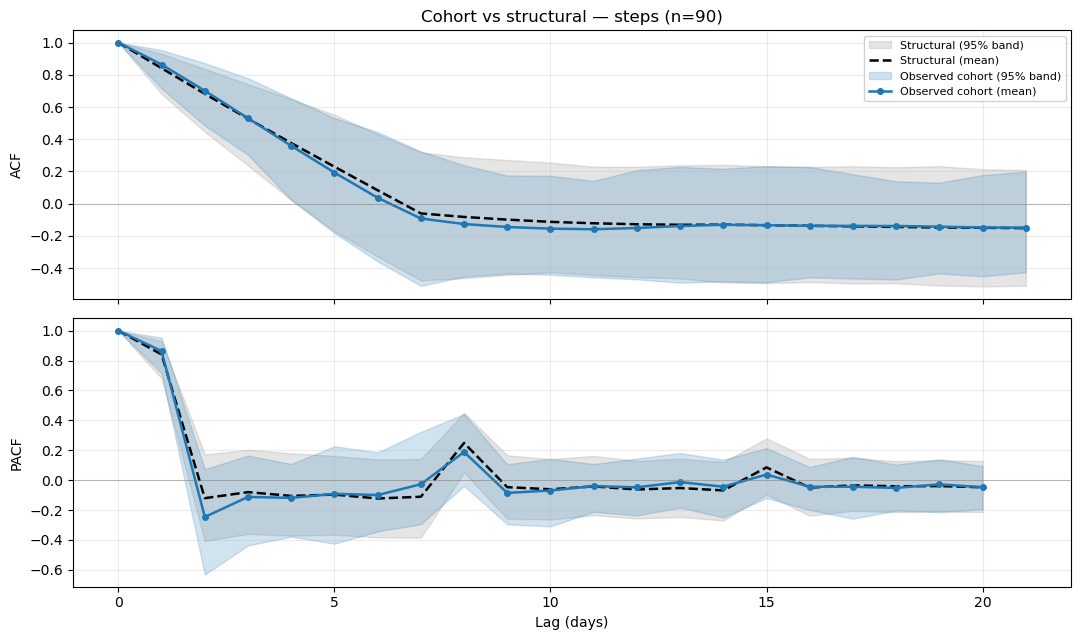

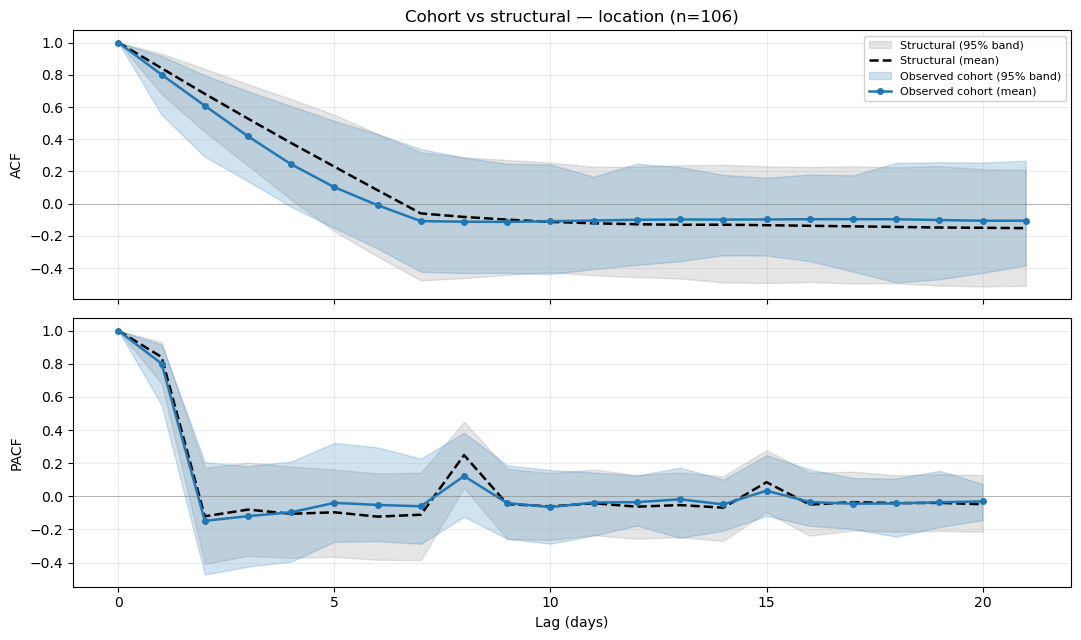

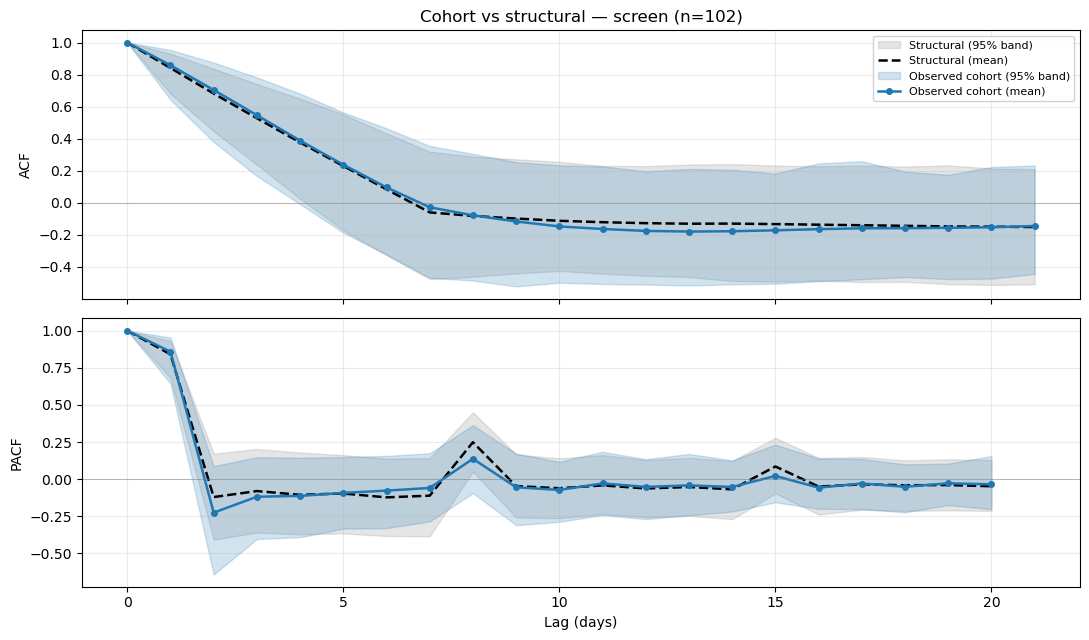

In [73]:
# Agregación a nivel de cohorte: ACF y PACF observadas sobre todos los pids con cobertura suficiente
MIN_OBS_AGGREGATE = 2 * N_LAGS_PACF + 2  # 42 obs minimas para PACF

aggregate_by_dim = {}
for dim in ["sleep", "steps", "location", "screen"]:
    # Recogemos el ACF y el PACF de cada participante con datos suficientes
    acf_list = []
    pacf_list = []
    for pid in df_z.index.get_level_values("pid").unique():
        # Serie de este participante en esta dimension, sin huecos
        series = df_z.loc[pid, dim].dropna()
        if len(series) < MIN_OBS_AGGREGATE:
            continue
        acf_list.append(acf(series, nlags=N_LAGS_ACF, fft=False))
        pacf_list.append(pacf(series, nlags=N_LAGS_PACF, method="ywm"))

    acf_arr = np.array(acf_list)
    pacf_arr = np.array(pacf_list)

    # Guardamos la media y la banda del 95% (percentiles 2.5 y 97.5) por dimension
    dim_data = {}
    dim_data["n_pids"] = len(acf_list)
    dim_data["acf_mean"] = acf_arr.mean(axis=0)
    dim_data["acf_p2_5"] = np.percentile(acf_arr, 2.5, axis=0)
    dim_data["acf_p97_5"] = np.percentile(acf_arr, 97.5, axis=0)
    dim_data["pacf_mean"] = pacf_arr.mean(axis=0)
    dim_data["pacf_p2_5"] = np.percentile(pacf_arr, 2.5, axis=0)
    dim_data["pacf_p97_5"] = np.percentile(pacf_arr, 97.5, axis=0)
    aggregate_by_dim[dim] = dim_data

# Mostramos cuantos participantes entran en cada dimension
total_pids = df_z.index.get_level_values("pid").nunique()
print("Minimum observations required per participant:", MIN_OBS_AGGREGATE)
print("Total participants:", total_pids)
print()
print("Participants included per dimension:")
for dim in ["sleep", "steps", "location", "screen"]:
    n = aggregate_by_dim[dim]["n_pids"]
    percentage = round(100 * n / total_pids, 1)
    print(" ", dim, "->", n, "participants (", percentage, "% )")
print()

# Una figura por dimension: arriba el ACF, abajo el PACF
# En cada panel: la linea estructural (ruido simulado) y la observada de la cohorte
lags_acf = np.arange(N_LAGS_ACF + 1)
lags_pacf = np.arange(N_LAGS_PACF + 1)

for dim in ["sleep", "steps", "location", "screen"]:
    dim_data = aggregate_by_dim[dim]
    n_pids = dim_data["n_pids"]

    fig, (ax_acf, ax_pacf) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)

    # Linea estructural (gris discontinua) con su banda
    ax_acf.fill_between(lags_acf, acf_struct_p2_5, acf_struct_p97_5,
                        alpha=0.20, color="gray", label="Structural (95% band)")
    ax_acf.plot(lags_acf, acf_struct_mean, "k--", linewidth=1.8, label="Structural (mean)")
    ax_pacf.fill_between(lags_pacf, pacf_struct_p2_5, pacf_struct_p97_5,
                         alpha=0.20, color="gray")
    ax_pacf.plot(lags_pacf, pacf_struct_mean, "k--", linewidth=1.8)

    # Linea observada de la cohorte (azul) con su banda
    ax_acf.fill_between(lags_acf, dim_data["acf_p2_5"], dim_data["acf_p97_5"],
                        alpha=0.20, color="C0", label="Observed cohort (95% band)")
    ax_acf.plot(lags_acf, dim_data["acf_mean"], "-o", color="C0", linewidth=1.8,
                markersize=4, label="Observed cohort (mean)")
    ax_pacf.fill_between(lags_pacf, dim_data["pacf_p2_5"], dim_data["pacf_p97_5"],
                         alpha=0.20, color="C0")
    ax_pacf.plot(lags_pacf, dim_data["pacf_mean"], "-o", color="C0", linewidth=1.8,
                 markersize=4)

    # Linea horizontal en cero como referencia
    ax_acf.axhline(0, color="gray", linewidth=0.6, alpha=0.6)
    ax_pacf.axhline(0, color="gray", linewidth=0.6, alpha=0.6)

    ax_acf.set_ylabel("ACF")
    ax_pacf.set_ylabel("PACF")
    ax_pacf.set_xlabel("Lag (days)")
    ax_acf.set_title("Cohort vs structural — " + dim + " (n=" + str(n_pids) + ")")
    ax_acf.legend(loc="best", fontsize=8, framealpha=0.9)
    ax_acf.grid(True, alpha=0.25)
    ax_pacf.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

**Confirmación a nivel de cohorte.**

La media observada a nivel de cohorte y la línea base estructural se solapan casi por completo en las cuatro dimensiones, con bandas del 95% que se cruzan en todo el rango. 

Esto confirma a escala de cohorte lo visto en los tres participantes: el componente conductual neto de la autocorrelación es prácticamente cero. La huella temporal de las series del z-score es subproducto del cálculo con baseline rolling, no señal conductual. 

La señal real vive en desviaciones individuales puntuales, no en la media de la cohorte, lo cual es coherente con el marco N-of-1 del proyecto: la heterogeneidad relevante está entre individuos, no en el promedio.

**Conclusiones análisis de autocorrelación.**

Las dos lecturas de esta sección (individual y a nivel de cohorte) convergen en lo mismo: la dependencia temporal observada en las series del z-score es subproducto del cálculo con baseline rolling. 

El componente conductual neto es prácticamente cero, y la señal real, donde existe, aparece como desviaciones individuales puntuales que quedan registradas para análisis posteriores.

Esto orienta el diseño de features del Bloque 5: deben construirse sobre el valor sostenido del z-score, que es justo lo que la regla de convergencia 2/3 con persistencia de 5 días ya hace. 

La caracterización con ventanas rolling de la sección siguiente complementa este análisis con una descripción del nivel medio y la dispersión del z-score.

### 4.4. Caracterización rolling sobre los z-scores

El análisis de la sección 4.3 estableció que las features con potencial conductual no deben construirse sobre la dependencia entre días, sino sobre los valores del z-score sostenidos en el tiempo. Esta sección desarrolla esa herramienta.

La regla del proyecto detecta desviaciones sostenidas, no picos de un solo día: un día con z-score alto puede ser ruido, pero un desplazamiento que se mantiene durante varios días es lo que se interpreta como deterioro. El rolling mean (promedio del z-score en una ventana móvil) recoge ese desplazamiento sostenido sin verse distorsionado por la fluctuación diaria. El rolling std (desviación típica en la misma ventana) cuantifica si ese nivel es estable o volátil.

**Aclaración importante: el tamaño de venta de 7 días, heredado de la estructura de la señal (la feature primaria es una suma deslizante de 7 días), no debe confundirse con la persistencia de la regla de detección, que es una decisión distinta y se establece en 5 días en el Bloque 5.

Las dos métricas leídas juntas, ``rolling mean`` y ``rolling std``, son las variables sobre las que el Bloque 5 construye el sistema de detección. 

A continuación se calculan para toda la cohorte y se ilustra el resultado con un ejemplo en la dimensión de steps.

Valid values of the rolling mean per dimension:
  sleep -> 3651
  steps -> 4274
  location -> 5644
  screen -> 5551



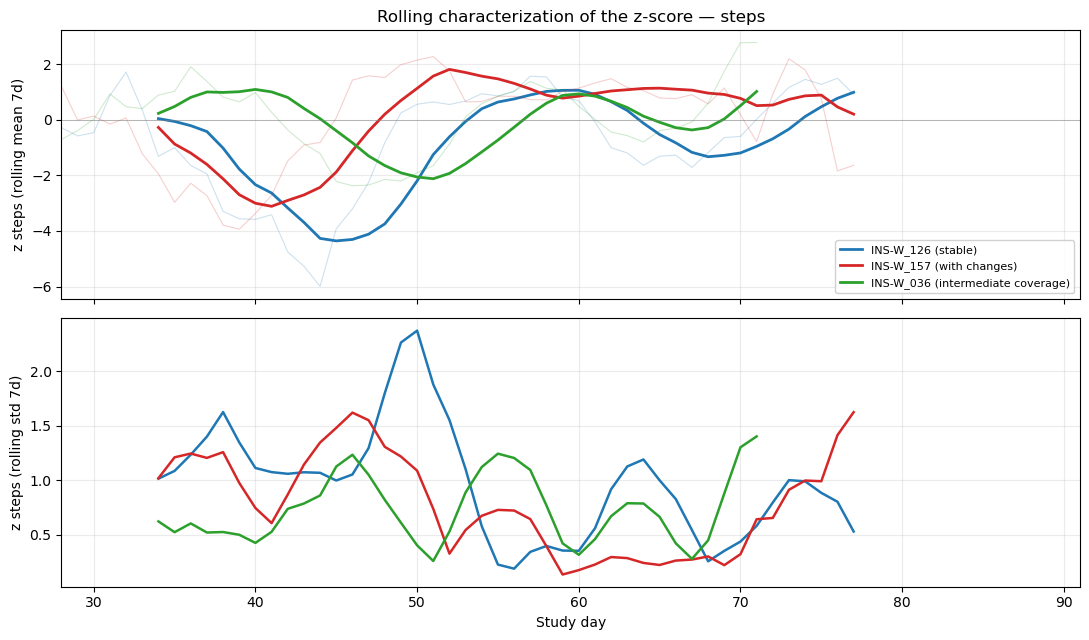

In [74]:
W_ROLL = 7

# Rolling mean y rolling std del z-score, calculados participante a participante
# (recorremos cada pid, aplicamos la ventana móvil de 7 días y reensamblamos)
roll_mean_parts = []
roll_std_parts = []
for pid, group in df_z.groupby(level="pid"):
    roll_mean_parts.append(group.rolling(window=W_ROLL, min_periods=W_ROLL).mean())
    roll_std_parts.append(group.rolling(window=W_ROLL, min_periods=W_ROLL).std())

# reindex al índice original de df_z para conservar el mismo orden de filas
df_z_roll_mean = pd.concat(roll_mean_parts).reindex(df_z.index)
df_z_roll_std = pd.concat(roll_std_parts).reindex(df_z.index)

# Comprobación: cuántos valores válidos produce cada métrica por dimensión
print("Valid values of the rolling mean per dimension:")
for dim in ["sleep", "steps", "location", "screen"]:
    n = df_z_roll_mean[dim].notna().sum()
    print(" ", dim, "->", n)
print()

# Ejemplo ilustrativo: dimension steps, los tres participantes
# (arriba el rolling mean sobre la serie cruda en tono tenue, abajo el rolling std)
color_by_profile = {
    "stable":                "#1f77b4",
    "with changes":          "#d62728",
    "intermediate coverage": "#2ca02c",
}

dim = "steps"
fig, (ax_mean, ax_std) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)

for profile, pid in selected_participants.items():
    color = color_by_profile[profile]
    series_z = df_z.loc[pid, dim].reset_index(drop=True)
    series_mean = df_z_roll_mean.loc[pid, dim].reset_index(drop=True)
    series_std = df_z_roll_std.loc[pid, dim].reset_index(drop=True)
    days = series_z.index

    ax_mean.plot(days, series_z, color=color, alpha=0.22, linewidth=0.8)
    ax_mean.plot(days, series_mean, color=color, linewidth=2.0, label=pid + " (" + profile + ")")
    ax_std.plot(days, series_std, color=color, linewidth=1.8)

ax_mean.axhline(0, color="gray", linewidth=0.6, alpha=0.6)
ax_mean.set_xlim(28, 91)
ax_mean.set_ylabel("z steps (rolling mean 7d)")
ax_std.set_ylabel("z steps (rolling std 7d)")
ax_std.set_xlabel("Study day")
ax_mean.set_title("Rolling characterization of the z-score — steps")
ax_mean.legend(loc="best", fontsize=8, framealpha=0.9)
ax_mean.grid(True, alpha=0.25)
ax_std.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

**Hallazgo central: el rolling mean y el rolling std juntos identifican el patrón que el sistema busca.**

El rolling mean suaviza el ruido diario y deja visible el nivel sostenido; el rolling std cuantifica la estabilidad de ese nivel. Leídas juntas, las dos métricas distinguen la oscilación habitual alrededor del baseline (mean cercano a cero, std en torno a 1) del desplazamiento sostenido con alteración de la variabilidad (mean alejado de cero durante varios días, std elevado o anormalmente bajo). Ese segundo régimen es el que la regla del proyecto (convergencia 2/3 con persistencia de 5 días) está diseñada para detectar.

En el ejemplo de steps se ve con claridad: en INS-W_126, el rolling mean cae hacia valores muy negativos durante varios días seguidos (no un pico aislado), acompañado de un aumento del rolling std en la semana del cambio y una estabilización posterior. Esa firma —desplazamiento sostenido del nivel más alteración de la variabilidad— es exactamente lo que el sistema final cruza entre dimensiones. Los objetos `df_z_roll_mean` y `df_z_roll_std` que produce esta sección son la entrada directa del Bloque 5.

### 4.5. Cierre del Bloque 4

El Bloque 4 ha transformado las cuatro Series del z-score intra-sujeto, hasta ahora una secuencia de valores diarios, en una representación temporal sobre la que se puede construir un sistema de detección.

El diagnóstico ha dejado 2 conclusiones que orientan todo lo que sigue:

La **primera** es que la **estructura temporal** aparente del z-score, la fuerte dependencia entre días consecutivos, no es señal conductual: es un subproducto del modo en que se calcula el baseline sobre ventanas solapadas. El **componente conductual** neto, una vez descontado ese artefacto, es prácticamente nulo a nivel de cohorte. 

La consecuencia es clara: la información conductual relevante no está en la relación entre días, sino en el nivel del z-score sostenido en el tiempo. 

La **segunda** es que ese nivel sostenido, leído junto con su variabilidad, sí distingue de forma fiable la oscilación habitual de una persona alrededor de su patrón de un desplazamiento real y mantenido. Ese desplazamiento mantenido es, precisamente, lo que el sistema entiende por desviación conductual.

A partir de esas conclusiones, el bloque entrega los dos objetos sobre los que se construye el Bloque 5: 

* Rolling mean del z-score (`df_z_roll_mean`): que mide cuánto se aleja la persona de su patrón de forma sostenida, y 
* Rolling std (`df_z_roll_std`): que mide la estabilidad de ese desplazamiento. No son un paso intermedio más: son la materia prima directa de la regla de detección.

El Bloque 5 toma estos objetos y los convierte en la regla que materializa la definición de deterioro: convergencia sostenida de desviaciones en al menos dos de los tres dominios conductuales.

---

<h2>Bloque 5: Feature engineering temporal</h2>

El Bloque 4 dejó establecido la base sobre los que se construye el sistema: el nivel sostenido (rolling mean) y la dispersión local del z-score intra-sujeto en ventana de siete días. 

En este bloque es donde se construye la regla del sistema de detacción de desviación a partir de los z-scores suavizados que venían anterior. 

La construcción de este sistema en este bloque, se realiza en cinco capas: 

1. **Winsorización de location**: recorta los valores extremos de movilidad (que están en una escala disparada) para que no dominen sobre las demás dimensiones al combinarlas.

2. **Calibración del umbral**: decide cómo de exigente es el sistema probando prueban varias configuraciones con el criterio de detectar a quien conviene mirar sin generar tantas alarmas que el profesional deje de fiarse.

3. **Indicador diario y persistencia**: marca cada día en que una dimensión se desvía del umbral, y luego retiene solo las desviaciones que se sostienen cinco días seguidos, descartando los picos de un día.

4. **Composición de dominios**: agrupa las cuatro señales en tres dominios conductuales: sueño, activación (pasos o movilidad) y uso pasivo.

5. **Convergencia 2/3**: se marca como deterioro solo si al menos dos de los tres dominios están activos a la vez.

La decisión central del bloque es el punto de operación del sistema: cómo de exigente debe ser para declarar desvación codncutual del patrón habitual. Esa decisión no se toma por estética estadística, sino por el principio de uso del sistema como herramienta de cribado para que ayude al clínico a anticipar una intervención que evite o amortigüe una recaida en depresión.

### 5.1. Winsorización al p95 de location

Las cuatro dimensiones que tenemos no están en una escala parecida. En location, su z-score tiene una cola extrema, valores muchísimo más grandes que los de sleep, steps o screen. Si no se corrige, location dispararía señal mucho más a menudo que las demás solo por su escala, y arrastraría la decisión del sistema ella sola. 

Para evitarlo se recorta esa cola: los valores que superan el percentil 95 se fijan en ese tope, de modo que location queda en el mismo rango que las otras tres.

El primer paso es ajustar la escala de location recortando su cola extrema y guardar el resultado en `df_z_roll_mean_w`.

In [75]:
# Paso 1: calcular el umbral desde los datos
abs_values = []
for v in df_z_roll_mean["location"].values:
    if not np.isnan(v):
        abs_values.append(abs(v))  # guardamos el valor sin signo

abs_values.sort()
n_vals = len(abs_values)
position_95 = int(n_vals * 0.95)          # la posición del percentil 95
threshold = abs_values[position_95]
print("Clipping threshold:", round(threshold, 2))


# Paso 2: copia del objeto original
df_z_roll_mean_w = df_z_roll_mean.copy()


# Paso 3: recortar location valor por valor
location = df_z_roll_mean_w["location"].values.copy()

for i in range(len(location)):
    if np.isnan(location[i]):
        pass                          # sin dato: no tocamos nada
    elif location[i] > threshold:
        location[i] = threshold       # demasiado alto: lo bajamos al umbral
    elif location[i] < -threshold:
        location[i] = -threshold      # demasiado bajo: lo subimos al -umbral

df_z_roll_mean_w["location"] = location


# Verificación
n_clipped = 0
n_total = 0
for v in df_z_roll_mean["location"].values:
    if not np.isnan(v):
        n_total += 1
        if v > threshold or v < -threshold:
            n_clipped += 1

print("Clipped values:", n_clipped, "of", n_total)
print()

print("Distribution of |rolling mean| after winsorization:")
print(f"{'Dimension':<10} {'median':>10} {'p90':>10} {'p95':>10} {'p99':>10} {'max':>10}")
print("-" * 60)

for dim in ["sleep", "steps", "location", "screen"]:
    vals = []
    for v in df_z_roll_mean_w[dim].values:
        if not np.isnan(v):
            vals.append(abs(v))
    vals.sort()
    n = len(vals)

    median = vals[n // 2]
    p90    = vals[int(n * 0.90)]
    p95    = vals[int(n * 0.95)]
    p99    = vals[int(n * 0.99)]
    maximum = vals[-1]

    print(f"{dim:<10} {median:>10.2f} {p90:>10.2f} {p95:>10.2f} {p99:>10.2f} {maximum:>10.2f}")

Clipping threshold: 24.07
Clipped values: 282 of 5644

Distribution of |rolling mean| after winsorization:
Dimension      median        p90        p95        p99        max
------------------------------------------------------------
sleep            0.94       3.03       4.41       8.00      41.41
steps            0.97       2.63       3.38       5.35      15.90
location         0.86       9.27      24.07      24.07      24.07
screen           0.94       2.61       3.40       5.26       8.41


El código calculó un umbral de recorte de 24.07 directamente de los datos.

De los 5.644 días con dato válido de location, 282 superaban ese umbral y han quedado fijados en él: exactamente el 5% que corresponde al percentil 95. El recorte actúa solo sobre location, cuya cola es estructuralmente mucho más larga que la de las otras tres dimensiones (su percentil 95, su percentil 99 y su máximo coinciden en 24.07, lo que indica una cola muy comprimida en el extremo). Tras la winsorización, los valores altos de location quedan en el mismo rango que los de sleep, steps y screen, y puede aplicarse un umbral común sin que ninguna dimensión domine el sistema por su escala.

### 5.2. Exploración de umbrales de desviación diaria

Con las cuatro señales ya en una escala comparable tras la winsorización, el siguiente paso es decidir a partir de qué punto una desviación cuenta como tal. Hasta ahora el rolling mean es un número continuo: cuánto se aleja cada persona de su patrón habitual cada día. 

El sistema necesita convertir ese número en una decisión de sí o no: marcar un 1 cuando ese alejamiento supera un umbral, y un 0 cuando no. La pregunta de esta sección es dónde poner ese umbral: si es muy bajo, marca casi todo, incluida la variación normal del día a día; si es muy alto, apenas marca nada.

Para acotarlo, la tabla siguiente prueba cuatro umbrales (1.5, 2.0, 2.5, 3.0) y, para cada uno, cuenta cuántos días y cuántas personas quedarían marcados en cada dimensión. Cuanto más alto el umbral, menos se marca. Es solo una primera aproximación para encontrar el rango razonable, ya que la elección definitiva se hace en la sección 5.3.

In [76]:
thresholds = [1.5, 2.0, 2.5, 3.0]

for threshold in thresholds:
    print(f"\nThreshold: {threshold}")
    print(f"{'Dimension':<12} {'voting days':>12} {'total days':>14} {'%':>8} {'people':>10}")
    print("-" * 62)

    for dim in ["sleep", "steps", "location", "screen"]:
        voting_days = 0
        total_days = 0
        people_with_vote = set()

        for (pid, idx), value in df_z_roll_mean_w[dim].items():
            if not np.isnan(value):
                total_days += 1
                if abs(value) > threshold:
                    voting_days += 1
                    people_with_vote.add(pid)

        pct = round(100 * voting_days / total_days, 1) if total_days > 0 else 0
        print(f"{dim:<12} {voting_days:>12} {total_days:>14} {pct:>7}% {len(people_with_vote):>10}")


Threshold: 1.5
Dimension     voting days     total days        %     people
--------------------------------------------------------------
sleep                1097           3651    30.0%         96
steps                1304           4274    30.5%        111
location             1662           5644    29.4%        141
screen               1609           5551    29.0%        138

Threshold: 2.0
Dimension     voting days     total days        %     people
--------------------------------------------------------------
sleep                 735           3651    20.1%         87
steps                 766           4274    17.9%         97
location             1293           5644    22.9%        128
screen                999           5551    18.0%        120

Threshold: 2.5
Dimension     voting days     total days        %     people
--------------------------------------------------------------
sleep                 538           3651    14.7%         75
steps                 477      

La tabla confirma lo que se busca evitar en los extremos. 

Con umbral 1.5, las cuatro dimensiones marcan en torno al 30% de los días (sleep 30%, steps 30.5%, location 29.4%, screen 29%): casi un día de cada tres quedaría señalado, demasiado para distinguir una desviación real de la variación normal del día a día. 

Con umbral 3.0, en cambio, la señal cae a la mitad o menos (entre el 7% y el 18% según la dimensión) y, sobre todo, las dimensiones dejan de marcar de forma pareja: location sigue marcando bastante (17.7%) mientras steps y screen apenas llegan al 7%, de modo que la decisión del sistema empezaría a depender casi solo de location.

El punto donde las cuatro dimensiones marcan de forma parecida y en una proporción razonable (alrededor del 20%) está cerca del umbral 2.0. Por eso el rango razonable queda entre 1.75 y 2.5. Los dos extremos, 1.5 y 3.0, se descartan ya aquí.

Además en la tabla anterior se recogían días sueltos por encima del umbral, pero el sistema busca desviaciones que se sostienen, no picos aislados. 
 
Por lo tanto, conviene mirar en los dos extremos del rango razonable (1.75 y 2.5), conviene mirar cuántas rachas largas (siete o más días seguidos por encima del umbral) aparecen en cada dimensión y a cuántas personas afectan.

In [77]:
thresholds = [2.5, 1.75]

for threshold in thresholds:

    print(f"\nThreshold: {threshold}")
    print(f"{'Dimension':<12} {'streaks ≥7d':>12} {'people with ≥1':>18} {'% of 155':>12}")
    print("-" * 57)

    for dim in ["sleep", "steps", "location", "screen"]:
        total_long_streaks = 0
        people_with_streak = set()

        all_pids = df_z_roll_mean_w.index.get_level_values("pid").unique()

        for pid in all_pids:
            # Valores de esta persona y dimensión, en orden cronológico
            values = df_z_roll_mean_w.loc[pid][dim].values

            current_streak = 0

            for v in values:
                if np.isnan(v):
                    # Día sin dato: la racha se rompe
                    if current_streak >= 7:
                        total_long_streaks += 1
                        people_with_streak.add(pid)
                    current_streak = 0
                elif abs(v) > threshold:
                    # Día por encima del umbral: la racha continúa
                    current_streak += 1
                else:
                    # Día por debajo del umbral: la racha se rompe
                    if current_streak >= 7:
                        total_long_streaks += 1
                        people_with_streak.add(pid)
                    current_streak = 0

            # Cerrar la racha si llega hasta el último día del participante
            if current_streak >= 7:
                total_long_streaks += 1
                people_with_streak.add(pid)

        pct = round(100 * len(people_with_streak) / 155, 1)
        print(f"{dim:<12} {total_long_streaks:>12} {len(people_with_streak):>18} {pct:>11}%")


Threshold: 2.5
Dimension     streaks ≥7d     people with ≥1     % of 155
---------------------------------------------------------
sleep                  35                 32        20.6%
steps                  34                 33        21.3%
location               69                 65        41.9%
screen                 41                 39        25.2%

Threshold: 1.75
Dimension     streaks ≥7d     people with ≥1     % of 155
---------------------------------------------------------
sleep                  63                 57        36.8%
steps                  62                 57        36.8%
location               89                 82        52.9%
screen                 91                 82        52.9%


Al bajar el umbral de 2.5 a 1.75, más personas acumulan rachas largas en las cuatro dimensiones: en sleep se pasa de 32 a 57 personas, en steps de 33 a 57, en location de 65 a 82 y en screen de 39 a 82.

Es lo esperable, cuanto más bajo el umbral, más fácil mantener una racha. Lo relevante es que las cuatro dimensiones crecen de forma pareja, sin que ninguna se dispare de forma aislada, así que cualquier umbral del rango reparte la señal de forma equilibrada entre las cuatro.

Hasta aquí solo se ha medido cuánta señal sostenida produce cada umbral, y por eso la exploración se detiene en acotar el rango razonable, no en elegir un punto dentro de él. Fijar el umbral definitivo es una decisión de operación: depende de cuántas alertas puede manejar el profesional sin que el sistema acabe saturando y perdiendo credibilidad. Esa decisión se toma en la sección siguiente.

### 5.3. Calibración del punto de operación

El apartado 5.2 dejó acotado un rango razonable de umbrales, entre 1.75 y 2.5, pero ahí se detuvo: contar cuánta señal produce cada configuración sirve para descartar los extremos, no para elegir un punto concreto dentro del rango. Esa elección, la del umbral y la persistencia definitivos del sistema, es lo que haremos en esta sección.

El umbral del sistema se decide por cómo se va a usar. El sistema avisa al terapeuta que ya atiende a la persona, y solo le sirve si marca a un número de pacientes que pueda revisar sin saturarse ni dejar de fiarse de la herramienta. Ese criterio se desarrolla en detalle después de la tabla.

Para tomar esa decisión se recorren varias configuraciones, de la más exigente a la más laxa, y se observa el comportamiento de cada una usando el BDI-II final como referencia externa: para cada configuración se mira cómo se reparten las personas que acabaron con depresión entre las que el sistema señala y las que no, y cuántas señales recaen sobre personas que no acabaron con depresión.

Conviene precisar por qué se cruza con el BDI. Los cuestionarios autoinformados como el BDI o el PHQ son la herramienta estándar con la que se evalúa la depresión, y son también el tipo de etiqueta cuyos límites se discutieron en el Bloque 0: puntuales, tardíos, dependientes de cómo se siente la persona el día que responde. 

Cruzar con el BDI no es darle el papel de juez, sino contrastar el sistema con la referencia que la práctica habitual usaría, para acotar qué grado de exigencia es razonable. Es mirar esa referencia sabiendo que está empañada, no obedecerla. 

La validación verdaderamente independiente, contra una medida alineada en el tiempo con la señal, queda para el Bloque 7.

In [78]:
# CALIBRACIÓN DEL PUNTO DE OPERACIÓN
# Se carga el BDI-II (referencia clínica) y se recorre, de la configuración más
# exigente a la más laxa, cuántas personas que acabaron con depresión detecta cada
# una de forma anticipada, cuántas se le escapan, cuántas falsas alarmas genera y
# con qué precisión. La tasa base de depresión de la muestra se imprime como referencia.

bdi_cal = df_bdi[df_bdi["BDI2"].notna()].copy()
dep_true  = set(bdi_cal[bdi_cal["dep"] == True]["pid"])
dep_false = set(bdi_cal[bdi_cal["dep"] == False]["pid"])


def evaluate_config(threshold, persist):
    # Paso 1: señal diaria. 1 si el alejamiento supera el umbral, 0 si no, NaN se mantiene
    signal = df_z_roll_mean_w.copy()
    for dim in ["sleep", "steps", "location", "screen"]:
        values = signal[dim].values.copy()
        for i in range(len(values)):
            if not np.isnan(values[i]):
                if abs(values[i]) > threshold:
                    values[i] = 1.0
                else:
                    values[i] = 0.0
        signal[dim] = values

    # Paso 2: persistencia. Un día vota 1 solo si los 'persist' días seguidos son todos 1
    persistent = signal.copy()
    pids = signal.index.get_level_values("pid").unique()
    for dim in ["sleep", "steps", "location", "screen"]:
        out = []
        for pid in pids:
            days = signal.loc[pid][dim].values
            person_out = []
            for i in range(len(days)):
                if i < persist - 1:
                    # No hay días suficientes detrás para formar la ventana
                    if np.isnan(days[i]):
                        person_out.append(np.nan)
                    else:
                        person_out.append(0.0)
                else:
                    # Ventana de los últimos 'persist' días (incluido el actual)
                    window = days[i - (persist - 1): i + 1]

                    # ¿Hay algún NaN en la ventana?
                    hay_nan = False
                    for x in window:
                        if np.isnan(x):
                            hay_nan = True

                    if hay_nan:
                        person_out.append(np.nan)
                    else:
                        # ¿Son todos los días de la ventana un 1?
                        todos_uno = True
                        for x in window:
                            if x != 1.0:
                                todos_uno = False
                        if todos_uno:
                            person_out.append(1.0)
                        else:
                            person_out.append(0.0)
            out.extend(person_out)
        persistent[dim] = out

    # Paso 3: pilar de activación = steps OR location
    steps_v = persistent["steps"].values
    loc_v = persistent["location"].values
    activation = np.full(len(steps_v), np.nan)
    for i in range(len(steps_v)):
        s = steps_v[i]
        l = loc_v[i]
        if np.isnan(s) and np.isnan(l):
            activation[i] = np.nan
        elif np.isnan(s):
            activation[i] = l
        elif np.isnan(l):
            activation[i] = s
        else:
            if s == 1.0 or l == 1.0:
                activation[i] = 1.0
            else:
                activation[i] = 0.0

    # Paso 4: convergencia 2 de 3 (sueño, activación, uso pasivo)
    sleep_v = persistent["sleep"].values
    screen_v = persistent["screen"].values
    conv_pids = set()
    idx_list = list(persistent.index)
    for k in range(len(idx_list)):
        three = [sleep_v[k], activation[k], screen_v[k]]

        # Cuántos de los tres pilares son evaluables (no NaN)
        evaluables = 0
        for x in three:
            if not np.isnan(x):
                evaluables += 1

        if evaluables >= 2:
            # Cuántos pilares evaluables están activos (valen 1)
            actives = 0
            for x in three:
                if (not np.isnan(x)) and x == 1.0:
                    actives += 1
            if actives >= 2:
                conv_pids.add(idx_list[k][0])

    # Paso 5: métricas frente al BDI-II
    tp = len(conv_pids & dep_true)
    fp = len(conv_pids & dep_false)
    sens = tp / len(dep_true)
    spec = 1 - fp / len(dep_false)
    if tp + fp > 0:
        prec = tp / (tp + fp)
    else:
        prec = float("nan")
    return tp, fp, len(dep_true) - tp, sens, spec, prec


configs = [(2.5, 7), (2.5, 5), (2.0, 7), (2.0, 5), (1.75, 7), (1.75, 5), (1.5, 7), (1.75, 4)]

base = len(dep_true) / (len(dep_true) + len(dep_false))
print(f"BDI-II reference: {len(dep_true)} with depression, {len(dep_false)} without depression (base rate {round(100*base)}%).")

print()
print(f"{'thresh':>7}{'persist':>9}{'TP':>8}{'FN':>8}{'FP':>8}{'TN':>8}{'Sens':>8}{'Spec':>8}{'PPV':>8}")
print("-" * 73)
for th, pe in configs:
    tp, fp, missed, sens, spec, prec = evaluate_config(th, pe)
    fn = missed
    tn = len(dep_false) - fp
    print(f"{th:>7}{pe:>9}{str(tp)+'/'+str(len(dep_true)):>8}{str(fn)+'/'+str(len(dep_true)):>8}{str(fp)+'/'+str(len(dep_false)):>8}{str(tn)+'/'+str(len(dep_false)):>8}{round(100*sens):>7}%{round(100*spec):>7}%{round(100*prec):>7}%")

BDI-II reference: 51 with depression, 88 without depression (base rate 37%).

 thresh  persist      TP      FN      FP      TN    Sens    Spec     PPV
-------------------------------------------------------------------------
    2.5        7    9/51   42/51    6/88   82/88     18%     93%     60%
    2.5        5   16/51   35/51   14/88   74/88     31%     84%     53%
    2.0        7   15/51   36/51   14/88   74/88     29%     84%     52%
    2.0        5   25/51   26/51   30/88   58/88     49%     66%     45%
   1.75        7   20/51   31/51   18/88   70/88     39%     80%     53%
   1.75        5   30/51   21/51   40/88   48/88     59%     55%     43%
    1.5        7   25/51   26/51   32/88   56/88     49%     64%     44%
   1.75        4   34/51   17/51   53/88   35/88     67%     40%     39%


Observando la tabla anterior, podemos ver en primer lugar que de las 139 personas con BDI pasado, 51 acabaron con depresión y 88 personas sin ella, es decir una tasa base del 37%.

Conviene leer esta tabla con cautela. Como ya se ha dicho, el BDI no juzga aquí el acierto del sistema: cuando se hable de una persona "que el sistema marca y no acabó con depresión", no se está diciendo que el sistema se equivoque respecto a su desviación conductual del patrón habitual, sino que esa persona no quedó reflejada en ese cuestionario final. Si su conducta se desvió de verdad o no, el BDI no puede responderlo. La tabla mide, por tanto, coincidencia con el BDI, no acierto del sistema.

Aclarado esto, la tabla recorre desde la configuración más exigente hasta la más laxa. Se observa que el sistema señala en un extremo a 9 de las 51 personas que acaban con depresión y en el otro extremo a 34 de esas 51. Por lo tanto, las personas con depresión que el sistema no señala bajan de 42 a 17. A cambio, crecen las personas señaladas que no quedaron reflejadas en el BDI final: pasan de 6 a 53 sobre las 88 sin depresión, y la especificidad cae del 93% al 40%. Los dos extremos se descartan solos: el más exigente apenas marca a nadie y el más laxo marca a casi cualquiera.

Una vez fuera los extremos, quedan tres configuraciones intermedias de comportamiento parecido frente al BDI: 

* 2.0/5 (sensibilidad 49% y especificidad 66%).
* 1.75/5 (59% y 55%).
* 1.5/7 (49% y 64%). 

La primera y la tercera sacrifican unos diez puntos de coincidencia con los casos de depresión a cambio de unos diez de especificidad. La precisión es casi idéntica en las tres, entre el 43% y el 45%, y en todas queda por encima del 37% que saldría al azar; es decir, ninguna de estas cifras, por sí sola, distingue cuál es la mejor configuración. 

La elección, por tanto, no la decide el contraste con el BDI, sino el uso al que se destina el sistema, que se desarrolla a continuación.

Con ese criterio se elige ``umbral 2.0`` y ``persistencia 5 días``. Esta configuración señala a 25 de las 51 personas que acaban con depresión, la mitad, y deja 30 personas señaladas que no se reflejaron en el BDI final, con una especificidad del 66%. 

La configuración inmediatamente más sensible, 1.75/5, coincide con 5 personas más, 30 en lugar de 25, pero a cambio sube a 40 las señaladas sin reflejo en el BDI y baja la especificidad al 55%. 

En una consulta esas 5 coincidencias de más no compensan: la credibilidad del sistema ante el terapeuta depende de que, cuando señala, lo haga con fundamento, y 2.0/5 señala a menos personas pero con más solidez.

**El criterio de uso: credibilidad antes que volumen de alertas**

Los dos errores posibles del sistema, no cuestan lo mismo, y tampoco de la forma simple en que se plantearía un cribado de población. 

Un **falso negativo**, una persona cuya conducta se desvía y el sistema no alerta, no queda desatendida: el terapeuta la sigue viendo en la consulta siguiente, de modo que el aviso perdido resta margen de anticipación, pero no deja a nadie sin atención. 

Un **falso positivo**, una alerta sobre alguien que está bien, llega al terapeuta, que la contrasta con el contexto que el sistema no observa y decide no actuar; su coste es una revisión de minutos, sin impacto sobre la persona.

Lo que sí tiene un coste real y acumulativo es el volumen de alertas. Si el sistema marca a demasiadas personas, el terapeuta no puede revisar cada aviso y, sobre todo, dejaría de fiarse de la herramienta.

A partir de ahí las alertas se ignorarían y el sistema dejaría de servir. En una consulta de unas decenas de pacientes, la atención y la confianza del terapeuta son el recurso escaso, no el número de casos que en teoría podrían recogerse. 

Por eso el umbral del sistema no se lleva al máximo de detección, sino al punto más limpio que sigue avisando de un número útil de personas.

### 5.4. Construcción del indicador diario y de persistencia

Con el umbral y la persistencia ya decididos (umbral 2.0, persistencia 5 días), termina la fase de calibración y empieza la de construcción: a partir de aquí se construye el sistema paso a paso. El primero de esos pasos es traducir el alejamiento continuo de cada día en una decisión de sí o no.

El indicador diario marca 1 cuando el rolling mean de una dimensión, es decir cuánto se aleja la persona de su patrón habitual ese día, supera en valor absoluto el umbral de 2.0, y marca 0 en caso contrario. 

El indicador de persistencia da un paso más y marca 1 solo cuando los cinco días consecutivos hasta ese día tienen todos señal diaria activa, de modo que una desviación aislada de un día no basta para que el sistema la considere sostenida.

In [79]:
final_threshold = 2.0

# Copiamos el z suavizado y winsorizado para ir marcando señal sobre él
df_daily_signal = df_z_roll_mean_w.copy()

# Para cada dimensión: 1 si el alejamiento supera el umbral, 0 si no, NaN se queda como NaN
for dim in ["sleep", "steps", "location", "screen"]:
    values = df_daily_signal[dim].values.copy()
    for i in range(len(values)):
        if not np.isnan(values[i]):
            if abs(values[i]) > final_threshold:
                values[i] = 1.0
            else:
                values[i] = 0.0
    df_daily_signal[dim] = values

# Cabecera de la tabla: cada columna con un ancho fijo usando ljust / rjust
print("Daily indicator with threshold", final_threshold)
print("dimension".ljust(12), "signal days".rjust(14), "total days".rjust(14), "percent".rjust(10))
print("-" * 52)

# Una fila por dimensión, contando días con señal sobre días con dato
for dim in ["sleep", "steps", "location", "screen"]:
    signal_days = 0
    total_days = 0
    for v in df_daily_signal[dim].values:
        if not np.isnan(v):
            total_days = total_days + 1
            if v == 1.0:
                signal_days = signal_days + 1
    pct = round(100 * signal_days / total_days, 1)

    col_dim = dim.ljust(12)
    col_signal = str(signal_days).rjust(14)
    col_total = str(total_days).rjust(14)
    col_pct = (str(pct) + "%").rjust(10)
    print(col_dim, col_signal, col_total, col_pct)

Daily indicator with threshold 2.0
dimension       signal days     total days    percent
----------------------------------------------------
sleep                   735           3651      20.1%
steps                   766           4274      17.9%
location               1293           5644      22.9%
screen                  999           5551      18.0%


Con el umbral en 2.0, cada dimensión marca señal en torno al 20% de los días evaluables (sleep 20.1%, steps 17.9%, location 22.9%, screen 18.0%), aproximadamente uno de cada cinco, sin que ninguna se dispare por encima de las demás. 

Es una tasa en bruto, que todavía incluye desviaciones de un solo día: la persistencia que se aplica a continuación es la que retiene únicamente las que se sostienen cinco días seguidos.

In [80]:
df_persistence_5d = df_daily_signal.copy()

all_pids = df_daily_signal.index.get_level_values("pid").unique()

for dim in ["sleep", "steps", "location", "screen"]:
    persistence_values = []

    for pid in all_pids:
        pid_data = df_daily_signal.loc[pid][dim].values
        n = len(pid_data)
        pid_persistence = []

        for i in range(n):
            if i < 4:
                # No hay 5 días detrás para formar la ventana
                if np.isnan(pid_data[i]):
                    pid_persistence.append(np.nan)
                else:
                    pid_persistence.append(0.0)
            else:
                # Ventana de los últimos 5 días (incluido el actual)
                window = pid_data[i-4:i+1]

                # ¿Hay algún NaN en la ventana?
                has_nan = False
                for v in window:
                    if np.isnan(v):
                        has_nan = True
                        break

                if has_nan:
                    pid_persistence.append(np.nan)
                else:
                    # ¿Son los 5 días un 1?
                    all_active = True
                    for v in window:
                        if v != 1.0:
                            all_active = False
                            break
                    pid_persistence.append(1.0 if all_active else 0.0)

        persistence_values.extend(pid_persistence)

    df_persistence_5d[dim] = persistence_values

print("Persistence indicators (threshold 2.0, 5 consecutive days):")
print(f"{'Dimension':<12} {'persistence days':>18} {'total days':>14} {'%':>8} {'people':>10}")
print("-" * 65)

for dim in ["sleep", "steps", "location", "screen"]:
    pers_days = 0
    total_days = 0
    people = set()
    for (pid, idx), v in df_persistence_5d[dim].items():
        if not np.isnan(v):
            total_days += 1
            if v == 1.0:
                pers_days += 1
                people.add(pid)
    pct = round(100 * pers_days / total_days, 1) if total_days > 0 else 0
    print(f"{dim:<12} {pers_days:>18} {total_days:>14} {pct:>7}% {len(people):>10}")

Persistence indicators (threshold 2.0, 5 consecutive days):
Dimension      persistence days     total days        %     people
-----------------------------------------------------------------
sleep                       329           3205    10.3%         64
steps                       290           3791     7.6%         67
location                    658           5025    13.1%         94
screen                      414           4931     8.4%         91


La tabla anterior muestra, para cada dimensión, cuántos días superan el filtro de persistencia y a cuántas personas afectan. 

Ese filtro responde a la definición de deterioro del proyecto, que exige que la desviación se sostenga, no que aparezca un día suelto: un día conserva el indicador solo si los cinco días consecutivos que terminan en él tuvieron todos señal en esa dimensión, es decir, si la persona llevaba cinco días seguidos apartada de su patrón habitual. 

Ese filtro baja la proporción de días marcados desde el entorno del 20% que dejaba el indicador diario a una banda del 8% al 13% (sleep 10.3%, steps 7.6%, location 13.1%, screen 8.4%): alrededor de la mitad de los días que se marcaban eran desviaciones aisladas que no llegaban a sostenerse, justo el ruido que este paso descarta. 

Estos cuatro indicadores de persistencia son la base con la que se construyen los tres dominios conductuales.

### 5.5. Composición de dominios

Esos cuatro indicadores de persistencia se agrupan ahora en los tres dominios conductuales sobre los que opera la regla: sueño, activación y uso pasivo. Dos de ellos pasan directos, sin combinar nada:

Sueño se alimenta solo de sleep (64 personas) y uso pasivo solo de screen (91 personas), de ahí que sus cifras coincidan con las de persistencia.

El dominio de activación es el único que combina dos señales, steps y location, con una regla OR: marca desviación si la persona la ha sostenido en cualquiera de las dos.

El código construye los tres dominios y resume cuánta señal aporta cada uno, medida en cuántos días queda activo a lo largo del estudio. Esa cantidad de días por dominio es la materia sobre la que actuará el último paso de la regla.

In [81]:
df_pillars = pd.DataFrame(index=df_persistence_5d.index, columns=["sleep", "activation", "passive_use"])

for (pid, idx), _ in df_persistence_5d.iterrows():

    sleep_val    = df_persistence_5d.loc[(pid, idx), "sleep"]
    steps_val    = df_persistence_5d.loc[(pid, idx), "steps"]
    location_val = df_persistence_5d.loc[(pid, idx), "location"]
    screen_val   = df_persistence_5d.loc[(pid, idx), "screen"]

    # Pilar sueño: solo sleep
    df_pillars.loc[(pid, idx), "sleep"] = sleep_val

    # Pilar activación: steps OR location (si alguno es 1, el pilar es 1)
    if np.isnan(steps_val) and np.isnan(location_val):
        df_pillars.loc[(pid, idx), "activation"] = np.nan
    elif np.isnan(steps_val):
        df_pillars.loc[(pid, idx), "activation"] = location_val
    elif np.isnan(location_val):
        df_pillars.loc[(pid, idx), "activation"] = steps_val
    elif steps_val == 1.0 or location_val == 1.0:
        df_pillars.loc[(pid, idx), "activation"] = 1.0
    else:
        df_pillars.loc[(pid, idx), "activation"] = 0.0

    # Pilar uso pasivo: solo screen
    df_pillars.loc[(pid, idx), "passive_use"] = screen_val

# Convertir a float
df_pillars = df_pillars.astype(float)

# Verificación
print("Days with active pillar:")
print(f"{'Pillar':<14} {'active days':>14} {'total days':>14} {'%':>8} {'people':>10}")
print("-" * 65)

for col in ["sleep", "activation", "passive_use"]:
    active_days = 0
    total_days = 0
    people = set()
    for (pid, idx), v in df_pillars[col].items():
        if not np.isnan(v):
            total_days += 1
            if v == 1.0:
                active_days += 1
                people.add(pid)
    pct = round(100 * active_days / total_days, 1) if total_days > 0 else 0
    print(f"{col:<14} {active_days:>14} {total_days:>14} {pct:>7}% {len(people):>10}")

Days with active pillar:
Pillar            active days     total days        %     people
-----------------------------------------------------------------
sleep                     329           3205    10.3%         64
activation                913           5599    16.3%        120
passive_use               414           4931     8.4%         91


La salida muestra cuántos días queda activo cada dominio a lo largo del estudio. 

* Sueño suma 329 días (10.3% de sus días evaluables).
* Uso pasivo 414 días (8.4%). 
* Activación, al unir steps y location, llega a 913 días (16.3%), bastante por encima de los otros dos: es el dominio que más señal aporta, coherente con que recoge dos vías de desviación en lugar de una. 

Con los tres dominios ya medidos, el último paso de la regla es decidir cuántos deben coincidir el mismo día para que ese día cuente como alerta.

### 5.6. Convergencia 2/3

Con los tres dominios ya medidos, el último paso de la regla decide cuándo un día cuenta como señal de deterioro: cuando **al menos dos de los tres dominios están activos a la vez**. Esa es la idea de ``convergencia``, exigir que la desviación aparezca en varios frentes el mismo día y no en uno solo.

La regla solo se aplica en los días que tienen al menos dos dominios evaluables, es decir, con dato suficiente para comprobar la coincidencia. Si un día solo tiene un dominio con dato, no se puede saber si habría convergencia con otro, así que ese día queda fuera en lugar de contarse como ausencia de señal.

In [82]:
df_convergence = pd.DataFrame(index=df_pillars.index, columns=["convergence"])

for (pid, idx), row in df_pillars.iterrows():

    sleep_val       = row["sleep"]
    activation_val  = row["activation"]
    passive_use_val = row["passive_use"]

    values = [sleep_val, activation_val, passive_use_val]

    # Contar cuántos pilares son evaluables (no NaN) ese día
    evaluable_pillars = 0
    for v in values:
        if not np.isnan(v):
            evaluable_pillars += 1

    # La regla 2/3 solo opera si hay al menos 2 pilares evaluables.
    # Con menos de 2, el día no es evaluable para la regla: NaN.
    if evaluable_pillars < 2:
        df_convergence.loc[(pid, idx), "convergence"] = np.nan
    else:
        # Contar pilares activos (valor 1)
        active_pillars = 0
        for v in values:
            if not np.isnan(v) and v == 1.0:
                active_pillars += 1

        if active_pillars >= 2:
            df_convergence.loc[(pid, idx), "convergence"] = 1.0
        else:
            df_convergence.loc[(pid, idx), "convergence"] = 0.0

df_convergence = df_convergence.astype(float)

# Verificación
conv_days = 0
total_days = 0
people = set()

for (pid, idx), v in df_convergence["convergence"].items():
    if not np.isnan(v):
        total_days += 1
        if v == 1.0:
            conv_days += 1
            people.add(pid)

pct = round(100 * conv_days / total_days, 1) if total_days > 0 else 0
print("Convergence indicator 2/3 (threshold 2.0, persistence 5 days):")
print(f"  Days with active convergence : {conv_days} of {total_days} ({pct}%)")
print(f"  Participants with ≥1 day     : {len(people)} of 155 ({round(100*len(people)/155,1)}%)")

Convergence indicator 2/3 (threshold 2.0, persistence 5 days):
  Days with active convergence : 186 of 5415 (3.4%)
  Participants with ≥1 day     : 56 of 155 (36.1%)


El resultado es 186 días con convergencia activa sobre 5415 evaluables, el 3.4%, repartidos en 56 de las 155 personas, el 36.1%. 

Esa cifra es la suma de dos filtros encadenados: primero la persistencia, que exige cinco días seguidos de desviación para activar un dominio, y sobre ella la convergencia, que exige que dos dominios coincidan el mismo día. 

Del entorno del 20% de días que marcaba cada dimensión a solas se baja así al 3.4% de días con señal: el objetivo no es recoger mucho, sino quedarse solo con lo que es a la vez sostenido y multidimensional.

Con el sistema ya construido, se a continuación se contrasta el indicador de convergencia con el BDI-II final, igual que se hizo en la calibración. 

El BDI vuelve a entrar solo como vara externa: no dice si la detección acierta, únicamente permite ver cómo se reparten las personas que acabaron con depresión entre las que el sistema señala y las que no, y cuántas señales recaen sobre quienes no acabaron con depresión.

In [83]:
# Identificar participantes con al menos un día de convergencia
convergence_pids = set()
for (pid, idx), v in df_convergence["convergence"].items():
    if not np.isnan(v) and v == 1.0:
        convergence_pids.add(pid)

# Dividir en dos grupos según convergencia, guardando solo el desenlace dep
dep_with_convergence = []
dep_without_convergence = []

for _, row in df_bdi.iterrows():
    pid = row["pid"]
    bdi = row["BDI2"]
    dep = row["dep"]

    if pd.isna(bdi):
        continue

    if pid in convergence_pids:
        dep_with_convergence.append(dep)
    else:
        dep_without_convergence.append(dep)

n_with = len(dep_with_convergence)
n_without = len(dep_without_convergence)

# Tasa de depresión (dep=True) en cada grupo, contando a mano los True
dep_true_with = 0
for d in dep_with_convergence:
    if d == True:
        dep_true_with += 1
dep_rate_with = round(100 * dep_true_with / n_with, 1) if n_with > 0 else 0

dep_true_without = 0
for d in dep_without_convergence:
    if d == True:
        dep_true_without += 1
dep_rate_without = round(100 * dep_true_without / n_without, 1) if n_without > 0 else 0

print("BDI-II comparison: group with convergence vs group without convergence")
print()
print(f"{'':30} {'With convergence':>18} {'Without convergence':>18}")
print("-" * 68)
print(f"{'Participants':30} {n_with:>18} {n_without:>18}")
print(f"{'% with dep=True (BDI≥14)':30} {dep_rate_with:>17}% {dep_rate_without:>17}%")

BDI-II comparison: group with convergence vs group without convergence

                                 With convergence Without convergence
--------------------------------------------------------------------
Participants                                   55                 84
% with dep=True (BDI≥14)                    45.5%              31.0%


La tabla parte a las personas en dos grupos:

* con convergencia: el sistema vio un cambio sostenido de conducta (55 personas).
* sin convergencia: el sistema no vio un cambio sostenido de conducta (84 personas).

Y compara cuánta depresión hubo en cada grupo al final del estudio según el BDI final.

Como se puede observar el sistema, divide a las personas en dos grupos según si el sistema vio o no un cambio sostenido en su conducta, y mira cuántas acabaron con depresión en cada grupo.

De las 55 personas en las que vio un cambio, acabaron con depresión 45 de cada 100. De las 84 en las que no vio nada, solo 31 de cada 100. Donde el sistema ve cambios de conducta acaba habiendo más depresión segín el BDI. El sistema determinó esto mirando solo la conducta, sin el cuestionario, que se rellena al final. 

La comparación anterior, analizaba de las personas que el sistema señala, cuántas acabaron con depresión según el BDI. Pero eso solo mira a la gente que el sistema ya eligió. 

Ahora vamos analizar lo que de verdad importa: de todas las personas que acabaron con depresión, a cuántas había detectado el sistema. Es decir, cuánta de la depresión que hubo es capaz de captar solo con la conducta.

In [84]:
# Dividir todos los participantes por BDI
pids_high_bdi = set()
pids_low_bdi  = set()

for _, row in df_bdi.iterrows():
    if pd.isna(row["BDI2"]):
        continue
    if row["dep"] == True:
        pids_high_bdi.add(row["pid"])
    else:
        pids_low_bdi.add(row["pid"])

# Contar cuántos de cada grupo tuvieron convergencia
high_with_convergence = len(pids_high_bdi & convergence_pids)
low_with_convergence  = len(pids_low_bdi  & convergence_pids)

n_high = len(pids_high_bdi)
n_low  = len(pids_low_bdi)

pct_high = round(100 * high_with_convergence / n_high, 1) if n_high > 0 else 0
pct_low  = round(100 * low_with_convergence  / n_low,  1) if n_low  > 0 else 0

print("System sensitivity by BDI group:")
print()
print(f"{'':30} {'total n':>10} {'with convergence':>18} {'%':>8}")
print("-" * 68)
print(f"{'High BDI (dep=True)':30} {n_high:>10} {high_with_convergence:>18} {pct_high:>7}%")
print(f"{'Low BDI (dep=False)':30} {n_low:>10} {low_with_convergence:>18} {pct_low:>7}%")

System sensitivity by BDI group:

                                  total n   with convergence        %
--------------------------------------------------------------------
High BDI (dep=True)                    51                 25    49.0%
Low BDI (dep=False)                    88                 30    34.1%


De las 51 personas que acabaron con depresión, el sistema habrhhaaía detectado un cambio de conducta en 25, casi la mitad. De las 88 personas que no acabaron con depresión, en 30.
Esas 30 parecen un fallo, pero no lo son. 

Conviene aclarar qué son estos 30 casos. No son errores de medición: en todas ellas el sistema detectó una desviación frente a su patrón habitual que cumple los criterios de la regla, sostenida y en varios frentes a la vez. 

Que esas desviaciones sean cambios conductuales genuinos y no fluctuaciones del azar es algo que se comprueba en el Bloque 7,pero aquí basta con señalar que el sistema las marcó. 

Lo único que añade el cuestionario es que esa desviación no terminó al final del estudio en una puntuación BDI igual o superior a 14. No dice que la persona no cambiara, dice que ese cambio no se reflejó en él. Y eso es lo que hay que tener claro sobre el sistema: lo que detecta es un cambio de conducta real, que coincide en buena parte con la depresión pero no se reduce a ella. 

### 5.7. Cierre del Bloque 5

**Qué construye el bloque.** 

Un flujo de capas que convierte el z-score intra-sujeto en una señal de desviación sostenida de la conducta: indicador diario de desviación (umbral 2.0 sobre el rolling mean, con location winsorizada al p95), persistencia de cinco días consecutivos, composición en tres dominios (sueño, activación con regla OR de steps y location, uso pasivo) y convergencia 2/3. El resultado, `df_convergence`, marca para cada persona y día si la conducta se ha apartado de su patrón habitual de forma sostenida y en varios frentes a la vez. Sobre 5415 días evaluables, 186 presentan convergencia, en 56 participantes.

**Cómo se decidió el umbral del sistema.** 

El umbral 2.0 y la persistencia de 5 días se eligieron en la sección 5.3 mediante una calibración explícita. Entre las configuraciones intermedias de comportamiento parecido, se escogió la más exigente: especificidad del 66%, con menos personas señaladas sin reflejo en el BDI— en lugar de la más sensible: en una consulta, un sistema que marca a demasiadas personas deja de resultar creíble, y esa credibilidad pesa más que un par de detecciones de más.


**Qué muestran los datos.** 

El sistema señala a 25 de las 51 personas que acabaron con depresión, la mitad, solo a partir de su conducta. Al contrastarlo con el BDI-II final, usado como referencia externa, entre las personas que señala la proporción que acaba con depresión es del 45%, frente al 37% del conjunto: el grupo que marca concentra más depresión que la media, aunque la diferencia es moderada y no convierte al BDI en juez de la detección.

**Qué queda pendiente.** 

Dos comprobaciones para más adelante. En el Bloque 6 se pone a prueba si algún modelo logra predecir el desenlace clínico (el BDI) a partir de estas señales mejor que la propia regla. En el Bloque 7 se descarta que lo que el sistema marca sea producto del azar y se contrasta con una medida tomada a la vez que la señal, no solo al final.

---

# ``IV. Modelado``

<h2>Bloque 6: Modelado supervisado y caracterización de la alerta</h2>

Con el sistema de reglas ya construido y calibrado, esta fase aborda un proceso de modelado. La pregunta que la motiva no es qué modelo predice mejor la depresión a partir de sensores conductuales: esa es la pregunta que intentó resolver la literatura GLOBEM original y donde se quedó atascada, con un AUC en torno a 0,54.

Por lo tanto, este bloque persigue tres objetivos, y ninguno es mejorar la predicción de depresión:

* El primero es comprobar si la **elección** de las **cuatro variables** es adecuada y suficiente. 
* El segundo es de solidez: demostrar que la **regla intra-sujeto** no es superable por modelos poblacionales que intenten predecir el BDI. 
* El tercero es de utilidad: emplear el modelado para convertir desvaciación conductual reevante en una **alerta funcional y utilizable** por el terapeuta, describiendo qué dimensión la disparó y qué forma tuvo el cambio de conducta.

### 6.1. Por qué cuatro variables para construir el sistema de detección

El sistema de reglas se apoya en cuatro variables primarias, una por dimensión: **sleep**, **steps**, **location** y **screen**, frente a los cientos de columnas que ofrece el dataset.

Estas cuatro señales no se eligieron al azar: vienen de un razonamiento clínico y de la exploración del dataset durante los Bloques 2 a 4. Pero ese razonamiento es argumentativo: las elegimos porque hay literatura que las relaciona con depresión, porque están disponibles en GLOBEM, y porque tras la inspección parecían informativas. Nada de esto es prueba empírica de que esas cuatro sean las correctas ni de que cada una aporte información.

El razonamiento para comprobarlo es indirecto. Si las cuatro señales contienen información suficiente sobre la conducta, entonces a partir de ellas debería poder predecirse algo. Si fueran insuficientes, no se podría predecir nada. Por tanto, demostrar que se puede predecir algo a partir de las cuatro señales es una forma de demostrar que contienen información útil.

Ahora bien, ¿qué se predice exactamente? Conviene pensarlo, porque la opción evidente no sirve. Si se entrena un modelo para predecir si la regla marca alerta **ese mismo día**, no se demuestra nada nuevo: la regla calcula la alerta a partir de esas cuatro señales, así que conocer las señales del día equivale a conocer ya el resultado de la regla. El modelo aprendería a reproducir la regla, no a aportar información.

La pregunta interesante mira al futuro. En lugar de "¿hay alerta hoy?", se plantea: dado un día **tranquilo** (sin alerta), ¿es la antesala de una alerta que llegará en los próximos siete días? Esto sí es información nueva: la regla, mirando solo el día actual, no puede saber qué pasará después. Si un modelo logra anticiparlo a partir de las señales del día tranquilo, eso demuestra que esas señales contienen información sobre lo que viene, no solo sobre el presente.

Por eso la prueba se plantea solo sobre **días tranquilos**, y por dos razones. La primera, lógica: si un día ya tiene alerta, no hay nada que anticipar. La segunda, metodológica: incluir días con alerta haría el problema trivial, porque sus señales son extremas y cualquier modelo los distinguiría sin esfuerzo. Lo interesante es ver si un día aparentemente normal ya esconde en sus señales pistas de lo que viene.

Conviene aclarar que este modelo no es el sistema operativo. No se va a usar para emitir alertas al terapeuta; sigue mandando la regla del Bloque 5. Es un instrumento de validación: su valor está en su métrica de calidad. Si alcanza un AUC alto, indica que las cuatro señales bastan para definir el perfil conductual que precede a una alerta; si fuera bajo, habría que replantear qué señales usar.

``Por qué esta prueba y no otra``

Hay otras formas de estudiar si las cuatro variables son adecuadas, como análisis de correlaciones o PCA. Todo eso describe propiedades estadísticas de las variables, pero no responde a la pregunta relevante: ¿permiten estas variables construir un detector que funcione? Entrenar un modelo para anticipar la alerta responde a esa pregunta funcional de forma directa, con una prueba constructiva.

``Por qué Random Forest``

Se elige Random Forest por dos razones concretas:

* El target (ser o no antesala de una alerta próxima) no es lineal respecto a las señales. Un día con sueño moderado y pantalla alta puede ser antesala; otro con sueño bajo y pantalla baja también; pero uno con sueño moderado y pantalla baja, no. Esa lógica no es una suma ponderada de las cuatro señales, sino una combinación con interacciones, que la regresión logística no captura salvo que se diseñen a mano.

* Random Forest da de forma natural una medida de importancia de cada variable, justo lo que este apartado necesita para responder a sus preguntas: ¿hay redundancia?, ¿hay variables decorativas?, ¿pesan todas igual? La métrica es estándar, robusta y bien entendida en la literatura.

##### 6.1.1. Preparación de los datos

Antes de continuar, conviene tener claro que en el Bloque 5 hemos creado dos dataframes que vamos a necesitar en este experimento de verificación.

El primero es ``df_z_roll_mean_w``, que contiene, para cada combinación de persona y día del estudio, los valores procesados de las cuatro señales conductuales: sueño, pasos, movilidad y pantalla. Estos valores ya han pasado por todas las transformaciones del Bloque 5: cálculo del z-score intra-sujeto (cuántas desviaciones se aparta cada día del patrón propio), rolling mean de 7 días (suavizado) y winsorización (recorte de extremos en movilidad).

El segundo es ``df_convergence``, que contiene, para cada combinación de persona y día, el resultado final de la regla en una sola columna llamada convergence. Esa columna toma uno de tres valores:

* **1.0**, si la regla considera que ese día hay alerta.
* **0.0**, si la regla considera que no hay alerta.
* **NaN**, cuando ese día no era evaluable.

Ambas tablas, que se muestran a continuación, comparten una característica importante: están organizadas por índice multinivel. Esto significa que cada fila no se identifica por un solo número (como en una tabla típica), sino por una combinación de dos cosas: el identificador de la persona (pid, por ejemplo "INS-W_001") y el día dentro del estudio (idx, un número entre 0 y 91).

In [85]:
df_z_roll_mean_w.head(), df_convergence.head()

(             sleep  steps  location  screen
 pid                                        
 INS-W_001 0    NaN    NaN       NaN     NaN
           1    NaN    NaN       NaN     NaN
           2    NaN    NaN       NaN     NaN
           3    NaN    NaN       NaN     NaN
           4    NaN    NaN       NaN     NaN,
              convergence
 pid                     
 INS-W_001 0          NaN
           1          NaN
           2          NaN
           3          NaN
           4          NaN)

Una vez recordado esto, continuamos con nuestra comprobación. Primero, necesitamos tener juntos en un solo dataframe (``df_exp``) los dos dataframes anteriores que mencionamos:

* **df_z_roll_mean_w**: las cuatro señales que el modelo va a ver como entrada
* **df_convergence**: la marca de alerta de la regla

que se usarán para construir, en el siguiente paso, la etiqueta que el modelo debe aprender a predecir.

In [86]:
# Paso 1: Preparación de los datos. Tabla por persona y día: las cuatro señales (entrada) + la alerta de la regla.

# Creamos una tabla nueva, vacía, con las mismas filas (persona/día) que df_z_roll_mean_w.
df_exp = pd.DataFrame(index=df_z_roll_mean_w.index)

df_exp["sleep"]    = df_z_roll_mean_w["sleep"]
df_exp["steps"]    = df_z_roll_mean_w["steps"]
df_exp["location"] = df_z_roll_mean_w["location"]
df_exp["screen"]   = df_z_roll_mean_w["screen"]
# añadimos una quinta columna llamada alert que contiene los valores de la regla del Bloque 5
df_exp["alert"]    = df_convergence["convergence"]

# Verificación: tamaño de la tabla y cuántos días tienen alerta
total_rows = len(df_exp)
evaluable_days = 0
alert_days = 0

# recorremos la columna alert y contamos: filas evaluables (no-NaN) y cuántas tienen alerta activa.
for v in df_exp["alert"].values:
    if not np.isnan(v):
        evaluable_days += 1
        if v == 1.0:
            alert_days += 1

print(df_exp.head())
print("Total rows (person-day):", total_rows)
print("Days with evaluable alert:", evaluable_days)
print("Days with active alert:", alert_days)

             sleep  steps  location  screen  alert
pid                                               
INS-W_001 0    NaN    NaN       NaN     NaN    NaN
          1    NaN    NaN       NaN     NaN    NaN
          2    NaN    NaN       NaN     NaN    NaN
          3    NaN    NaN       NaN     NaN    NaN
          4    NaN    NaN       NaN     NaN    NaN
Total rows (person-day): 14260
Days with evaluable alert: 5415
Days with active alert: 186


La salida muestra la estructura de la tabla y sus dimensiones globales: filas totales, días evaluables y días con alerta activa.

El salto de 14.260 a 5.415 días-persona hay que leerlo con cuidado. Cada persona aporta 92 días de registro, pero los primeros 28 no son evaluables: el sistema necesita acumular casi un mes de historia propia (el warmup de las señales más la ventana de baseline de 21 días con su buffer de 7) antes de poder juzgar si esa persona se aparta de su patrón. Eso deja un máximo de 64 días por participante. De esos días, además, solo cuentan aquellos en los que la ventana de referencia tiene datos suficientes (al menos 15 de sus 21 días) en al menos dos de los tres dominios conductuales. Aplicado a los 155 participantes, de los 14.260 días-persona del estudio quedan 5.415 evaluables; en el resto, el sistema no tiene base reciente para opinar y no emite juicio.

Sobre esos 5.415 días evaluables, la alerta está activa en 186: los días concretos en los que el comportamiento de una persona se había apartado de su patrón habitual de forma sostenida y en varias dimensiones a la vez. Con 186 días de alerta frente a 5.415 evaluables, la alerta es un evento poco frecuente, y eso condiciona cómo se entrena y se evalúa cualquier modelo construido sobre este material: un modelo que casi nunca marcara alerta acertaría igualmente la gran mayoría de los días sin que eso significara que detecta nada. La medida de éxito, por tanto, no podrá ser el porcentaje de días acertados.

##### 6.1.2. Construcción de la tabla de la prueba

Una vez tenemos ``df_exp``, hay que transformarlo en algo distinto: el dataframe con el que el modelo va a entrenarse, al que llamaremos ``df_task`` y construimos a partir del primero pero con propiedades diferentes.

Este nuevo **df_task** lo construimos con una ventana como filtro (días tranquilos) y una etiqueta nueva (calculada mirando el futuro). Para entender cómo se construye, hay que entender primero qué necesita el modelo.

* **Grupo 1. Antesala de alerta**: días tranquilos (sin alerta ese mismo día) en los que en los 7 días posteriores apareció una alerta. Se decide que la ventana sea de 7 días, no los 5 días de persistencia que usa la regla del Bloque 5, para no mezclar los dos conceptos. Los cinco días de la regla miran hacia atrás dentro de una racha; esta ventana mira hacia adelante para anticipar la siguiente alerta. Además, clínicamente representa un margen útil entre intervenciones del terapeuta.

* **Grupo 2. Tranquilo persistente**: días tranquilos cuyos siete días posteriores también fueron tranquilos.

Si el modelo, dado un día tranquilo cualquiera, aprende a clasificarlo bien en uno de los dos grupos, eso demuestra que las cuatro señales de ese día contienen información sobre el futuro próximo.

Ahora bien, ¿por qué solo días tranquilos? Por dos razones:

* La primera, lógica: si un día ya tiene alerta activa, no hay nada que anticipar; la alerta ya está ahí. La pregunta de anticipación solo tiene sentido sobre días sin alerta.

* La segunda, metodológica: incluir días con alerta haría el problema trivial, porque los días con alerta tienen señales extremas (la regla los marcó precisamente por eso) y un modelo distinguiría fácilmente un día con alerta de uno sin alerta. Lo interesante es ver si un día tranquilo, en el que la regla todavía no ha disparado nada, ya contiene en sus señales pistas sobre lo que viene.

In [87]:
# Paso 2: etiqueta de anticipación

# Para cada día tranquilo (sin alerta) miramos los 7 días siguientes de la misma persona.
# Si en alguno hay alerta -> etiqueta 1 (es antesala de alerta); si no -> 0.

WINDOW = 7

# lista de personas que aparecen en df_exp en orden, sin repetir
pids = []
for pid in df_exp.index.get_level_values("pid"):
    if pid not in pids:
        pids.append(pid)

rows = []
for pid in pids:
    sub = df_exp.loc[pid]          # filas de esta persona, indexadas por idx (día)
    idxs = list(sub.index)         # sus días, en orden
    for i in range(len(idxs)):
        current_idx = idxs[i]
        alert_today = sub.loc[current_idx, "alert"]
        if alert_today == 0.0:                      # solo días tranquilos evaluables
            label = 0
            j = i + 1
            while j < len(idxs) and j <= i + WINDOW:   # los 7 días siguientes de esta persona
                if sub.loc[idxs[j], "alert"] == 1.0:
                    label = 1
                j = j + 1
            row = {
                "pid": pid,
                "idx": current_idx,
                "sleep": sub.loc[current_idx, "sleep"],
                "steps": sub.loc[current_idx, "steps"],
                "location": sub.loc[current_idx, "location"],
                "screen": sub.loc[current_idx, "screen"],
                "label": label,
            }
            rows.append(row)

# convertimos la lista rows en un dataframe
df_task = pd.DataFrame(rows)

# verificación
total = len(df_task)
positives = 0
for v in df_task["label"].values:
    if v == 1:
        positives = positives + 1
print(df_task.head())
print("Evaluable calm days:", total)
print("Alert antecedent (label=1):", positives)
print("Stay calm (label=0):", total - positives)

         pid  idx     sleep     steps  location  screen  label
0  INS-W_001   38  0.833861  0.488693       NaN     NaN      0
1  INS-W_001   39  0.733469  0.334384       NaN     NaN      0
2  INS-W_001   40  0.739837  0.071383       NaN     NaN      0
3  INS-W_001   41  0.565727 -0.342215 -0.338262     NaN      0
4  INS-W_001   42  0.493614 -0.737695 -0.092645     NaN      0
Evaluable calm days: 5229
Alert antecedent (label=1): 385
Stay calm (label=0): 4844


Como puede verse en la salida, el ``df_task`` tiene siete columnas: pid, idx, sleep, steps, location, screen, label. Y un índice secuencial simple 0, 1, 2... que no significa nada conceptualmente (es solo un contador de filas).

Comparándola con df_exp, la columna alert de df_exp ha desaparecido (no tiene sentido conservarla porque ahora todas las filas tienen alert=0 por definición). El identificador pid e idx, que en df_exp era el índice, ahora en df_task son columnas normales. Y hay una columna nueva, label, que es lo que el modelo va a aprender a predecir.

De los 5.415 días evaluables, como 186 tienen alerta activa, nos quedan 5.229 días tranquilos, que son los que entran en la tarea de predicción. De esos 5.229, en 385 el comportamiento de ese día precedía a una alerta dentro de los siete días siguientes (antesala), y en 4.844 no la había (la persona seguía tranquila).

Esos 385 son los casos que el modelo tiene que aprender a reconocer: días en apariencia normales que, mirados con la conducta a la vista, ya anunciaban una desviación próxima. Al ser tan pocos frente a los 4.844 tranquilos, la evaluación no se apoyará en el porcentaje de aciertos, sino en si el modelo separa de verdad los días antesala del resto y en si esa separación se sostiene en personas que no ha visto.

Con la tarea ya definida, se entrena un modelo Random Forest usando las cuatro señales, y se mide cuánto acierta al anticipar la alerta. La validación es por persona: el conjunto se reparte en grupos de personas distintas y cada persona se examina con un modelo que no la ha visto al entrenar, de modo que el acierto solo cuenta si se sostiene fuera de los datos de aprendizaje. Como la alerta es un evento minoritario, el rendimiento no se mide por el porcentaje de días correctos, sino con el AUC, que va de 0,5 (azar) a 1 (perfecto).

In [88]:
# Paso 3: ¿anticipa el modelo la alerta usando solo las cuatro señales?
# Validación por persona: nadie aparece a la vez en entrenamiento y en examen.

signals = ["sleep", "steps", "location", "screen"]

X = df_task[signals]    # lo que ve el modelo: las cuatro señales
y = df_task["label"]    # lo que tiene que acertar: antesala (1) o no (0)
groups = df_task["pid"] # la persona, para no mezclarla entre train y test

gkf = GroupKFold(n_splits=5)

# probabilidad que el modelo da a cada día cuando ese día está en el grupo de examen
prob_oof = np.full(len(df_task), np.nan)

for train_idx, test_idx in gkf.split(X, y, groups):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]

    # rellenar huecos (NaN) con la media del ENTRENAMIENTO (sin mirar el test -> sin contaminar)
    X_train_filled = X_train.copy()
    X_test_filled = X_test.copy()
    for col in signals:
        train_mean = X_train[col].mean()
        X_train_filled[col] = X_train[col].fillna(train_mean)
        X_test_filled[col] = X_test[col].fillna(train_mean)

    model = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=0)
    model.fit(X_train_filled, y_train)

    probs_matrix = model.predict_proba(X_test_filled)
    prob = probs_matrix[:, 1]

    # guardamos cada probabilidad en la posición que le toca dentro de prob_oof
    positions = test_idx
    for k in range(len(positions)):
        prob_oof[positions[k]] = prob[k]

auc_four = roc_auc_score(y, prob_oof)
print("AUC with the four signals (validated by person):", round(auc_four, 3))

AUC with the four signals (validated by person): 0.832


Con solo las cuatro señales, el modelo alcanza un AUC de 0,832 sobre personas que no ha visto, claramente por encima del 0,5 del azar. El estado conductual de un día tranquilo sí contiene información sobre si la persona entrará en alerta en los días siguientes: no es un conjunto arbitrario de valores, sino que lleva una señal anticipatoria suficiente para que un modelo poblacional la encuentre. Las cuatro señales bastan para sostener esa anticipación.

Con esto queda contestada la pregunta que abría el apartado. Las cuatro señales elegidas en el Bloque 5 bastan para sostener la anticipación, y la regla construida sobre ellas está apoyada en variables que un modelo poblacional reconoce como informativas. Queda abierta la siguiente pregunta: ¿podría algún modelo, aprovechándolas mejor que una regla manual, superar al diseño intra-sujeto?

### 6.2. ¿Se asocia la regla con el desenlace clínico, y lo predice algún modelo mejor?

El sistema detecta desviaciones del patrón de conducta y entrega esas desviaciones al terapeuta para que él decida si tienen significado clínico. La pregunta natural en este punto es: la única medida clínica disponible en GLOBEM, el BDI al final del estudio, **¿guarda alguna relación con lo que el sistema detecta?** Esa relación no es lo que el sistema pretende buscar, pero conviene comprobarla.

Lo que cabe esperar es una asociación parcial, ni nula ni estrecha, por lo mismo que ya se vio en el Bloque 5: la conducta se observa día a día y el BDI es una sola medida tomada al final, así que captan cosas relacionadas pero no idénticas. Comprobar esa asociación parcial confirma esa lectura y, sobre todo, sitúa con precisión qué se le puede pedir al sistema y qué no.

Y dentro de esa comprobación, una segunda pregunta: **¿algún modelo entrenado sobre las mismas señales se asocia con ese BDI mejor que la regla del sistema?** Si lo consiguiera, habría que tomarlo en serio. Si ninguno lo consigue pese a tener libertad para buscar la señal clínica, mantener una regla simple y transparente queda justificado.

El análisis cambia de granularidad. El BDI es una única medida por persona, así que la unidad deja de ser el día y pasa a ser la persona: 139 participantes con BDI, 51 con cuadro depresivo y 88 sin él. A cada persona se le resume su conducta a lo largo de los 92 días, calculando cuatro valores para cada una de las cuatro señales (sleep, steps, location y screen):

* **media**: el nivel medio de la señal a lo largo del estudio.
* **desv**: la desviación estándar (cuánto fluctúa).
* **max**: el valor más extremo que alcanzó.
* **prop_desv**: la proporción de días en que la señal se apartó claramente de su patrón (|z| > 1).

Cuatro señales × cuatro valores = dieciséis rasgos de conducta por persona. A eso se le añade el número de días-alerta que la regla marcó en esa persona (alert_days) y la etiqueta clínica (dep). 

El resultado es ``df_person``: una tabla de 139 filas, una por persona, con todos los rasgos de conducta resumidos y el desenlace clínico al final. Es la tabla base con la que competirán los cuatro modelos contra la regla.

El BDI no se carga a la fuerza: se hace un merge que solo conserva a las personas con BDI medido, y por eso quedan 139 y no las 155 originales.

In [89]:
# Fase 1: resumen de conducta por persona
signals = ["sleep", "steps", "location", "screen"]
DEV_THRESHOLD = 1.0  # |z| por encima de esto cuenta como día desviado

pids = []
for pid in df_exp.index.get_level_values("pid"):
    if pid not in pids:
        pids.append(pid)

summary = []
for pid in pids:
    sub = df_exp.loc[pid]
    row = {"pid": pid}
    for col in signals:
        series = sub[col]
        row[col + "_mean"] = series.mean()
        row[col + "_std"] = series.std()
        row[col + "_max"] = series.max()
        n_valid = 0
        n_dev = 0
        for v in series.values:
            if not pd.isna(v):
                n_valid = n_valid + 1
                if abs(v) > DEV_THRESHOLD:
                    n_dev = n_dev + 1
        if n_valid > 0:
            row[col + "_dev_prop"] = n_dev / n_valid
        else:
            row[col + "_dev_prop"] = np.nan
    n_alert = 0
    for a in sub["alert"].values:
        if a == 1.0:
            n_alert = n_alert + 1
    row["alert_days"] = n_alert
    summary.append(row)

df_person = pd.DataFrame(summary)

# añadir el BDI (solo personas con BDI medido), reutilizando df_bdi ya cargado
bdi = df_bdi[["pid", "BDI2", "dep"]].copy()
bdi_rows = []
for i in range(len(bdi)):
    if not pd.isna(bdi["BDI2"].values[i]):
        bdi_rows.append({"pid": bdi["pid"].values[i], "dep": 1 if bdi["dep"].values[i] else 0})
df_person = df_person.merge(pd.DataFrame(bdi_rows), on="pid", how="inner")

print("People with BDI and behavior:", len(df_person), "| dep=1:", int(df_person["dep"].sum()))
df_person.head()

People with BDI and behavior: 139 | dep=1: 51


,pid,sleep_mean,sleep_std,sleep_max,sleep_dev_prop,steps_mean,steps_std,steps_max,steps_dev_prop,location_mean,location_std,location_max,location_dev_prop,screen_mean,screen_std,screen_max,screen_dev_prop,alert_days,dep
0,INS-W_001,-1.946396,3.022328,0.916977,0.395349,-0.835667,1.102345,0.854065,0.454545,0.443999,0.670738,1.547601,0.250000,-2.065696,0.471652,-1.125186,1.000000,2,0
1,INS-W_002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.493103,1.447570,3.627087,0.411765,-0.308071,0.951700,1.479238,0.342857,0,0
2,INS-W_003,NaN,NaN,NaN,NaN,0.689862,2.298988,4.530731,0.700000,4.389084,9.953968,24.069939,0.200000,0.033844,1.242783,2.074767,0.333333,0,1
3,INS-W_004,-0.361305,1.017479,1.070001,0.261905,0.237419,1.974558,3.955113,0.558140,0.161571,2.025535,9.058649,0.153846,0.832380,0.884877,2.685879,0.384615,1,1
4,INS-W_005,-0.818135,0.796931,0.310345,0.325581,0.664313,2.089816,4.777780,0.590909,2.214436,4.683363,14.327869,0.351351,1.142387,0.926210,2.235931,0.621622,0,0


De las 139 personas con BDI registrado, este cuestionario determinó depresión en 51 de ellas al final del estudio.

##### 6.2.1. Regresión logística

El primer contendiente es la regresión logística, el modelo más simple y transparente de los cuatro. Asigna un peso a cada rasgo, los multiplica por los valores, los suma, y convierte el total en una probabilidad entre 0 y 1. Es lineal: asume que cada rasgo empuja a "acabar en depresión" en una cantidad proporcional a su valor, independientemente de los demás.

El código entrena una versión con ``class_weight="balanced"`` (porque, como hay 51 positivos frente a 88 negativos, existe desbalance) y ``max_iter=2000`` (que le da margen al algoritmo para converger).

In [90]:
# Rasgos: todas las columnas de conducta por persona, menos identificador, etiqueta y días-alerta
features = []
for c in df_person.columns:
    if c not in ("pid", "dep", "alert_days"):
        features.append(c)

X = df_person[features]
y = df_person["dep"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Aquí guardaremos la probabilidad que el modelo da a cada persona cuando está en el grupo de examen
prob_log = np.full(len(df_person), np.nan)

for train_idx, test_idx in skf.split(X, y):
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx]

    # 1) Rellenar huecos (NaN) con la media del ENTRENAMIENTO
    for col in features:
        train_mean = X_train[col].mean()
        if pd.isna(train_mean):
            train_mean = 0.0
        X_train[col] = X_train[col].fillna(train_mean)
        X_test[col] = X_test[col].fillna(train_mean)

    # 2) Escalar: la logística lo necesita (restar media, dividir por desviación del ENTRENAMIENTO)
    for col in features:
        mu = X_train[col].mean()
        sd = X_train[col].std()
        if sd == 0 or pd.isna(sd):
            sd = 1.0
        X_train[col] = (X_train[col] - mu) / sd
        X_test[col] = (X_test[col] - mu) / sd

    # 3) Entrenar y predecir
    model = LogisticRegression(max_iter=2000, class_weight="balanced")
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)

    # Guardar la probabilidad de "acaba en depresión" (columna 1) para las personas de examen
    for k in range(len(test_idx)):
        position = test_idx[k]
        prob_log[position] = probs[k, 1]

auc_logistic = roc_auc_score(y, prob_log)
print("Logistic regression AUC (validated by person):", round(auc_logistic, 3))

Logistic regression AUC (validated by person): 0.49


Con un AUC de 0,490, la regresión logística se queda en el azar (0,5): las probabilidades que asigna no separan a quienes acaban en depresión de quienes no. No encuentra ninguna relación lineal entre los rasgos de conducta y el BDI.

##### 6.2.2. Árbol de decisión

El segundo contendiente es el árbol de decisión. A diferencia de la logística, no supone que la relación sea proporcional: va partiendo a las personas en grupos mediante preguntas sucesivas sobre sus rasgos de conducta, del estilo "¿su proporción de días desviados en sueño supera tal valor?", y en cada rama vuelve a preguntar, buscando separar cada vez mejor a quienes acaban con depresión de quienes no.

El código usa ``DecisionTreeClassifier`` con ``class_weight="balanced"`` y ``random_state=0`` para reproducibilidad. No escala (el árbol no lo necesita) y rellena huecos con la media del entrenamiento.

In [91]:
# 6.2.2 — Árbol de decisión

# Mismos rasgos y misma partición que en 6.2.1
prob_tree = np.full(len(df_person), np.nan)

for train_idx, test_idx in skf.split(X, y):
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx]

    # Rellenar huecos (NaN) con la media del ENTRENAMIENTO
    for col in features:
        train_mean = X_train[col].mean()
        if pd.isna(train_mean):
            train_mean = 0.0
        X_train[col] = X_train[col].fillna(train_mean)
        X_test[col] = X_test[col].fillna(train_mean)

    # Entrenar y predecir (sin escalar: el árbol no lo necesita)
    model = DecisionTreeClassifier(class_weight="balanced", random_state=0)
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)

    for k in range(len(test_idx)):
        position = test_idx[k]
        prob_tree[position] = probs[k, 1]

auc_tree = roc_auc_score(y, prob_tree)
print("Decision tree AUC (validated by person):", round(auc_tree, 3))

Decision tree AUC (validated by person): 0.561


Resultado: AUC = 0,561. Apenas mejora el azar. El árbol encuentra alguna señal no lineal, pero la separación entre quienes acaban con depresión y quienes no es bastante modesta.

##### 6.2.3. Random Forest

El tercer contendiente es el random forest, que entrena trescientos árboles, cada uno sobre una muestra aleatoria de las personas y con un subconjunto aleatorio de rasgos en cada nodo. La predicción final es el promedio de los trescientos. Al promediar se compensa el ruido de los árboles individuales y se gana estabilidad.

Mismas elecciones que en el árbol: ``class_weight="balanced"``, ``random_state=0``, sin escalar.

In [92]:
# 6.2.3 — Random Forest
# Misma validación por persona estratificada. Tampoco necesita escalado.

prob_rf = np.full(len(df_person), np.nan)

for train_idx, test_idx in skf.split(X, y):
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx]

    # Rellenar huecos (NaN) con la media del ENTRENAMIENTO
    for col in features:
        train_mean = X_train[col].mean()
        if pd.isna(train_mean):
            train_mean = 0.0
        X_train[col] = X_train[col].fillna(train_mean)
        X_test[col] = X_test[col].fillna(train_mean)

    # Entrenar y predecir (300 árboles, sin escalar)
    model = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=0)
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)

    for k in range(len(test_idx)):
        position = test_idx[k]
        prob_rf[position] = probs[k, 1]

auc_rf = roc_auc_score(y, prob_rf)
print("Random forest AUC (validated by person):", round(auc_rf, 3))

Random forest AUC (validated by person): 0.555


Resultado: AUC = 0,555. Parecido al árbol, ligeramente por debajo. Combinar muchos árboles no mejora el techo: la señal disponible es la que es, y aunque se reduce la varianza, no aparece información nueva.

#### 6.2.4. Gradient Boosting

El cuarto contendiente es el gradient boosting, el más potente de los cuatro. También combina árboles, pero no en paralelo como el bosque, sino en cadena: entrena un árbol pequeño, mira en qué personas se equivoca, y entrena el siguiente centrándose en corregir justo esos errores, y así sucesivamente, de modo que cada árbol repara lo que dejó mal el anterior. Esa corrección encadenada es lo que le da su capacidad para captar relaciones sutiles, y también lo que lo convierte en la prueba más exigente: si ni siquiera este modelo supera a la regla, difícilmente lo hará otro.

El código usa ``GradientBoostingClassifier`` con ``random_state=0`` y los parámetros por defecto (la versión estándar de sklearn no admite ``class_weight="balanced"``).

In [93]:
# 6.2.4 — Gradient Boosting
# Misma validación por persona estratificada. Tampoco necesita escalado.

prob_gb = np.full(len(df_person), np.nan)

for train_idx, test_idx in skf.split(X, y):
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx]

    # Rellenar huecos (NaN) con la media del ENTRENAMIENTO
    for col in features:
        train_mean = X_train[col].mean()
        if pd.isna(train_mean):
            train_mean = 0.0
        X_train[col] = X_train[col].fillna(train_mean)
        X_test[col] = X_test[col].fillna(train_mean)

    # Entrenar y predecir (sin escalar)
    model = GradientBoostingClassifier(random_state=0)
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)

    for k in range(len(test_idx)):
        position = test_idx[k]
        prob_gb[position] = probs[k, 1]

auc_gb = roc_auc_score(y, prob_gb)
print("Gradient boosting AUC (validated by person):", round(auc_gb, 3))

Gradient boosting AUC (validated by person): 0.547


Resultado: AUC = 0,547. Por debajo del árbol y del bosque. El modelo más potente del grupo no encuentra señal adicional.

#### 6.2.5. Comparación frente a la regla

Con los cuatro modelos evaluados, falta el contendiente que da sentido a la comparación: el propio diseño intra-sujeto.

Para que la regla pueda evaluarse con AUC como los modelos, hace falta convertirla en una puntuación por persona, no en un sí/no. Esa puntuación es el número de días-alerta de cada persona: cuantos más días la marcó la regla, más alto la coloca en su ranking de sospecha.

In [94]:
# La regla como contendiente: su puntuación por persona es el nº de días que marcó alerta
auc_rule = roc_auc_score(y, df_person["alert_days"])
print("AUC intra-subject method:", round(auc_rule, 3))

AUC intra-subject method: 0.581


Resultado: AUC = 0,581. Ligeramente mejor que los 4 modelos.

In [95]:
# 6.2.5 — Tabla comparativa: los cuatro modelos y la regla, misma métrica (AUC), mismas personas

# Reunir los cinco AUC en una tabla
results = []
results.append({"system": "logistic_regression", "AUC": round(auc_logistic, 3)})
results.append({"system": "decision_tree",        "AUC": round(auc_tree, 3)})
results.append({"system": "random_forest",        "AUC": round(auc_rf, 3)})
results.append({"system": "gradient_boosting",    "AUC": round(auc_gb, 3)})
results.append({"system": "intra_subject_method", "AUC": round(auc_rule, 3)})

table_auc = pd.DataFrame(results)
print(table_auc.to_string(index=False))

              system   AUC
 logistic_regression 0.490
       decision_tree 0.561
       random_forest 0.555
   gradient_boosting 0.547
intra_subject_method 0.581


``Conclusiones``

Ningún modelo supera al método intra-sujeto. La regla, que es la construcción más simple y transparente del grupo, queda por encima de los cuatro modelos. De esto se derivan tres conclusiones.

**Primera**, darle más libertad a un modelo no mejora la predicción del BDI. Los modelos podían descubrir patrones no lineales, interacciones, combinaciones sutiles entre rasgos. No las descubrieron, y no porque no supieran buscar, sino porque no estaban ahí.

**Segunda**, la señal entre conducta pasiva y BDI es estructuralmente débil. El benchmark original de GLOBEM (Xu et al., 2022) reunió diecinueve algoritmos y su mejor AUC quedó en torno a 0,54. Este proyecto alcanza 0,581 con una regla simple: ligeramente mejor, pero en el mismo orden. La diferencia no está en la potencia algorítmica, sino en el techo del problema. Ningún modelo puede extraer una señal que no existe en los datos.

**Tercera**, la regla queda justificada como elección operativa. No solo porque iguale o supere a los modelos en AUC, sino porque es transparente, defendible y opera intra-sujeto. El benchmark original tropezaba al intentar generalizar entre poblaciones; este proyecto evita ese problema tomando a cada persona como su propia referencia, y por eso alcanza el mismo techo con una regla simple en lugar de con modelos complejos.

Conviene separar los dos límites. Uno es metodológico, el de la generalización entre poblaciones, y este proyecto lo resuelve con el enfoque intra-sujeto. El otro no lo arregla ningún método: la relación entre la conducta pasiva y el desenlace clínico medido por el BDI al final del estudio es estructuralmente débil. No falta el modelo adecuado; es que la señal no está ahí.

De aquí sale una conclusión conceptual, no un repliegue. Las variables conductuales pasivas (sueño, actividad, movilidad, uso del teléfono) no tienen capacidad por sí solas para diagnosticar ni predecir un cuadro clínico, y empeñarse en que la tengan es pedirles lo que no pueden dar. Lo que sí capturan, y bien, es cuándo una persona se **aparta de su propio patrón de comportamiento**. Ese es su uso correcto, y este proyecto lo pone de manifiesto: un **apoyo para la toma de decisiones clínicas**. Es para lo que estas señales sirven de verdad.

**Test de Fisher**

Como hemos visto, los AUC muestran que la relación es débil, pero conviene reforzar esa idea con una prueba estadística estándar que la cuantifique de forma directa. El test de Fisher examina si haber disparado alguna alerta y acabar con un cuadro depresivo van asociados más de lo que cabría esperar por azar.

Creamos primero una tabla de contingencia 2×2 que cruza ambas condiciones en las 139 personas.

In [96]:
# Tabla 2x2 (asociación alerta × desenlace clínico)
tp = fp = tn = fn = 0
for i in range(len(df_person)):
    if df_person["alert_days"].values[i] > 0:
        alerted = 1
    else:
        alerted = 0
    real = df_person["dep"].values[i]

    if alerted == 1 and real == 1:
        tp = tp + 1
    elif alerted == 1 and real == 0:
        fp = fp + 1
    elif alerted == 0 and real == 1:
        fn = fn + 1
    else:
        tn = tn + 1

# Celdas con etiqueta, calculadas aparte para no encadenar dentro del print
cell_tp = f"{tp} (tp)"
cell_fp = f"{fp} (fp)"
cell_fn = f"{fn} (fn)"
cell_tn = f"{tn} (tn)"

print(f"{'':<32}{'Ended with depression':<24}{'Did not end with depression'}")
print("-" * 78)
print(f"{'System fired some alert':<32}{cell_tp:<24}{cell_fp}")
print(f"{'System fired no alert':<32}{cell_fn:<24}{cell_tn}")

                                Ended with depression   Did not end with depression
------------------------------------------------------------------------------
System fired some alert         25 (tp)                 30 (fp)
System fired no alert           26 (fn)                 58 (tn)


A partir de esta tabla, Fisher devuelve dos cosas: un ``odds ratio``, que indica cuántas veces es más probable el desenlace en el grupo señalado que en el no señalado, y un ``valor p``, que mide si esa asociación es distinguible del azar.

In [97]:
# Test exacto de Fisher + punto binario del método

table_2x2 = [[tp, fp], [fn, tn]]
odds_ratio, p_value = fisher_exact(table_2x2)

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Odds ratio:", round(odds_ratio, 3))
print("P-value (Fisher):", round(p_value, 3))
print("Sensitivity:", round(sensitivity, 3), "| Specificity:", round(specificity, 3))

Odds ratio: 1.859
P-value (Fisher): 0.106
Sensitivity: 0.49 | Specificity: 0.659


El test devuelve dos números, y conviene leer cada uno por separado.

El primero es el ``odds ratio``: 1,86. Mide la fuerza de la asociación, cuántas veces más probable es el desenlace en un grupo que en otro. Un valor de 1 significaría que disparar alerta o no es indiferente; un 1,86 indica que quienes dispararon alguna alerta acaban con un cuadro depresivo casi el doble de a menudo que quienes no la dispararon. Es una asociación real, en la dirección esperada y de magnitud moderada: conducta y desenlace no son independientes.

El segundo es el ``valor p``: 0,106. Mide si esa asociación es distinguible del azar con esta muestra. La convención fija el listón en 0,05: por debajo se da por establecida, por encima no se puede descartar la casualidad. Un 0,106 queda por encima de ese listón, pero cerca: no confirma la asociación, pero tampoco la niega. Cae en una zona intermedia, coherente con una muestra de 139 personas, donde un efecto moderado es difícil de confirmar aunque exista. La lectura honesta no es "no hay relación", sino "hay un indicio que esta muestra no basta para confirmar".

Lo que este apartado deja fijado no es un fracaso, sino el marco correcto del proyecto. Las variables conductuales pasivas no sirven para diagnosticar depresión, y eso no es un defecto a corregir con más datos o mejores modelos: es una propiedad de estas variables.

Por eso el sistema no se plantea como detector de depresión. Se plantea como lo que estas señales sí permiten hacer con solidez: **detectar de forma transparente cuándo una persona se aparta de su patrón de conducta habitual**. Esa desviación es real y se mide bien; convertirla en juicio clínico es trabajo del terapeuta, con el contexto del paciente delante.

El proyecto queda así reorientado a su uso legítimo: señalar el cambio de conducta de forma fiable, como apoyo al terapeuta entre sesiones. Confirmar que esa detección es sólida y robusta, sin pasar por el cuestionario BDI, es el trabajo del Bloque 7.

**Caracterización de los falsos negativos**

Conviene mirar también el caso opuesto a lo que hemos mostrado en test de fisher, es decir, las 26 personas que acabaron con depresión y a las que el sistema no marcó. 

¿Qué se sabe de ellas? Si todas hubieran tenido datos pobres o conducta totalmente estable, el resultado significaría una cosa; si en realidad mostraron desviaciones pero no llegaron a cumplir los requisitos de la regla, significaría otra distinta.

In [98]:
# Caracterización de los 26 falsos negativos: personas con depresión clínica que el sistema no marcó

fn_pids = []
for i in range(len(df_person)):
    if df_person["dep"].values[i] == 1 and df_person["alert_days"].values[i] == 0:
        fn_pids.append(df_person["pid"].values[i])

# Para cada FN, mirar si tuvo días con |z|>2 en alguna dimensión, aunque no llegaran a convergencia
without_deviated_day = 0
with_deviated_day = 0
valid_days_list = []

for pid in fn_pids:
    if pid not in df_z_roll_mean_w.index.get_level_values("pid"):
        continue
    sub = df_z_roll_mean_w.loc[pid]

    # ¿Algún día con |z|>2 en alguna dimensión?
    any_deviated = False
    for dim in ["sleep", "steps", "location", "screen"]:
        v = sub[dim].values
        for value in v:
            if not np.isnan(value) and abs(value) > 2.0:
                any_deviated = True
                break
        if any_deviated:
            break

    if any_deviated:
        with_deviated_day = with_deviated_day + 1
    else:
        without_deviated_day = without_deviated_day + 1

    # Cuántos días con al menos un dato disponible
    n_days_with_data = 0
    for k in range(len(sub)):
        any_data = False
        for dim in ["sleep", "steps", "location", "screen"]:
            if not pd.isna(sub[dim].values[k]):
                any_data = True
                break
        if any_data:
            n_days_with_data = n_days_with_data + 1
    valid_days_list.append(n_days_with_data)

mean_days = sum(valid_days_list) / len(valid_days_list) if len(valid_days_list) > 0 else 0
valid_days_sorted = sorted(valid_days_list)
median_days = valid_days_sorted[len(valid_days_sorted) // 2] if len(valid_days_sorted) > 0 else 0

print(f"Total false negatives: {len(fn_pids)}")
print(f"  With at least one day of |z|>2 in some dimension (did not reach convergence): {with_deviated_day}")
print(f"  Without any day with |z|>2 detected across the four signals: {without_deviated_day}")
print(f"  Mean data coverage: {round(mean_days)} days, median {median_days}, of 92 possible")

Total false negatives: 26
  With at least one day of |z|>2 in some dimension (did not reach convergence): 24
  Without any day with |z|>2 detected across the four signals: 2
  Mean data coverage: 38 days, median 44, of 92 possible


La lectura es coherente con la calibración elegida. De los 26 falsos negativos, 24 sí mostraron días con desviaciones puntuales en alguna dimensión, pero esas desviaciones no llegaron a sostenerse cinco días seguidos en dos dominios a la vez, que es lo que la regla del Bloque 5 exige para activar la alerta.

Es decir, el sistema los descartó deliberadamente por su propio criterio de credibilidad: aceptar a estas 24 personas habría exigido aflojar la regla y multiplicar las personas señaladas sin reflejo en el BDI en otros grupos.

Los 2 restantes son un caso distinto, y conviene no confundirlo con un límite del sistema. No es que su cuadro depresivo no se manifestara en la conducta: es que apenas hay datos para comprobarlo. Estas dos personas no tienen cobertura en sueño ni en pasos, así que el sistema solo podía observar dos de las cuatro señales, y en esas dos no aparecieron desviaciones que superaran el umbral. La cobertura media de datos en este grupo es notablemente baja, lo que reduce la oportunidad del sistema de detectar lo que pudiera estar ocurriendo. El límite aquí no es de las señales conductuales, sino de la disponibilidad de datos del dispositivo.

### 6.3. Tipificación descriptiva de la alerta

El 6.1 demostró que las cuatro señales son las correctas (AUC 0,832 anticipando la regla). El 6.2 demostró que ningún modelo supervisado supera a la regla en la asociación con el BDI, y dejó claro que ese desenlace no es lo que el sistema tiene que predecir: el sistema detecta desviación conductual y entrega esa detección al terapeuta para que sea él quien la interprete. El presente apartado parte de ahí y se ocupa de una pregunta distinta: cuando la regla dispara una alerta, ¿qué información acompaña a ese aviso para que sea útil al terapeuta que lo recibe?

Una alerta con descripción da información de dos tipos: dice que la persona se ha apartado de su patrón habitual y, además, dice en qué dirección lo ha hecho, es decir, si está durmiendo menos, si está más o menos activa, si está usando más o menos el móvil. Es una información no diagnóstica, pero orienta una posible conversación entre terapeuta y paciente para interpretar si tiene relevancia diagnóstica.

El abordaje técnico elegido para esta tipificación es un análisis de agrupamiento (clustering) no supervisado: el algoritmo k-means sobre los días-alerta. La elección merece tres aclaraciones:

``Primero``: el análisis se aplica sobre los días-alerta confirmados por la regla del Bloque 5, no sobre el conjunto del estudio. El objetivo no es encontrar perfiles depresivos en la cohorte general, sino describir la forma de las desviaciones que el sistema ya ha marcado.

``Segundo``: el agrupamiento se construye sin imponer categorías clínicas previas. Forzar etiquetas clínicas sobre grupos que describen desviación de la conducta introduciría un sesgo que los datos no respaldan. Por tanto, los grupos resultantes se nombran con un número (Tipo 1, Tipo 2, Tipo 3) y se describen únicamente por la dirección y magnitud de la desviación en cada dimensión.

``Tercero``: es importante distinguir entre día-alerta y episodio. Un **día-alerta** es cada día en el que la regla del Bloque 5 marcó convergencia. El estudio tiene 186 días-alerta en total. Pero estos 186 días no son 186 acontecimientos distintos: muchos están encadenados consecutivamente en una misma persona, formando rachas sostenidas.

Un **episodio** es el bloque continuo de días-alerta consecutivos de una misma persona. Un episodio puede durar un solo día o varios días seguidos. Lo que define un episodio es su arranque: el primer día de la racha. Al terapeuta le interesa recibir una sola notificación por racha, no una cada día. Un punto importante de este apartado es traducir los 186 días-alerta en el conjunto de episodios reales que un terapeuta habría recibido como notificaciones distintas.

El apartado se organiza en cinco pasos:

* construcción del dataset de días-alerta con sus desviaciones por dimensión
* aplicación del agrupamiento
* traducción de días a episodios
* asignación del tipo a cada episodio
* construcción del aviso final para el terapeuta

#### 6.3.1. Construcción del dataset de días-alerta con firma por dimensión

El primer paso construye la tabla sobre la que trabajará el agrupamiento. Se recorren los días que la regla del Bloque 5 marcó como alerta y, para cada uno, se describe la desviación en las tres dimensiones de la regla: sueño, activación y uso pasivo. La activación se reconstruye combinando steps y location con el mismo criterio del Bloque 5, de modo que cada día-alerta queda resumido en esas tres dimensiones en lugar de en las cuatro señales por separado.

Además, cada día se marca según tenga o no medidas las tres dimensiones. Esta distinción importa porque solo los días con patrón completo podrán entrar en el agrupamiento. Los que tienen alguna dimensión sin registro se conservan aparte.

In [99]:
# Construcción del dataset de días-alerta con patrón por dimensión

alert_rows = []

# Recorrer todas las filas de df_convergence y quedarse con las que son alerta
for (pid, idx), conv_value in df_convergence["convergence"].items():

    # Saltar filas que no son alerta confirmada
    if np.isnan(conv_value):
        continue
    if conv_value != 1.0:
        continue

    # Recoger los z de las cuatro dimensiones para este día
    z_sleep = df_z_roll_mean_w.loc[(pid, idx), "sleep"]
    z_steps = df_z_roll_mean_w.loc[(pid, idx), "steps"]
    z_location = df_z_roll_mean_w.loc[(pid, idx), "location"]
    z_screen = df_z_roll_mean_w.loc[(pid, idx), "screen"]

    # Recoger persistencia de steps y location para construir activación
    pers_steps = df_persistence_5d.loc[(pid, idx), "steps"]
    pers_location = df_persistence_5d.loc[(pid, idx), "location"]

    # Construir z_activation según la regla del Bloque 5
    if pers_steps == 1.0 and pers_location == 1.0:
        # Las dos persistentes: se toma la de mayor magnitud absoluta
        if not np.isnan(z_steps) and (np.isnan(z_location) or abs(z_steps) >= abs(z_location)):
            z_activation = z_steps
        else:
            z_activation = z_location
    elif pers_steps == 1.0:
        z_activation = z_steps
    elif pers_location == 1.0:
        z_activation = z_location
    else:
        # Ninguna persistente, se toma la de mayor magnitud entre las disponibles
        if np.isnan(z_steps) and np.isnan(z_location):
            z_activation = np.nan
        elif np.isnan(z_steps):
            z_activation = z_location
        elif np.isnan(z_location):
            z_activation = z_steps
        else:
            if abs(z_steps) >= abs(z_location):
                z_activation = z_steps
            else:
                z_activation = z_location

    # passive_use es directamente el z de screen
    z_passive_use = z_screen

    # Marcar si el patrón está completo en las tres dimensiones
    complete_pattern = (not np.isnan(z_sleep)) and (not np.isnan(z_activation)) and (not np.isnan(z_passive_use))

    row = {
        "pid": pid,
        "idx": idx,
        "z_sleep": z_sleep,
        "z_activation": z_activation,
        "z_passive_use": z_passive_use,
        "complete_pattern": complete_pattern
    }
    alert_rows.append(row)

df_alert_days = pd.DataFrame(alert_rows)

# Separar los dos grupos
df_alert_days_complete = df_alert_days[df_alert_days["complete_pattern"] == True].copy()
df_alert_days_incomplete = df_alert_days[df_alert_days["complete_pattern"] == False].copy()

# Resetear el índice para que los completos vayan al k-means de forma limpia
df_alert_days_complete = df_alert_days_complete.reset_index(drop=True)

# Reporte
print("Total alert days:", len(df_alert_days))
print(df_alert_days.head())

Total alert days: 186
         pid  idx   z_sleep  z_activation  z_passive_use  complete_pattern
0  INS-W_001   63 -8.138725     -2.941277            NaN             False
1  INS-W_001   64 -8.606277     -2.303592            NaN             False
2  INS-W_004  343 -2.305982     -1.793358       2.319376              True
3  INS-W_006  514 -2.238118      5.789474       0.282654              True
4  INS-W_011  958       NaN      6.639483       3.749663             False


**Resultado**: dataset con los 186 días-alerta. Para cada uno se recogen las tres dimensiones que la regla del Bloque 5 considera (sueño, activación —combinando steps y location— y uso pasivo), además de una columna que indica si el patrón está completo, es decir, si hay registro en las tres dimensiones. Como se ve en la muestra, algunos días tienen alguna dimensión sin dato (NaN) y quedan marcados como patrón incompleto.

A continuación procedemos a divir este df en dos grupos, creando: ``df_alert_days_complete`` y ``df_alert_days_incomplete``. Esta separación es importante para lo que viene: el agrupamiento se aplica solo a los 151 días con patrón completo. Los 35 restantes no se descartan ni se imputan (rellenar valores faltantes con estimaciones); se conservan en un dataset aparte y se incorporan más adelante al construir los avisos, con la marca explícita de qué dimensión falta.

In [100]:
# Separar los dos grupos
df_alert_days_complete = df_alert_days[df_alert_days["complete_pattern"] == True].copy()
df_alert_days_incomplete = df_alert_days[df_alert_days["complete_pattern"] == False].copy()

# Resetear el índice para que los completos vayan al k-means de forma limpia
df_alert_days_complete = df_alert_days_complete.reset_index(drop=True)

# Reporte
print("Alert days with complete pattern:", len(df_alert_days_complete))
print("Alert days with incomplete dimension:", len(df_alert_days_incomplete))
print()
# print("People with at least one complete-pattern alert day:", df_alert_days_complete["pid"].nunique())
# print("People with at least one incomplete-dimension alert day:", df_alert_days_incomplete["pid"].nunique())
print(df_alert_days_complete.head())

Alert days with complete pattern: 151
Alert days with incomplete dimension: 35

         pid   idx   z_sleep  z_activation  z_passive_use  complete_pattern
0  INS-W_004   343 -2.305982     -1.793358       2.319376              True
1  INS-W_006   514 -2.238118      5.789474       0.282654              True
2  INS-W_013  1158  1.536244     -2.853819       2.831199              True
3  INS-W_013  1159  1.942276     -2.711488       2.625829              True
4  INS-W_013  1160  2.377035     -2.397285       2.397417              True


De los 186 días-alerta, 151 tienen las tres dimensiones medidas y 35 tienen alguna dimensión sin medir. La regla disparó igualmente en esos 35 días porque la convergencia 2 de 3 puede cumplirse aunque una dimensión falte.

#### 6.3.2 Agrupamiento de los días-alerta

Sobre los 151 días-alerta con patrón completo, se aplica un agrupamiento mediante k-means, un algoritmo que recibe los datos como puntos en un espacio (aquí, un espacio de tres dimensiones: sueño, activación y uso pasivo) y los reparte en un número fijo de grupos pidiéndole que las distancias dentro de cada grupo sean lo más pequeñas posibles.

El número de grupos se ha fijado en tres. La elección no es arbitraria. Se probaron configuraciones con tres, cuatro y cinco grupos. Con cuatro o cinco grupos, el algoritmo empieza a producir grupos cuyo patrón deja alguna dimensión próxima a cero, lo que dificulta describir conductualmente esos grupos. Con tres, cada grupo resultante tiene un patrón claramente diferenciado en las tres dimensiones a la vez, los tamaños quedan equilibrados y la lectura es legible.

Antes de aplicar el algoritmo, los valores z se recortan en el intervalo [-5, +5]. Es una precaución con los días con desviaciones extremas (por ejemplo, una persona que cuadruplica su movilidad habitual un día concreto, produciendo un z de 8 o 10). Si esos valores no se recortan, dominan la geometría del agrupamiento: k-means se basa en distancias, y un par de puntos muy lejanos pueden estirar todo el espacio y hacer que el algoritmo construya sus grupos casi exclusivamente alrededor de esos extremos. Recortar a [-5, +5] mantiene la dirección de la desviación (sigue siendo positiva o negativa) pero limita la magnitud para que la geometría responda a los días representativos, no a los extremos puntuales.

Después del recorte, el código aplica StandardScaler, que resta la media y divide por la desviación estándar de cada dimensión. La razón es que k-means usa distancias euclídeas, y si una dimensión tiene rango mucho mayor que otra, esa dimensión domina las distancias artificialmente. Estandarizando, las tres dimensiones contribuyen con peso comparable al cálculo de distancias.

La salida del algoritmo es una etiqueta para cada día-alerta. Esta etiqueta se interpretará a continuación describiendo el patrón medio de cada grupo en sus tres dimensiones.

In [101]:
# Agrupamiento de los días-alerta con k-means (k=3)

# Configuración de hilos para evitar warnings de sklearn en Windows (detección de CPU y MKL)
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
os.environ["OMP_NUM_THREADS"] = "1"


# Paso 1: preparar la matriz de entrada con las tres dimensiones de cada día-alerta
# Se recortan los valores a [-5, +5] para que los extremos no dominen el agrupamiento
z_matrix = []
for i in range(len(df_alert_days_complete)):
    sleep_value = df_alert_days_complete.loc[i, "z_sleep"]
    activation_value = df_alert_days_complete.loc[i, "z_activation"]
    passive_use_value = df_alert_days_complete.loc[i, "z_passive_use"]

    # Recorte a [-5, +5]
    if sleep_value > 5:
        sleep_value = 5
    if sleep_value < -5:
        sleep_value = -5
    if activation_value > 5:
        activation_value = 5
    if activation_value < -5:
        activation_value = -5
    if passive_use_value > 5:
        passive_use_value = 5
    if passive_use_value < -5:
        passive_use_value = -5

    z_matrix.append([sleep_value, activation_value, passive_use_value])

z_matrix = np.array(z_matrix)

# Paso 2: estandarizar para que las tres dimensiones tengan peso comparable
scaler = StandardScaler()
z_matrix_scaled = scaler.fit_transform(z_matrix)

# Paso 3: aplicar k-means con k=3
# n_init=10 corre el algoritmo 10 veces con arranques distintos y se queda con la mejor solución
# random_state fija la semilla para que el resultado sea reproducible
kmeans_model = KMeans(n_clusters=3, n_init=10, random_state=0)
type_labels = kmeans_model.fit_predict(z_matrix_scaled)

# Paso 4: añadir la etiqueta al dataframe de días-alerta
# Se suma 1 para que los Tipos vayan de 1 a 3 (el algoritmo los devuelve de 0 a 2 por convención)
df_alert_days_complete["type"] = type_labels + 1

# Paso 5: describir la firma de cada Tipo (mediana de z por dimensión, en escala original)
print("Pattern of each Type:")
print()
for t in [1, 2, 3]:
    subset = df_alert_days_complete[df_alert_days_complete["type"] == t]
    n_days = len(subset)
    n_people = subset["pid"].nunique()
    median_sleep = subset["z_sleep"].median()
    median_activation = subset["z_activation"].median()
    median_passive_use = subset["z_passive_use"].median()

    print(f"Type {t}: {n_days} days, {n_people} people")
    print(f"  Median z sleep:       {median_sleep:+.2f}")
    print(f"  Median z activation:  {median_activation:+.2f}")
    print(f"  Median z passive use: {median_passive_use:+.2f}")
    print()

Pattern of each Type:

Type 1: 45 days, 12 people
  Median z sleep:       +0.51
  Median z activation:  +5.14
  Median z passive use: +2.83

Type 2: 53 days, 16 people
  Median z sleep:       -3.80
  Median z activation:  -3.56
  Median z passive use: +2.23

Type 3: 53 days, 19 people
  Median z sleep:       -3.54
  Median z activation:  +6.32
  Median z passive use: -0.72



c:\Users\aleja\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Los tres grupos que produce el algoritmo tienen patrones reconocibles y distintos entre sí. La mediana, no la media, es lo que se reporta en cada dimensión, porque la mediana refleja al día representativo del grupo y no se ve arrastrada por días con desviaciones extremas que el recorte previo limita pero no elimina del todo.

El ``Tipo 1:`` 45 días repartidos entre 12 personas distintas. Sueño aproximadamente como lo habitual, actividad física muy por encima, uso del móvil claramente por encima. Patrón de movimiento aumentado en todas las dimensiones medibles activamente, con sueño sin cambio.

El ``Tipo 2:`` 53 días repartidos entre 16 personas distintas. Sueño bastante por debajo, actividad física bastante por debajo, uso del móvil claramente por encima. Patrón de retiro físico combinado con aumento del consumo de móvil.

El ``Tipo 3:`` 53 días repartidos entre 19 personas distintas. Sueño bastante por debajo, actividad física mucho por encima, uso del móvil ligeramente por debajo. Patrón de aumento de actividad física combinado con cierta desconexión del dispositivo.

Tres patrones, tres direcciones distintas en las que se manifiesta la desviación detectada. Ninguno se interpreta aquí como categoría clínica: son descripciones de la forma de la desviación, y la lectura clínica corresponde al terapeuta que reciba la alerta.

#### 6.3.3. Traducción de días-alerta a episodios

Hasta ahora se ha trabajado con días-alerta individuales: cada día en el que la regla del Bloque 5 dispara constituye una fila del dataset. Pero la unidad relevante para la práctica clínica no es el día aislado, sino el episodio: el bloque continuo de días-alerta consecutivos correspondiente a una misma desviación sostenida.

La distinción importa por dos motivos. Primero, una persona en racha sostenida acumula varios días-alerta seguidos. Si una racha dura diez días, cada uno de esos diez días es un día-alerta. Tratar cada día como una notificación independiente saturaría al profesional con avisos repetidos sobre el mismo cuadro. Segundo, el momento que realmente interesa es el del arranque de la racha: el día en que el sistema confirma por primera vez que la desviación se ha vuelto persistente y multidimensional. Lo que ocurre después es continuación, no detección nueva.

Para identificar arranques de racha no basta con saber qué días tuvieron alerta: hace falta también saber qué pasó entre medias. Por ejemplo, supongamos una persona con días-alerta en las posiciones 50, 51, 52, 55 y 56. Mirando solo esa lista, no se puede distinguir si los cinco días son una sola racha o dos rachas separadas por una pausa de dos días. 

Para saberlo, hay que poder mirar también los días 53 y 54 y comprobar si tuvieron alerta o no. Por eso el código parte de ``df_convergence``, que contiene la serie temporal completa de cada persona (con sus días con alerta, sin alerta y no evaluables), y no de los dataframes de días-alerta construidos en el 6.3.1, que solo contienen los días que dispararon.

Un arranque queda definido como un día con convergencia=1 cuyo día previo no tenía convergencia=1. Este criterio captura tanto el comienzo del primer episodio de una persona como el de cualquier episodio posterior tras una pausa.

In [102]:
# Detección de episodios (arranques de racha de días-alerta)

# Recorre persona por persona el dataframe de convergencia diaria
# y registra cada día en que arranca una racha nueva.
# Un arranque es un día con convergencia=1 cuyo día previo NO tenía convergencia=1.

all_pids = df_convergence.index.get_level_values("pid").unique()

episodes = []

for pid in all_pids:
    # Tomar la serie de convergencia para esta persona, ordenada por idx
    person_sub = df_convergence.loc[pid].sort_index()
    conv_values = person_sub["convergence"].values
    indices = person_sub.index.values

    # Recorrer día a día detectando arranques de racha
    in_episode = False

    for i in range(len(conv_values)):
        current_value = conv_values[i]

        if current_value == 1.0 and not in_episode:
            # Arranque de un nuevo episodio
            in_episode = True
            start_idx = indices[i]
            episodes.append({"pid": pid, "start_idx": start_idx})
        elif current_value != 1.0 and in_episode:
            # Fin del episodio (el día actual no es alerta: convergencia 0 o NaN)
            in_episode = False

df_episodes = pd.DataFrame(episodes)

# Contamos los episodios y las personas con al menos un episodio
print("Total episodes detected:", len(df_episodes))
print("People with at least one episode:", df_episodes["pid"].nunique())
print()

# Distribución de episodios por persona
episodes_per_person = df_episodes.groupby("pid").size()
print("Distribution of episodes per person:")
print("  People with 1 episode: ", (episodes_per_person == 1).sum())
print("  People with 2 episodes:", (episodes_per_person == 2).sum())
print("  People with 3 or more episodes:", (episodes_per_person >= 3).sum())

Total episodes detected: 63
People with at least one episode: 56

Distribution of episodes per person:
  People with 1 episode:  49
  People with 2 episodes: 7
  People with 3 or more episodes: 0


La conversión de días-alerta a episodios reduce los 186 días-alerta del estudio a 63 episodios distintos, repartidos entre 56 personas. Esa es la cantidad real de notificaciones que el sistema habría generado para el terapeuta durante los tres meses del estudio. De las 56 personas, 49 tienen un único episodio durante los 92 días del estudio, 7 tienen dos episodios separados por al menos un día sin convergencia, y ninguna tiene tres o más.

Esta cifra (63 notificaciones en 92 días sobre una cohorte de 155 personas) ayuda a dimensionar la carga del sistema: aproximadamente dos tercios de una notificación diaria sobre el conjunto de la cohorte. Es un volumen bajo, compatible con un seguimiento clínico real, y refleja que el sistema, gracias al criterio de persistencia exigido por la regla, no produce avisos triviales.

El siguiente paso es asignar a cada episodio el Tipo del agrupamiento, tomando el Tipo del día de arranque como característica de la notificación.

#### 6.3.4. Asignación del tipo a cada episodio

A cada episodio se le asigna el Tipo que corresponda al día de arranque. La razón es operativa: cuando el sistema avisa al terapeuta, lo único que tiene disponible es el patrón del día en que se confirma la convergencia. La notificación incorpora esa información tal cual está en ese momento. No se promedia el Tipo del episodio entero porque el terapeuta necesita información en el momento del aviso, no a posteriori.

Aquí entra la separación entre días con patrón completo y días con dimensión incompleta:

* Si el día de arranque tiene las tres dimensiones disponibles, el episodio recibe el Tipo del agrupamiento.
* Si el día de arranque tiene alguna dimensión sin medir, el episodio se notifica al terapeuta igualmente, sin etiqueta de Tipo. La detección es real porque la regla de convergencia se cumplió; solo se renuncia a tipificar la forma de la desviación, porque no hay datos suficientes para hacerlo de forma honesta.

El código construye un diccionario que asocia cada día concreto, identificado por su persona y su índice, con el Tipo que le correspondió entre los 151 días-alerta con patrón completo. Después busca el Tipo del día de arranque de cada episodio. Si ese día no está en el diccionario, porque tenía alguna dimensión incompleta, le asigna NaN.

In [103]:
# Asignación del Tipo a cada episodio (mirando el día de arranque)

# Paso 1: construir un diccionario que mapea (pid, idx) -> tipo
# para buscar de forma eficiente el Tipo de un día concreto
type_by_day = {}
for i in range(len(df_alert_days_complete)):
    day_pid = df_alert_days_complete.loc[i, "pid"]
    day_idx = df_alert_days_complete.loc[i, "idx"]
    day_type = df_alert_days_complete.loc[i, "type"]
    type_by_day[(day_pid, day_idx)] = day_type

# Paso 2: para cada episodio, buscar el Tipo del día de arranque
# Si el día de arranque no está en el mapa, es porque tenía dimensión incompleta
episode_types = []
for i in range(len(df_episodes)):
    episode_pid = df_episodes.loc[i, "pid"]
    episode_idx = df_episodes.loc[i, "start_idx"]
    key = (episode_pid, episode_idx)

    if key in type_by_day:
        assigned_type = int(type_by_day[key])
        episode_types.append(assigned_type)
    else:
        # Día de arranque con dimensión incompleta: episodio sin Tipo
        episode_types.append(np.nan)

df_episodes["type"] = episode_types
df_episodes.head()

,pid,start_idx,type
0,INS-W_001,63,NaN
1,INS-W_004,343,2.0
2,INS-W_006,514,3.0
3,INS-W_011,958,NaN
4,INS-W_012,1081,NaN


In [104]:
# Reporte
print("Total episodes:", len(df_episodes))
print()

n_with_type = df_episodes["type"].notna().sum()
n_without_type = df_episodes["type"].isna().sum()

print("Episodes with assignable Type (start day with complete pattern):", n_with_type)
print("Episodes without Type (start day with incomplete dimension):    ", n_without_type)
print()

print("Distribution of episodes with Type:")
for t in [1, 2, 3]:
    n_t = (df_episodes["type"] == t).sum()
    print(f"  Type {t}: {n_t} episodes")

Total episodes: 63

Episodes with assignable Type (start day with complete pattern): 47
Episodes without Type (start day with incomplete dimension):     16

Distribution of episodes with Type:
  Type 1: 12 episodes
  Type 2: 16 episodes
  Type 3: 19 episodes


De los 63 episodios, 47 reciben Tipo y 16 quedan registrados como alertas con datos incompletos. La distribución de los 47 con Tipo (12, 16, 19) coincide casi exactamente con la distribución de personas por Tipo del agrupamiento, porque la mayoría de personas presenta un único episodio.

El reparto entre tipos no es uniforme: el Tipo 3 (aumento de actividad física con desconexión del móvil) reúne 19 episodios, frente a los 12 del Tipo 1 (movimiento aumentado en todas las dimensiones). Esta diferencia describe cómo se manifiestan las desviaciones detectadas en la cohorte, sin que sea posible inferir nada clínico de ella en sí misma.

Con la asignación del tipo terminada, queda por construir el formato final del aviso que recibe el terapeuta para cada episodio.

#### 6.3.5. Construcción del aviso para el terapeuta

La última pieza construye, para cada episodio detectado, el aviso que el sistema entregaría al terapeuta que lo va a recibir. El aviso es la forma en que la información generada por el proyecto llega a quien puede usarla, y por tanto su contenido y formato tienen que estar pensados para esa utilidad concreta, no para la lógica interna del análisis.

Una decisión metodológica importante es que el aviso contiene únicamente la descripción del patrón observado en el día de arranque del episodio, sin el tipo del agrupamiento. El tipo es una construcción geométrica útil para describir el conjunto de episodios y para análisis posteriores de la cohorte, pero no mejora la lectura clínica de un caso individual: dentro de un mismo tipo conviven días con desviaciones de signo distinto, porque el agrupamiento responde a proximidad en el espacio de las tres dimensiones, no a coincidencia exacta de signos. Pasarle al terapeuta una etiqueta de tipo junto con la descripción concreta del día podría confundir cuando ese día difiere del patrón típico del tipo. La opción más limpia y honesta es entregar solo la información del día.

Cada valor z de las tres dimensiones se traduce a una descripción verbal organizada en siete niveles: muy por encima, claramente por encima, ligeramente por encima, aproximadamente como lo habitual, ligeramente por debajo, claramente por debajo, muy por debajo. La función que realiza esta traducción usa umbrales basados en la propia escala z. Cuando una dimensión no estaba medida ese día (caso de los 16 episodios sin patrón completo en el día de arranque), la descripción correspondiente queda como "no medido ese día". El aviso se entrega igualmente, con la marca explícita de qué dimensión falta.

El resultado es un dataframe con tantas filas como episodios (63) y cuatro columnas: persona, descripción de sueño, descripción de actividad física, descripción de uso del móvil. Este dataframe es el producto final del Bloque 6.3: lo que el sistema entrega al terapeuta para que pueda contextualizarlo con lo que sabe de su paciente.


In [105]:
# 6.3.5 - Construcción del aviso para el profesional

# Función que traduce un valor z a una descripción en lenguaje llano
def describe_z(z):
    if np.isnan(z):
        return "not measured that day"
    if z >= 2:
        return "much higher than usual"
    elif z >= 1:
        return "clearly higher than usual"
    elif z >= 0.5:
        return "slightly higher than usual"
    elif z > -0.5:
        return "about the same as usual"
    elif z > -1:
        return "slightly lower than usual"
    elif z > -2:
        return "clearly lower than usual"
    else:
        return "much lower than usual"

# Construir un aviso por episodio mirando el día de arranque
notices = []

for i in range(len(df_episodes)):
    episode_pid = df_episodes.loc[i, "pid"]
    start_idx = df_episodes.loc[i, "start_idx"]

    # Recuperar los z del día de arranque desde df_z_roll_mean_w
    z_sleep = df_z_roll_mean_w.loc[(episode_pid, start_idx), "sleep"]
    z_steps = df_z_roll_mean_w.loc[(episode_pid, start_idx), "steps"]
    z_loc = df_z_roll_mean_w.loc[(episode_pid, start_idx), "location"]
    z_screen = df_z_roll_mean_w.loc[(episode_pid, start_idx), "screen"]

    pers_steps = df_persistence_5d.loc[(episode_pid, start_idx), "steps"]
    pers_loc = df_persistence_5d.loc[(episode_pid, start_idx), "location"]

    # Calcular z_activation siguiendo la misma regla del Bloque 5
    if pers_steps == 1.0 and pers_loc == 1.0:
        if not np.isnan(z_steps) and (np.isnan(z_loc) or abs(z_steps) >= abs(z_loc)):
            z_act = z_steps
        else:
            z_act = z_loc
    elif pers_steps == 1.0:
        z_act = z_steps
    elif pers_loc == 1.0:
        z_act = z_loc
    else:
        if np.isnan(z_steps) and np.isnan(z_loc):
            z_act = np.nan
        elif np.isnan(z_steps):
            z_act = z_loc
        elif np.isnan(z_loc):
            z_act = z_steps
        else:
            if abs(z_steps) >= abs(z_loc):
                z_act = z_steps
            else:
                z_act = z_loc

    # Construir el aviso con descripciones en lenguaje llano
    notice = {
        "person": episode_pid,
        "sleep": describe_z(z_sleep),
        "physical_activity": describe_z(z_act),
        "phone_use": describe_z(z_screen)
    }
    notices.append(notice)

df_clinical_notices = pd.DataFrame(notices)
df_clinical_notices.head()

,person,sleep,physical_activity,phone_use
0,INS-W_001,much lower than usual,much lower than usual,not measured that day
1,INS-W_004,much lower than usual,clearly lower than usual,much higher than usual
2,INS-W_006,much lower than usual,much higher than usual,about the same as usual
3,INS-W_011,not measured that day,much higher than usual,much higher than usual
4,INS-W_012,not measured that day,much higher than usual,much higher than usual


In [106]:
# Reporte
print("Total notices generated:", len(df_clinical_notices))

# Contar cuántos avisos tienen alguna dimensión sin medir
with_unmeasured_dimension = 0
for i in range(len(df_clinical_notices)):
    row = df_clinical_notices.iloc[i]
    if ("not measured" in row["sleep"]
        or "not measured" in row["physical_activity"]
        or "not measured" in row["phone_use"]):
        with_unmeasured_dimension += 1

print("Notices with the three dimensions measured:", len(df_clinical_notices) - with_unmeasured_dimension)
print("Notices with some 'not measured' dimension:", with_unmeasured_dimension)

Total notices generated: 63
Notices with the three dimensions measured: 47
Notices with some 'not measured' dimension: 16


El sistema produce 63 avisos a lo largo de los 92 días del estudio sobre los 155 participantes, uno por cada episodio detectado. De ellos, 47 incluyen la descripción completa en las tres dimensiones y 16 incluyen al menos una dimensión marcada como "no medido ese día". Estos últimos se entregan igualmente, con la información disponible y la marca explícita de qué falta, porque la regla de convergencia ha confirmado la desviación con los dominios que sí estaban disponibles y la detección es real.

Ninguno de estos avisos diagnostica. Cada uno describe lo que el sistema ha detectado en términos de la propia persona: en qué medida ese día se aparta de su patrón habitual en cada una de las tres dimensiones. La lectura clínica corresponde al profesional, que conoce el contexto del paciente que el sistema no conoce.

### 6.4. Cierre del Bloque 6

``¿Qué construye el bloque?``

Capa de modelado supervisado y no supervisado sobre la regla del Bloque 5.

El bloque 6.1 demuestra que un modelo entrenado únicamente con las cuatro señales conductuales (sueño, pasos, movilidad y pantalla) alcanza un **AUC de 0,832** anticipando la propia alerta del sistema, lo que confirma que estas **cuatro señales contienen información suficiente** y que ninguna señal externa adicional es imprescindible.

El bloque 6.2 compara cuatro modelos supervisados (regresión logística, árbol de decisión, random forest y gradient boosting) con el **método intra-sujeto**, utilizando la puntuación BDI final.

El bloque 6.3 caracteriza las alertas en tres patrones descriptivos mediante un agrupamiento k-means y construye el aviso final que el sistema entregaría al terapeuta.

``¿Cómo se decidió el papel del modelado?``

El bloque parte de una pregunta concreta: ¿puede un modelo mejorar lo que ya hace la regla? La calibración del 5.3 había fijado el umbral del sistema priorizando especificidad sobre sensibilidad, y la pregunta para el modelado era si el modelo podía superar ese trade-off.

La respuesta del 6.2 es que no: ningún modelo supera al método intra-sujeto en la predicción del desenlace clínico. El AUC del método (0,581) queda por encima de los cuatro modelos comparados, todos entre 0,49 y 0,56. El test exacto de Fisher devuelve un odds ratio de 1,86 con p=0,106, una asociación débil que no alcanza significación estadística.

Estas cifras son la lectura honesta de que la asociación entre desviación conductual sostenida y desenlace clínico medido por BDI es genuinamente débil en esta cohorte, independientemente del método empleado.

``¿Qué muestran los datos?``

El sistema detecta bien **desviaciones sostenidas de la conducta intra-sujeto** y **caracteriza la forma de cada desviación**. Lo que no hace es predecir depresión: la débil asociación con el BDI final del estudio lo deja claro.

Esta distinción tiene consecuencias para la lectura de los dos tipos de error del sistema. Las 30 personas marcadas por el sistema que no acabaron con depresión no son errores de detección: el sistema sí encontró en ellas una desviación conductual real y sostenida, y el hecho de que esa desviación no se haya traducido en cuadro clínico medido por BDI al final del estudio no anula la realidad de lo detectado. Pueden ser episodios que se recuperaron, situaciones de estrés temporal, eventos vitales pasajeros, o cuadros subclínicos que no llegaron al corte. En cualquiera de esos casos, la **desviación conductual existió y fue real**.

Las 26 personas con depresión clínica que el sistema no marcó tampoco son fallos sin matiz. De ellas, 24 mostraron desviaciones puntuales que la regla descartó por no sostenerse cinco días seguidos en dos dominios, una exclusión deliberada que protege la credibilidad del sistema. Las 2 restantes no son un límite de las señales conductuales, sino de la disponibilidad de datos: carecen de cobertura en sueño y pasos, de modo que el sistema solo podía observar dos de las cuatro señales.

El resultado del bloque es, por tanto, un **sistema de detección de desviación conductual con descripción del día concreto, no un clasificador clínico**. Esa distinción cambia el uso que el sistema admite: no es una herramienta diagnóstica, es una **herramienta de monitorización continua que puede orientar la toma de decisiones** del terapeuta sin sustituirla.

---
# ``V. Evaluación``

<h2>Bloque 7: Validación del sistema</h2>

El Bloque 6 ha cerrado el modelado y entregado un sistema operativo: una regla intra-sujeto que detecta convergencia sostenida de desviaciones conductuales y un agrupamiento que tipifica las alertas para la lectura del terapeuta. El sistema produce, sobre los 92 días del estudio y las 155 personas observadas, 63 avisos repartidos en 56 personas distintas. Cada aviso describe lo que ha cambiado en la conducta de esa persona en ese momento concreto respecto a su patrón habitual.

Antes de defender este sistema para implementarlo en una eventual prueba piloto, hace falta responder a una pregunta que el Bloque 6 deja abierta: ``¿Lo que el sistema detecta es real?``

La pregunta no es trivial. Una regla que opera sobre series temporales puede activarse por dos razones muy distintas: porque la conducta de la persona ha cambiado de verdad de forma sostenida, o porque la propia estructura estadística de los datos (fluctuaciones aleatorias, autocorrelación natural, picos puntuales) ha producido por azar una combinación que la regla interpreta como cambio. La primera situación es señal, la segunda es ruido. Un sistema que confunde una con otra no es defendible, por sólida que parezca su construcción.

El Bloque 7 se ocupa precisamente de eso: validar que los 63 avisos que el sistema produce son señal y no ruido. La validación se articula en tres preguntas, cada una con su propia prueba.

La **primera pregunta** es la más directa: **¿La regla del sistema se activaría también sobre datos sin estructura conductual real?** Si la respuesta es afirmativa, lo que el sistema detecta sería artefacto del método y no propiedad de los datos. Si la respuesta es negativa, lo que detecta es señal genuina que requiere la estructura temporal real para aparecer.

La **segunda pregunta** examina la robustez metodológica: **¿Técnicas independientes de detección de cambios, construidas con principios distintos, ven lo mismo que ve nuestro sistema en los mismos momentos?** Si una técnica diferente dice que en torno al día de alerta también pasa algo, la detección queda corroborada por una fuente externa.

La **tercera pregunta** se centra en la utilidad operativa del sistema cuando emite una alarma: **¿La información llega al terapeuta con la frescura suficiente para que pueda actuar sobre un episodio aún reconocible?** Si las alertas llegan tarde, después de que el episodio se haya disuelto y ya nadie lo recuerde con precisión, su utilidad clínica es limitada. Si llegan mientras el episodio está vivo o recién terminado, el terapeuta dispone de información accionable.

Las tres preguntas se contestan a continuación con las pruebas que construyen este bloque.

### 7.1. La regla del sistema sobre datos sin estructura conductual

**La estrategia**: ``simular datos sin estructura conductual real y ver qué hace la regla``.

La primera prueba responde a una pregunta sencilla y exigente: si la conducta de las personas observadas fuera aleatoria, sin rachas reales sostenidas, ¿El sistema dispararía igualmente sus 63 alertas? Si la respuesta fuera afirmativa, lo que el sistema detecta no serían cambios conductuales reales, sino combinaciones de valores extremos producidas por la propia distribución estadística de las series. El sistema sería, en ese caso, un generador de falsas alarmas sofisticado.

La forma de poner a prueba esta hipótesis es construir versiones artificiales de los datos en las que se preserva todo lo posible de las propiedades reales excepto la estructura temporal, y observar qué hace el sistema sobre esas versiones artificiales. Dos pruebas distintas se aplican para evaluar el sistema creado.

La **primera prueba** es una simulación de ``ruido blanco``, es decir, generar para cada persona y cada dimensión una ``secuencia de valores aleatorios extraídos de una distribución normal estándar``. Estos valores no tienen ninguna estructura conductual: cada día es independiente del anterior, no hay rachas sostenidas, no hay patrones. Esta primera versión funciona como referencia de mínimos: si el sistema disparara muchas alertas sobre puro azar, el problema sería estructural y grave.

La **segunda prueba** es una simulación de ``permutación temporal`` y es más exigente. Para cada persona y cada dimensión, se conservan los valores reales que esa persona ha producido en el estudio (los mismos extremos, los mismos picos, la misma distribución exacta) y ``se baraja únicamente el orden en que aparecen``. Es decir, los días que tuvo siguen siendo suyos, pero ahora desordenados. Lo único que se rompe con esta operación es la estructura temporal: la información sobre qué día va detrás de qué otro día. Si el sistema se activara sobre estos datos barajados, demostraría que su regla se dispara simplemente porque hay valores extremos sueltos, no porque exista una secuencia temporal real de cambio sostenido.

Ambas simulaciones se aplican cien veces cada una, generando cien réplicas distintas de cada versión artificial. Sobre cada réplica se ejecuta exactamente la misma regla del Bloque 5 (umbral 2,0 sobre el rolling mean, persistencia de 5 días consecutivos, convergencia en 2 de 3 dominios) y se cuenta cuántos días-alerta y cuántos episodios produce. El resultado se compara con los 186 días-alerta y 63 episodios que produce sobre los datos reales.

Antes de las simulaciones, el código se aplica a los datos reales para confirmar que la función reproduce exactamente lo que ya se conocía del Bloque 5.

In [107]:
# 7.1 - Verificación de señal vs ruido
# Dos simulaciones: ruido blanco y permutación temporal

# Función que aplica la regla completa del Bloque 5 a un dataframe de rolling-mean
# Devuelve número de días-alerta y número de episodios
def apply_rule(df_rolling, threshold=2.0):

   # Paso 1: indicador diario (1 si |valor| supera el umbral, 0 si no, NaN se mantiene)
    df_indic = df_rolling.copy()
    for dim in ["sleep", "steps", "location", "screen"]:
        v = df_indic[dim].values.copy()
        for i in range(len(v)):
            if not np.isnan(v[i]):
                if abs(v[i]) > threshold:
                    v[i] = 1.0
                else:
                    v[i] = 0.0
        df_indic[dim] = v

    # Paso 2: persistencia 5 días consecutivos por dimensión
    df_pers_sim = df_indic.copy()
    for dim in ["sleep", "steps", "location", "screen"]:
        new_values = []
        for pid, sub in df_indic.groupby(level="pid", sort=False):
            data = sub[dim].values
            n = len(data)
            res = np.full(n, np.nan)
            for i in range(4, n):
                window = data[i-4:i+1]
                if np.any(np.isnan(window)):
                    res[i] = np.nan
                elif np.all(window == 1.0):
                    res[i] = 1.0
                else:
                    res[i] = 0.0
            for i in range(4):
                if not np.isnan(data[i]):
                    res[i] = 0.0
            new_values.extend(res.tolist())
        df_pers_sim[dim] = new_values

    # Paso 3: dominios (activación = steps OR location)
    sl = df_pers_sim["sleep"].values
    st = df_pers_sim["steps"].values
    lo = df_pers_sim["location"].values
    sc = df_pers_sim["screen"].values

    act = np.full(len(sl), np.nan)
    for i in range(len(sl)):
        if np.isnan(st[i]) and np.isnan(lo[i]):
            act[i] = np.nan
        elif np.isnan(st[i]):
            act[i] = lo[i]
        elif np.isnan(lo[i]):
            act[i] = st[i]
        else:
            if st[i] == 1.0 or lo[i] == 1.0:
                act[i] = 1.0
            else:
                act[i] = 0.0

    # Paso 4: convergencia 2 de 3
    conv = np.full(len(sl), np.nan)
    for i in range(len(conv)):
        vs = [sl[i], act[i], sc[i]]
        evaluable = 0
        active = 0
        for v in vs:
            if not np.isnan(v):
                evaluable = evaluable + 1
                if v == 1.0:
                    active = active + 1
        if evaluable < 2:
            conv[i] = np.nan
        elif active >= 2:
            conv[i] = 1.0
        else:
            conv[i] = 0.0

    df_conv_sim = pd.DataFrame({"convergence": conv}, index=df_rolling.index)
    n_days = int((df_conv_sim["convergence"] == 1.0).sum())

    # Contar episodios (arranques de racha)
    n_episodes = 0
    all_pids = df_conv_sim.index.get_level_values("pid").unique()
    for pid in all_pids:
        sub = df_conv_sim.loc[pid].sort_index()
        vals = sub["convergence"].values
        in_ep = False
        for v in vals:
            if v == 1.0 and not in_ep:
                in_ep = True
                n_episodes = n_episodes + 1
            elif v != 1.0 and in_ep:
                in_ep = False

    return n_days, n_episodes


# Validación: aplicar la regla al df real debe dar 186 / 63
n_days_real, n_eps_real = apply_rule(df_z_roll_mean_w)
print("Function validation on real data:")
print(f"  Alert days: {n_days_real} (expected 186)")
print(f"  Episodes:   {n_eps_real} (expected 63)")

Function validation on real data:
  Alert days: 186 (expected 186)
  Episodes:   63 (expected 63)


**Resultado**: la función está bien construida. Los números coinciden con los del Bloque 5. A continuación realizamos las dos simulaciones establecidas.

##### **Primera simulación: ruido blanco**

Para cada persona y cada una de las cuatro dimensiones (sueño, pasos, movilidad, pantalla), se genera una secuencia de valores aleatorios extraídos de una distribución normal estándar (media 0, desviación 1). Estos valores no tienen estructura conductual de ningún tipo:

* Cada día es independiente del anterior.
* No hay rachas sostenidas.
* No hay patrones temporales.

In [108]:
# SIMULACIÓN 1: RUIDO BLANCO N(0,1)
n_reps = 100
np.random.seed(0)

white_days = []
white_eps = []

for rep in range(n_reps):
    df_sim = df_z_roll_mean_w.copy()
    for dim in ["sleep", "steps", "location", "screen"]:
        v_real = df_z_roll_mean_w[dim].values
        # Generar N(0,1) solo donde el real no es NaN; donde era NaN se mantiene NaN
        v_sim = []
        for i in range(len(v_real)):
            if np.isnan(v_real[i]):
                v_sim.append(np.nan)
            else:
                v_sim.append(np.random.normal(0, 1))
        df_sim[dim] = v_sim
    n_d, n_e = apply_rule(df_sim)
    white_days.append(n_d)
    white_eps.append(n_e)

days_arr = np.array(white_days)
eps_arr = np.array(white_eps)

print("Alert days over white noise (100 replications):")
print("  mean:  ", round(days_arr.mean(), 1))
print("  median:", int(np.median(days_arr)))
print("  max:   ", days_arr.max())
print("  Real data: 186")
print()
print("Episodes over white noise (100 replications):")
print("  mean:  ", round(eps_arr.mean(), 1))
print("  median:", int(np.median(eps_arr)))
print("  max:   ", eps_arr.max())
print("  Real data: 63")

Alert days over white noise (100 replications):
  mean:   0.0
  median: 0
  max:    0
  Real data: 186

Episodes over white noise (100 replications):
  mean:   0.0
  median: 0
  max:    0
  Real data: 63


**Resultado**: Cero alertas en las cien réplicas. Ni una sola. La media es cero, la mediana es cero, el máximo es cero. La regla no se activa sobre datos sin estructura.

##### **Segunda construcción: permutación temporal**

La segunda construcción es más exigente. Para cada persona y cada dimensión:

* Se conservan los valores reales que esa persona produjo en el estudio. Los mismos extremos, los mismos picos, la misma distribución exacta, persona por persona.
* Se baraja únicamente el orden en que aparecen. Los días siguen siendo suyos, pero ahora desordenados.

In [109]:
# SIMULACIÓN 2: PERMUTACIÓN TEMPORAL

n_reps = 100
rng = np.random.default_rng(0)

perm_days = []
perm_eps = []

for rep in range(n_reps):
    df_sim = df_z_roll_mean_w.copy()
    for dim in ["sleep", "steps", "location", "screen"]:
        new_values = []
        for pid, sub in df_z_roll_mean_w.groupby(level="pid", sort=False):
            values = sub[dim].values.copy()
            # Identificar posiciones no-NaN
            mask_no_nan = ~np.isnan(values)
            non_nan_values = values[mask_no_nan]
            # Barajar los valores no-NaN y devolverlos a sus posiciones
            shuffled_values = rng.permutation(non_nan_values)
            values[mask_no_nan] = shuffled_values
            new_values.extend(values.tolist())
        df_sim[dim] = new_values
    n_d, n_e = apply_rule(df_sim)
    perm_days.append(n_d)
    perm_eps.append(n_e)

days_arr = np.array(perm_days)
eps_arr = np.array(perm_eps)

print(f"Alert days over temporal permutation (100 replications):")
print(f"  mean:   {days_arr.mean():.1f}")
print(f"  median: {np.median(days_arr):.0f}")
print(f"  max:    {days_arr.max()}")
print(f"  Real data: 186")
print()
print(f"Episodes over temporal permutation (100 replications):")
print(f"  mean:   {eps_arr.mean():.1f}")
print(f"  median: {np.median(eps_arr):.0f}")
print(f"  max:    {eps_arr.max()}")
print(f"  Real data: 63")

Alert days over temporal permutation (100 replications):
  mean:   0.1
  median: 0
  max:    2
  Real data: 186

Episodes over temporal permutation (100 replications):
  mean:   0.1
  median: 0
  max:    1
  Real data: 63


**Resultado**: Sobre la prueba más exigente, donde se conservan los valores reales pero se baraja su orden, la regla produce de media 0,1 días-alerta por réplica, con un máximo de 2 en cualquiera de las cien repeticiones. En episodios, máximo 1.

**Los resultados de las dos simulaciones son contundentes**.

Sobre cien réplicas de ``ruido blanco``, la regla no produce ni un solo día-alerta. La media es cero, la mediana es cero, el máximo es cero. Sobre cien réplicas de permutación temporal, donde se conservan los valores reales de cada persona pero se baraja su orden, la regla produce de media 0,1 días-alerta por réplica, con un pico de 2 como máximo en las cien réplicas. Los datos reales producen 186 días-alerta y 63 episodios.

La ``permutación temporal`` es una prueba exigente que se puede aplicar al sistema con estos datos: cada persona conserva exactamente sus mismos valores, sus mismos extremos, sus mismas magnitudes. Lo único que cambia entre los datos reales y los datos permutados es el orden en que aparecen esos valores en el tiempo. Si la regla del sistema se activara simplemente porque algunas personas tienen días con valores extremos, debería activarse en ambos casos por igual. No lo hace. En los datos permutados, los mismos valores extremos siguen estando, pero ya no están consecutivos formando rachas. Y sin esa consecutividad, la regla no se dispara.

Esto demuestra que el sistema no detecta valores extremos aislados. **Detecta la propiedad temporal específica que define un cambio conductual sostenido**: que la desviación dure varios días consecutivos en dos dominios simultáneamente. Esa propiedad solo aparece cuando hay un cambio real en la conducta de la persona durante un tramo temporal determinado, y no cuando hay simplemente días sueltos con valores altos repartidos por el estudio. Las 186 alertas que produce el sistema sobre los datos reales son, por tanto, manifestaciones de cambios conductuales temporalmente coherentes.

La diferencia entre cero alertas en ruido y 186 alertas en datos reales no es marginal ni discutible. Es de tal magnitud que cierra de forma categórica la pregunta sobre si las alertas del sistema podrían ser artefacto estadístico. No lo son. **La señal es real**.

### 7.2. Corroboración por técnicas independientes (CUSUM y EWMA)

El 7.1 cerró demostrando que la regla del sistema requiere estructura temporal real para activarse: sobre datos sin esa estructura, la regla no produce ni una sola alerta. Esa demostración es interna: contesta a la pregunta de si la regla responde a propiedades reales de las series, comparándose consigo misma sobre versiones artificiales.

Lo que el apartado anterior no contesta es una pregunta distinta y más exigente: lo que el sistema detecta como cambio sostenido, **¿lo detectaría también algún otro método construido con principios completamente distintos?** Un sistema válido no debe ser solo coherente consigo mismo; debe coincidir con observadores independientes que miren los mismos datos con otras lentes.

Para responder a esta pregunta se aplican dos detectores estadísticos clásicos de cambios en series temporales: **CUSUM** y **EWMA**. Son técnicas con décadas de uso en control de procesos industriales, monitorización de calidad y análisis de series biomédicas. Ninguna fue diseñada para los datos de este proyecto y ninguna conoce la regla del Bloque 5. Cada una opera con su propia lógica:

``CUSUM`` funciona acumulando las desviaciones de los valores respecto a un valor de referencia (típicamente la media esperada). Mientras los valores fluctúen normalmente alrededor de la referencia, las desviaciones positivas y negativas se compensan entre sí y la suma acumulada se mantiene cerca de cero. Cuando la serie empieza a desviarse sistemáticamente en una dirección, las desviaciones dejan de compensarse y la suma acumulada empieza a crecer. Si esa suma supera un umbral configurado, CUSUM dispara alarma. Es una técnica especialmente sensible a cambios pequeños pero sostenidos.

``EWMA`` funciona aplicando una media móvil con peso exponencialmente decreciente: los valores más recientes pesan más que los antiguos, y los muy antiguos prácticamente no pesan. Esa media ponderada se compara con un umbral; si se aparta significativamente de cero (en cualquier dirección), EWMA dispara alarma. EWMA es buena detectando cambios graduales en la media.

**La estrategia de la prueba**

CUSUM y EWMA se aplican, persona a persona y dimensión a dimensión, sobre las mismas series que recibe el sistema del Bloque 5. Cada técnica registra los días en que emite alarma. A continuación, esas alarmas independientes se cruzan con los 63 episodios producidos por el sistema, y se mide la coincidencia.

El criterio de coincidencia es: hay coincidencia si alguna de las dos técnicas emite alarma en una ventana de cinco días alrededor del día de inicio del episodio del sistema. Ventana, no día exacto, por una razón metodológica importante: cada técnica tiene su propia latencia para detectar un cambio. CUSUM tarda en acumular suficiente desviación; EWMA tarda en que el promedio ponderado supere el umbral; la regla del Bloque 5 exige cinco días de persistencia. Las tres detectan el mismo cambio, pero pueden disparar con uno o dos días de diferencia. Exigir coincidencia exacta de día sería injustamente estricto. Una ventana de ±5 días es razonable.

La hipótesis que se pone a prueba es directa: si los 63 episodios del sistema son cambios conductuales reales, otras técnicas que miran cambios deberían verlos también. Si fueran artefactos del método del Bloque 5, las técnicas independientes ignorarían esos momentos y verían otros.

In [110]:
# Bloque 7.2 - Triangulación con CUSUM y EWMA
# Aplica dos detectores estándar independientes y mide coincidencia con los 63 episodios del sistema

# CUSUM bilateral con holgura k y umbral h
def detect_cusum(series, k=0.5, h=4.0):
    n = len(series)
    s_pos = 0.0
    s_neg = 0.0
    alarms = []
    for i in range(n):
        v = series[i]
        if np.isnan(v):
            s_pos = 0.0
            s_neg = 0.0
            continue
        s_pos = max(0.0, s_pos + v - k)
        s_neg = min(0.0, s_neg + v + k)
        if s_pos > h or s_neg < -h:
            alarms.append(i)
            s_pos = 0.0
            s_neg = 0.0
    return alarms

# EWMA con factor lam y umbral L*sigma
def detect_ewma(series, lam=0.2, L=2.5):
    n = len(series)
    ewma = 0.0
    sigma_ewma = np.sqrt(lam / (2 - lam))
    alarms = []
    initialized = False
    for i in range(n):
        v = series[i]
        if np.isnan(v):
            ewma = 0.0
            initialized = False
            continue
        if not initialized:
            ewma = v
            initialized = True
        else:
            ewma = lam * v + (1 - lam) * ewma
        if abs(ewma) > L * sigma_ewma:
            alarms.append(i)
    return alarms

# Aplicar CUSUM y EWMA por persona y dimensión, guardar idx de alarma
all_pids = df_z_roll_mean_w.index.get_level_values("pid").unique()

cusum_alarms = {}
ewma_alarms = {}

for pid in all_pids:
    sub = df_z_roll_mean_w.loc[pid].sort_index()
    indices = sub.index.values

    cusum_set = set()
    ewma_set = set()

    for dim in ["sleep", "steps", "location", "screen"]:
        series = sub[dim].values
        a_c = detect_cusum(series)
        a_e = detect_ewma(series)
        for i in a_c:
            cusum_set.add(indices[i])
        for i in a_e:
            ewma_set.add(indices[i])

    cusum_alarms[pid] = cusum_set
    ewma_alarms[pid] = ewma_set

# Total de alarmas detectadas por cada técnica (recorremos los diccionarios y sumamos)
total_cusum = 0
people_cusum = 0
for s in cusum_alarms.values():
    total_cusum = total_cusum + len(s)
    if len(s) > 0:
        people_cusum = people_cusum + 1

total_ewma = 0
people_ewma = 0
for s in ewma_alarms.values():
    total_ewma = total_ewma + len(s)
    if len(s) > 0:
        people_ewma = people_ewma + 1

print(f"CUSUM: {total_cusum} alarms in {people_cusum} people")
print(f"EWMA: {total_ewma} alarms in {people_ewma} people")

# Coincidencia con los 63 episodios del sistema (ventana ±5 idx)
match_cusum = 0
match_ewma = 0
match_any = 0

for i in range(len(df_episodes)):
    episode_pid = df_episodes.loc[i, "pid"]
    start_idx = df_episodes.loc[i, "start_idx"]

    window_low = start_idx - 5
    window_high = start_idx + 5

    has_c = False
    has_e = False
    for ix in cusum_alarms.get(episode_pid, set()):
        if window_low <= ix <= window_high:
            has_c = True
            break
    for ix in ewma_alarms.get(episode_pid, set()):
        if window_low <= ix <= window_high:
            has_e = True
            break

    if has_c:
        match_cusum = match_cusum + 1
    if has_e:
        match_ewma = match_ewma + 1
    if has_c or has_e:
        match_any = match_any + 1

n_eps = len(df_episodes)
print()
print(f"Of the {n_eps} system episodes:")
print(f"  With CUSUM alarm within ±5 days: {match_cusum} ({100*match_cusum/n_eps:.0f}%)")
print(f"  With EWMA alarm within ±5 days: {match_ewma} ({100*match_ewma/n_eps:.0f}%)")
print(f"  With alarm from AT LEAST ONE: {match_any} ({100*match_any/n_eps:.0f}%)")

CUSUM: 2535 alarms in 151 people
EWMA: 5302 alarms in 153 people

Of the 63 system episodes:
  With CUSUM alarm within ±5 days: 63 (100%)
  With EWMA alarm within ±5 days: 63 (100%)
  With alarm from AT LEAST ONE: 63 (100%)


El 100% de coincidencia significa que la detección está corroborada caso por caso. No es que el sistema y las técnicas estándar produzcan resultados parecidos en términos generales: es que cada vez que el sistema dice que en una persona ha ocurrido un cambio sostenido en un momento concreto, hay al menos otra técnica independiente que también ve cambio en ese mismo momento. Esto descarta la sospecha de que la regla mire algo que solo ella ve.

La comparación de volúmenes añade un segundo matiz. CUSUM emite 2.535 alarmas a lo largo del estudio sobre las cuatro dimensiones y EWMA emite 5.302; el sistema del Bloque 5 produce solo 186 días-alerta. La diferencia no es un defecto, es el efecto buscado: CUSUM y EWMA disparan ante cualquier cambio en una dimensión individual, mientras que el sistema solo dispara cuando varias dimensiones cambian a la vez de forma sostenida. La exigencia de convergencia (2 de 3 dominios) y persistencia (5 días) actúa como filtro que reduce drásticamente el número de avisos.

Lo relevante es que esa mayor selectividad no se paga con desconexión del consenso técnico. Cada uno de los 186 días-alerta cae en un momento donde una técnica estándar también ha visto cambio. El sistema no se aparta del consenso metodológico clásico: le añade un filtro que reduce los avisos sin perder de vista lo que esas técnicas detectan.

In [111]:
# Indicador resumen de validez interna del sistema

# Cifras ya obtenidas en las pruebas del bloque
real_alert_days = 186          # días-alerta sobre datos reales (7.1)
white_noise_alert_days = 0     # días-alerta sobre ruido blanco, media de 100 réplicas (7.1)
perm_alert_days = 0.1          # días-alerta sobre permutación temporal, media de 100 réplicas (7.1)
episodes_corroborated_pct = 100   # % de los 63 episodios confirmados por CUSUM o EWMA (7.2)

print("RESUMEN DE VALIDEZ INTERNA")
print("--------------------------")
print("Días-alerta sobre datos reales:        ", real_alert_days)
print("Días-alerta sobre ruido blanco:        ", white_noise_alert_days)
print("Días-alerta sobre permutación temporal:", perm_alert_days)
print("Episodios corroborados por técnica independiente:", str(episodes_corroborated_pct) + "%")

RESUMEN DE VALIDEZ INTERNA
--------------------------
Días-alerta sobre datos reales:         186
Días-alerta sobre ruido blanco:         0
Días-alerta sobre permutación temporal: 0.1
Episodios corroborados por técnica independiente: 100%


##### ``¿Funciona realmente el sistema?``

Con los datos del apartado 7.1 y 7.2 podemos concluir que el **sistema detecta señal real, no ruido, y lo hace de forma comprobable.**

Estas cuatro cifras resumen la validez interna y externa del sistema y dejan poco margen a la duda.

Respecto a la ``validez interna``: sobre los datos reales el sistema produce 186 días-alerta. Cuando se conservan exactamente los mismos valores de cada persona pero se baraja su orden en el tiempo, esos 186 días-alerta caen a una media de 0,1 por réplica. Es decir, repitiendo el experimento cien veces sobre datos desordenados, el sistema apenas encuentra nada: en la práctica totalidad de las réplicas no dispara ni una sola alerta. La conclusión es contundente: lo que el sistema detecta no son los valores extremos en sí, sino el orden en que aparecen. Sin la secuencia temporal real, la señal desaparece por completo.

Respecto a la ``validez externa``: de los 63 episodios que sí produce sobre datos reales, el 100% son confirmados por al menos un detector estadístico independiente, construido décadas antes y ajeno a la regla del Bloque 5. Dos pruebas con lógicas distintas convergen en lo mismo: una descarta el azar, la otra descarta que el sistema vea algo que solo él ve. La señal es real y reconocible desde fuera.

### 7.3. Frescura del aviso al terapeuta

Las dos pruebas anteriores han establecido que las alertas del sistema son señal real y que esa señal coincide con lo que ven técnicas independientes. Ambas conclusiones validan el sistema desde un punto de vista metodológico. Queda una tercera pregunta, esta de naturaleza operativa: **cuando el sistema emite una alarma, ¿llega al terapeuta con la frescura suficiente para ser útil?**

La utilidad clínica de un aviso depende del estado en que se encuentre el episodio cuando el terapeuta lo recibe. Un aviso que llega mientras el episodio aún está ocurriendo, o que llega inmediatamente después de que termine, permite al terapeuta contextualizar el episodio en su próxima conversación con el paciente, indagar en sus desencadenantes mientras el recuerdo está vivo y, sobre todo, trabajar sobre el episodio antes de que se repita y se consolide como patrón.

Un aviso que llegara con días o semanas de retraso respecto al final del episodio perdería ese valor: el paciente ya no recordaría con precisión qué pasó esos días, el terapeuta no tendría una vía clara para intervenir, y la información se convertiría en un dato retrospectivo más que en una herramienta de trabajo.

Es importante separar esta noción de frescura de otra distinta que no es la que el sistema pretende ofrecer. El sistema no anticipa el momento exacto en que la conducta alcanzará su máxima desviación, ni tampoco una hipotética consolidación clínica que pueda producirse semanas o meses después. Lo que el sistema hace, y lo que esta prueba mide, es **entregar al terapeuta una observación temporalmente próxima al episodio, en un momento en que el episodio aún es reconocible y, por tanto, intervenir sobre él tiene sentido**. La anticipación que el sistema permite no es a un evento futuro alejado, sino a la repetición y eventual consolidación de un patrón que en el momento de la alarma puede ser nombrado, conversado y trabajado. Si el terapeuta puede intervenir sobre un episodio reciente, puede reducir la probabilidad de que el mismo patrón se repita o se cronifique.

**La estrategia de la prueba**

Para cada uno de los 63 episodios, se calcula la relación temporal entre dos hechos:

* El día en que la racha termina: el último día con convergencia confirmada antes de que la persona vuelva a un estado sin alerta.
* El día en que la alarma llega al terapeuta: por construcción del sistema, la alarma se emite al día siguiente del primer día confirmado por la regla, es decir, el sexto día desde el inicio de la racha de persistencia.

Tres situaciones son posibles:

* La racha sigue activa cuando llega el aviso. El terapeuta recibe la alarma mientras la persona sigue en estado de desviación.
* La racha termina ese mismo día. La alarma coincide con el cierre del episodio.
* La racha ya había terminado cuando llega el aviso. El terapeuta recibe la alarma con un retraso de uno o varios días respecto al final del episodio.

La prueba distribuye los 63 episodios entre estas tres situaciones y, para los que caen en la tercera, mide cuántos días de retraso hay.

In [112]:
# Bloque 7.3 - Frescura del aviso al terapeuta
# Mide cuándo llega la alarma al terapeuta respecto al episodio:
# si la racha aún está activa, termina ese mismo día o ya terminó

# Reconstruir episodios con idx_inicio E idx_fin (en 6.3.3 solo se guardó idx_inicio)
all_pids = df_convergence.index.get_level_values("pid").unique()
episodes_with_end = []

for pid in all_pids:
    sub = df_convergence.loc[pid].sort_index()
    vals = sub["convergence"].values
    inds = sub.index.values
    in_ep = False
    start_idx = None
    for i in range(len(vals)):
        if vals[i] == 1.0 and not in_ep:
            in_ep = True
            start_idx = inds[i]
        elif vals[i] != 1.0 and in_ep:
            in_ep = False
            episodes_with_end.append({"pid": pid, "start_idx": start_idx, "end_idx": inds[i-1]})
    if in_ep:
        episodes_with_end.append({"pid": pid, "start_idx": start_idx, "end_idx": inds[-1]})

df_episodes_end = pd.DataFrame(episodes_with_end)
print(f"Episodes: {len(df_episodes_end)}")
print()

# Para cada episodio:
# - start_idx: primer día con convergencia=1 (= 5º día consecutivo de persistencia)
# - fire_idx: start_idx + 1 (día en que la alarma llega al terapeuta)
# - end_idx: último día con convergencia=1
# Comparar posición del disparo respecto al fin de la racha

ongoing = 0
same_day = 0
already_ended = 0
days_since_end = []

for k in range(len(df_episodes_end)):
    pid = df_episodes_end.loc[k, "pid"]
    sub = df_convergence.loc[pid].sort_index()
    indices = sub.index.values

    start_pos = np.where(indices == df_episodes_end.loc[k, "start_idx"])[0][0]
    end_pos = np.where(indices == df_episodes_end.loc[k, "end_idx"])[0][0]
    fire_pos = start_pos + 1

    if end_pos > fire_pos:
        # La racha sigue activa cuando llega la alarma
        ongoing = ongoing + 1
    elif end_pos == fire_pos:
        # La racha termina el mismo día del disparo
        same_day = same_day + 1
    else:
        # La racha ya había terminado cuando llega la alarma
        already_ended = already_ended + 1
        days_since_end.append(fire_pos - end_pos)

# Reporte
print("When the alarm reaches the therapist relative to the episode:")
print(f"  Streak STILL ACTIVE when the alarm arrives:  {ongoing} episodes ({100*ongoing/len(df_episodes_end):.0f}%)")
print(f"  Streak ends THE SAME DAY as the trigger:     {same_day} episodes ({100*same_day/len(df_episodes_end):.0f}%)")
print(f"  Streak ALREADY ENDED when it arrives:        {already_ended} episodes ({100*already_ended/len(df_episodes_end):.0f}%)")
print()

if already_ended > 0:
    arr = np.array(days_since_end)
    print(f"Of the {already_ended} episodes where the streak had already ended at trigger time:")
    print(f"  Arrives 1 day after the end: {(arr==1).sum()}")
    print(f"  Arrives 2-3 days after the end: {((arr>=2)&(arr<=3)).sum()}")
    print(f"  Arrives 4+ days after the end: {(arr>=4).sum()}")
    print(f"  max days since the end: {arr.max()}")

print()
# Síntesis de frescura: episodios donde el aviso llega "a tiempo útil"
# (en curso, mismo día, o como mucho 1 día después)
# contamos a mano los que llegan justo 1 día después
arrives_one_day_after = 0
for d in days_since_end:
    if d == 1:
        arrives_one_day_after = arrives_one_day_after + 1
very_fresh = ongoing + same_day + arrives_one_day_after
print(f"Episodes with a notice ongoing, same day, or one day after the end of the streak:")
print(f"  {very_fresh}/{len(df_episodes_end)} ({100*very_fresh/len(df_episodes_end):.0f}%)")

Episodes: 63

When the alarm reaches the therapist relative to the episode:
  Streak STILL ACTIVE when the alarm arrives:  31 episodes (49%)
  Streak ends THE SAME DAY as the trigger:     11 episodes (17%)
  Streak ALREADY ENDED when it arrives:        21 episodes (33%)

Of the 21 episodes where the streak had already ended at trigger time:
  Arrives 1 day after the end: 21
  Arrives 2-3 days after the end: 0
  Arrives 4+ days after the end: 0
  max days since the end: 1

Episodes with a notice ongoing, same day, or one day after the end of the streak:
  63/63 (100%)


Tres observaciones se extraen de esta salida:

**Primera observación**: la distribución de los 63 episodios entre las tres situaciones. En 31 episodios (prácticamente la mitad) la racha sigue activa cuando llega la alarma al terapeuta. En 11 la racha termina el mismo día del disparo. En los 21 restantes la racha ya ha terminado.

**Segunda observación**: el retraso máximo en los 21 episodios "ya terminados". En esos 21 episodios, sin excepción, el aviso llega exactamente un día después del final de la racha. Ninguno llega con dos días de retraso, ninguno con tres, ninguno con más. El retraso máximo de cualquier alarma respecto al cierre del episodio es de un solo día.

**Tercera observación**: la cobertura total. Sumando las tres situaciones (en curso + mismo día + un día después), se obtiene el 100% de los 63 episodios. Ningún episodio queda informado con un retraso mayor a un día. La información que el sistema entrega es uniformemente fresca.

``Por qué el sistema no avisa antes``

Una pregunta razonable es: **¿por qué no avisar en los primeros días de la desviación, en lugar de hacerlo cuando la racha ya está madura o recién terminada?**

La respuesta está en la construcción del sistema, calibrada en el Bloque 5 para priorizar la especificidad sobre la sensibilidad. La exigencia de cinco días consecutivos de desviación combinada con la convergencia en dos dominios es precisamente lo que filtra los días aislados con valores extremos, los descansos puntuales, los cambios de fin de semana, los días de enfermedad común y, en general, todas las fluctuaciones que un sistema más laxo confundiría con cambios sostenidos.

Avisar antes implicaría avisar más veces, y la mayoría de esos avisos adicionales no corresponderían a episodios reales, sino a ruido conductual que se resuelve solo en uno o dos días. Un sistema clínico que avisa a menudo sin un episodio real detrás pierde la confianza del terapeuta en pocas semanas, y a partir de ese momento sus alertas dejan de mirarse. La decisión de esperar a la confirmación sostenida no es una limitación del sistema, es una elección de diseño que protege su credibilidad.

Esa elección tiene un precio reconocido: el sistema no detecta cambios incipientes en sus primeros dos o tres días. A cambio, cada uno de los avisos que sí emite corresponde a un episodio conductual confirmado y verificable, y los resultados anteriores de este bloque han demostrado que esa confirmación es real y no artefacto. La frescura del aviso, en este marco, no se mide por la distancia al primer indicio de desviación, sino por la proximidad al episodio confirmado. Y desde esa medida, la cobertura del sistema es completa: el cien por cien de los episodios llegan al terapeuta en una ventana de un día respecto a su cierre.

``Por qué la cobertura sale tan uniforme``

La uniformidad del resultado (100% en una ventana de un día) no es casual. La regla del Bloque 5 exige cinco días consecutivos de desviación para confirmar la racha, y la alarma se emite al día siguiente. Las rachas detectadas son cortas una vez confirmadas. La combinación de estos dos hechos hace que el aviso llegue siempre en una ventana muy próxima al final del episodio: nunca antes de que se cumpla la persistencia, nunca mucho después de que la racha pierda su persistencia.

El sistema, en términos operativos, está **sincronizado con la duración natural de los episodios que detecta**.

La consecuencia clínica es directa. Cuando el terapeuta recibe una alarma del sistema, sabe que la persona acaba de pasar o está pasando ahora mismo por un episodio sostenido y reconocible. Esa información permite incorporar el episodio a la próxima conversación clínica, indagar sobre lo ocurrido cuando todavía es accesible al paciente, y orientar la intervención hacia los detonantes y las estrategias de afrontamiento mientras el material está vivo. La alarma no llega como un dato histórico, llega como una observación reciente y accionable.

Esta tercera prueba completa la validación del sistema. Las alertas son **señal real**, están **corroboradas por técnicas independientes**, y se entregan al terapeuta en el **momento adecuado para poder ser utilizadas**.

### 7.4. Cierre del Bloque 7

``Qué construye el bloque``

Una validación en tres frentes del sistema construido en los bloques anteriores. La primera prueba demuestra que la regla del Bloque 5, aplicada sobre datos sin estructura conductual real, no produce alertas: ni sobre ruido blanco generado de cero, ni sobre permutaciones temporales que conservan los valores reales de cada persona pero rompen el orden en que aparecen. Cero alertas frente a ciento ochenta y seis sobre datos reales.

La segunda prueba aplica dos detectores clásicos de cambios en series temporales (CUSUM y EWMA), desarrollados décadas antes de este proyecto y construidos con principios distintos, y comprueba que coinciden con el sistema en el cien por cien de los sesenta y tres episodios detectados.

La tercera prueba mide la frescura del aviso al terapeuta y demuestra que en el cien por cien de los episodios la alarma llega con el episodio en curso, terminando ese mismo día, o un único día después del final de la racha.

``Cómo se decidieron las pruebas``

La validación tiene que responder a las preguntas que debemos plantearnos desde un punto de vista crítico sobre el sistema, no a preguntas cómodas. La pregunta de si la regla podría disparar por azar es la primera a plantearse, y se contesta con una simulación que reproduce las propiedades estadísticas de las series sin la estructura conductual real.

La pregunta de si lo que el sistema ve lo ven también métodos independientes se contesta con técnicas estadísticas estándar que no comparten ninguna decisión de diseño con el sistema.

La pregunta de si la información llega a tiempo para ser útil se contesta midiendo la posición temporal de cada alarma respecto al episodio que la motiva. Las tres preguntas son las correctas y las tres tienen respuestas medibles sobre estos datos.

``Qué muestran los datos``

Los resultados son favorables en términos rotundos. El sistema no se activa sobre datos sin estructura conductual real, lo que descarta que las alertas sean artefactos del método. Las técnicas independientes corroboran cada episodio sin excepción, lo que descarta que el sistema vea cosas que solo él ve. Y las alertas llegan al terapeuta con frescura clínica en el cien por cien de los casos, lo que las convierte en información operativa y no en dato retrospectivo. 

Las tres validaciones, leídas en conjunto, sostienen una conclusión sólida: el sistema hace bien aquello para lo que fue construido.

La consecuencia es relevante para el uso del sistema. El terapeuta que reciba sus alertas en una eventual prueba piloto puede confiar en que cada aviso corresponde a un cambio conductual genuino, no a un aviso sin un cambio real detrás, y en que la información llega con el tiempo suficiente para ser incorporada al trabajo con el paciente antes de que el episodio se repita o se enquiste como patrón.

El sistema queda, así, validado como herramienta de observación conductual continua: un **detector fiable de desviaciones sostenidas del patrón propio de cada persona, cuyas señales son reales, están corroboradas y llegan a tiempo**. 

No sustituye el juicio clínico ni emite diagnósticos, pero pone sobre la mesa del terapeuta un dato objetivo y verificable sobre lo que le ha ocurrido a su paciente entre sesiones, en el momento en que ese episodio aún puede ser nombrado, conversado y trabajado.

---

<h2>Bloque 8: Análisis individual - Trayectorias de personas por tipo</h2>

Hasta este punto del notebook, el sistema se ha defendido **en agregado**. El Bloque 5 fijó la regla y describió sus 186 días-alerta repartidos en 63 episodios. El Bloque 6 evaluó la regla contra cuatro modelos supervisados y mostró que la asociación con el desenlace clínico medido por BDI, aunque débil, es la mejor disponible y que las cuatro señales contienen información suficiente. El Bloque 7 confirmó que las alertas no son artefacto del método: el sistema no se activa sobre datos sin estructura conductual, técnicas independientes corroboran sus episodios y los avisos llegan dentro del periodo en que la desviación está activa.

Todo lo anterior responde a la pregunta de si el sistema funciona como sistema. Pero un sistema clínico no se evalúa solo en agregado. La persona que recibirá el aviso es una sola, y la pregunta que se hace cuando ve la trayectoria de esa persona concreta no es ``¿el AUC es alto?`` sino ``¿qué le está pasando a esta persona y por qué el sistema lo ha marcado?``. El Bloque 8 baja la escala al caso individual.

El bloque se construye sobre tres casos representativos extraídos de los cuatro cuadrantes que se obtienen al cruzar el desenlace (BDI≥14 o no) con la actividad del sistema (días-alerta>0 o no). Cada caso responde a una de las preguntas que el Bloque 6 dejó abiertas:

- El **verdadero positivo** muestra cómo es una alerta del sistema cuando el desenlace clínico también la confirma. Es la lectura ``limpia`` del funcionamiento: el sistema dispara, el BDI final lo respalda.
- El **falso positivo** examina si los 30 FP del 6.2 son errores del sistema o desviaciones conductuales reales y sostenidas sin traducción al BDI al final del estudio. El argumento del Bloque 6 era que no son errores; el caso individual lo verifica visualmente.
- El **falso negativo** examina por qué la regla descartó a 24 personas con BDI≥14 a pesar de haber mostrado desviaciones. El argumento del Bloque 6 era que las descartó deliberadamente por su criterio de credibilidad (5 días consecutivos con convergencia 2/3); el caso individual lo verifica.

El análisis se apoya en un único formato gráfico: las cuatro señales conductuales superpuestas en un panel único a lo largo del tiempo, con bandas verticales en el día en que arranca cada racha de alerta. Es el mismo lenguaje visual que el portfolio público del proyecto emplea en su demo interactiva, lo que mantiene continuidad entre las dos capas para cualquier lector que cruce de una a otra.


<h2>Bloque 8: Análisis individual - Trayectorias de personas por tipo</h2>

Hasta aquí, todo lo que demuestra que el sistema funciona con las 155 personas del estudio a la vez. 

* El **Bloque 5** fijó la regla y contó sus 186 días-alerta repartidos en 63 episodios. 
* El **Bloque 6** la comparó con cuatro modelos y mostró que la relación con el desenlace clínico medido por BDI, aunque débil, es la mejor que se puede obtener, y que las cuatro señales contienen información suficiente. 
* El **Bloque 7** confirmó que las alertas no son un artefacto del método: el sistema no se dispara sobre datos sin estructura conductual, otras técnicas independientes ven los mismos episodios, y los avisos llegan frescos, con el episodio en curso o recién terminado.

Todas esas pruebas miran al conjunto. Pero quien va a usar el sistema no atiende a una media: atiende a una persona, y mira su gráfico. Y ahí surgen dos dudas que todavía pueden tenerse. 

La **primera**: cuando el sistema marca a alguien que al final no dio depresión en el BDI, ``¿se equivocó, o detectó un cambio real que el cuestionario no recogió?`` 

La **segunda**: cuando no marcó a alguien que sí dio depresión, ``¿se le escapó, o lo descartó a propósito porque su criterio así lo exigía?`` 

Cuando esas preguntas se contestan con un porcentaje sobre toda la cohorte, siempre queda margen a la sospecha. La forma de cerrarla es bajar a la persona concreta y enseñar su trayectoria real, para ver con los propios ojos qué le pasó y por qué el sistema actuó como actuó.

Eso es lo que hace este bloque. Toma tres personas, una por cada situación relevante, y muestra su gráfico para responder, caso por caso, a las preguntas que el Bloque 6 dejó abiertas. Las tres salen de cruzar dos cosas: si la persona acabó con depresión según el BDI (≥14 o no) y si el sistema la marcó (tuvo días-alerta o no).

- El **verdadero positivo** enseña cómo es una alerta cuando el desenlace clínico también la confirma. Es el caso limpio: el sistema dispara y el BDI final lo respalda.
- El **falso positivo** pone a prueba si los 30 casos del 6.2 que el sistema marcó sin que hubiera depresión al final son errores o desviaciones conductuales reales y sostenidas que el BDI no recogió. El Bloque 6 sostenía que no son errores; aquí se ve en una persona concreta.
- El **falso negativo** pone a prueba por qué la regla dejó fuera a 24 personas con BDI≥14 que sí mostraron desviaciones. El Bloque 6 sostenía que las descartó a propósito, por exigir cinco días seguidos con convergencia en dos dominios; aquí se ve por qué.

Conviene aclarar cómo se eligen estas tres personas, porque la elección podría parecer interesada. No son casos tomados al azar ni casos cómodos: en cada situación se escoge el más extremo, el que pone el argumento a la prueba más dura. 

El **falso positivo** es la persona con más días-alerta y el BDI más bajo posible (cero), es decir, el caso que más se parecería a un error si lo fuera. 

El **falso negativo** es la persona con el BDI más alto de toda la cohorte a la que el sistema no marcó, es decir, el caso donde un fallo de detección sería más grave. Si el argumento se sostiene en estos casos límite, se sostiene con holgura en los demás. Aun así, una trayectoria individual ilustra, no demuestra por sí sola: que esta persona concreta tenga desviación real no prueba que la tengan las treinta. 

Esa prueba sobre el grupo entero ya se hizo en el Bloque 6, donde los 30 falsos positivos y los 24 falsos negativos se caracterizaron en conjunto. Lo que estos tres casos aportan es hacer visible y creíble, sobre una persona de carne y hueso, lo que en el Bloque 6 se demostró para el grupo entero.

Todo se apoya en un mismo gráfico: las cuatro señales conductuales dibujadas juntas en un solo panel a lo largo del tiempo, con una banda vertical en el día en que arranca cada racha de alerta. 

### 8.1. Identificación de los tres casos representativos

**La estrategia**: ``cruzar el desenlace clínico con la actividad del sistema para obtener los cuatro cuadrantes y ordenar los candidatos de cada uno``.

El sistema clasifica a cada persona en uno de cuatro cuadrantes. Cruzando si ha recibido o no alguna alerta (`dias_alerta > 0` o `dias_alerta == 0`) con si su BDI final está por encima o por debajo del punto de corte clínico (`dep=1` si BDI≥14, `dep=0` en caso contrario), aparecen los **verdaderos positivos** (alerta + BDI alto), los **falsos positivos** (alerta + BDI bajo), los **falsos negativos** (sin alerta + BDI alto) y los **verdaderos negativos** (sin alerta + BDI bajo).

El análisis individual se centra en los tres primeros. El cuarto cuadrante, verdaderos negativos, no aporta argumento adicional: personas sin alerta y sin BDI alto no necesitan defensa.

Para elegir un representante por cuadrante se ordena cada lista por criterios útiles: los VP por mayor número de días-alerta y mayor BDI, los FP por mayor número de días-alerta y menor BDI (para que el contraste con el BDI sea más extremo), los FN por mayor BDI (para que el caso que el sistema dejó escapar sea más extremo). El listado siguiente muestra los cinco primeros candidatos de cada cuadrante.

In [113]:
# Reutilizamos df_bdi (ya cargado y filtrado por BDI no nulo en la celda de calibración)

# Cruzar df_person (que tiene alert_days y dep) con el BDI
df_cases = df_person[["pid", "alert_days", "dep"]].merge(df_bdi[["pid", "BDI2"]], on="pid", how="left")

# Separar los tres cuadrantes
true_positives  = df_cases[(df_cases["dep"] == 1) & (df_cases["alert_days"] > 0)]
false_positives = df_cases[(df_cases["dep"] == 0) & (df_cases["alert_days"] > 0)]
false_negatives = df_cases[(df_cases["dep"] == 1) & (df_cases["alert_days"] == 0)]

# Ordenar cada cuadrante por criterios útiles
true_positives  = true_positives.sort_values(by=["alert_days", "BDI2"], ascending=[False, False])
false_positives = false_positives.sort_values(by=["alert_days", "BDI2"], ascending=[False, True])
false_negatives = false_negatives.sort_values(by="BDI2", ascending=False)

# Imprimir resumen
print("People with measured BDI:", len(df_cases))
print()
print("True positives  (alert + BDI>=14):", len(true_positives))
print("False positives (alert + BDI<14): ", len(false_positives))
print("False negatives (no alert + BDI>=14):", len(false_negatives))
print()
print("Top TP candidates:")
print(true_positives[["pid", "alert_days", "BDI2"]].head(5).to_string(index=False))
print()
print("Top FP candidates:")
print(false_positives[["pid", "alert_days", "BDI2"]].head(5).to_string(index=False))
print()
print("Top FN candidates:")
print(false_negatives[["pid", "alert_days", "BDI2"]].head(5).to_string(index=False))

People with measured BDI: 139

True positives  (alert + BDI>=14): 25
False positives (alert + BDI<14):  30
False negatives (no alert + BDI>=14): 26

Top TP candidates:
      pid  alert_days  BDI2
INS-W_178           9  23.0
INS-W_060           5  34.0
INS-W_144           5  34.0
INS-W_098           5  25.0
INS-W_172           5  24.0

Top FP candidates:
      pid  alert_days  BDI2
INS-W_120           9   0.0
INS-W_057           9   4.0
INS-W_044           7   3.0
INS-W_086           7   3.0
INS-W_165           5   4.0

Top FN candidates:
      pid  alert_days  BDI2
INS-W_156           0  46.0
INS-W_198           0  43.0
INS-W_079           0  37.0
INS-W_106           0  36.0
INS-W_024           0  34.0


Las cifras coinciden con las del Bloque 6.2: 25 verdaderos positivos, 30 falsos positivos y 26 falsos negativos. Sobre estos tres conjuntos se elige un representante.

Para los VP el primer candidato es **INS-W_178**, con 9 días-alerta repartidos en dos rachas y un BDI de 23. Aunque otros candidatos tienen BDI más elevado (INS-W_060 y INS-W_144 con BDI=34), INS-W_178 ofrece dos ventajas para la demostración: presenta dos episodios separados en el tiempo, lo que ilustra que el sistema detecta desviaciones múltiples a lo largo del seguimiento, y es además el participante por defecto que ven los visitantes del portfolio público del proyecto. Esa coincidencia mantiene continuidad entre el notebook y la demo pública.

Para los FP el primer candidato es **INS-W_120**, con 9 días-alerta y BDI=0. Es el contraste más extremo posible: el sistema marca nueve días consecutivos de convergencia sostenida en una persona que termina el estudio reportando cero síntomas depresivos. Si esa desviación conductual existe de verdad en los datos, será visible en su trayectoria.

Para los FN el primer candidato es **INS-W_156**, con cero alertas y BDI=46, el más alto de su grupo. Si esa persona tuvo desviaciones conductuales puntuales que la regla descartó por no sostenerse cinco días seguidos, serán visibles en la trayectoria como picos sin convergencia simultánea.

### 8.2. Selección de representantes y construcción de la función de visualización

**La estrategia**: ``fijar los tres pids y construir una función reutilizable que dibuje la trayectoria de cualquier persona con el mismo lenguaje visual``.

Los tres participantes elegidos pasan a variables fijas (`pid_TP`, `pid_FP`, `pid_FN`). La función `draw_trajectory` recibe un pid y una etiqueta del caso y produce siempre el mismo formato gráfico.

El formato adopta deliberadamente el lenguaje visual del portfolio público del proyecto: las cuatro señales conductuales superpuestas en un panel único, con los colores fijados por dimensión (sueño en cian, pasos en rosa, movilidad en morado, uso del móvil en amarillo), una línea horizontal en cero como referencia del patrón propio y bandas verticales rojas en el día en que arranca cada racha de alerta, con la etiqueta `ALERT` sobre la banda. Mantener el mismo lenguaje en ambas capas evita fricción cognitiva en el lector técnico que cruza del portfolio al notebook.

La cabecera de cada gráfico añade información que el portfolio no muestra: el cuadrante del caso (VP, FP o FN), el BDI final con su clasificación dicotómica y el número total de días-alerta del participante. Esa información, aunque innecesaria en una demo pública, sí es relevante en el contexto del notebook.

In [114]:
# Selección final de un representante por cuadrante
pid_TP = "INS-W_178"   # 9 días-alerta en 2 rachas, BDI=23
pid_FP = "INS-W_120"   # 9 días-alerta, BDI=0
pid_FN = "INS-W_156"   # 0 alertas, BDI=46

# Colores por dimensión (alineados con el portfolio)
color_sleep    = "#22d3ee"
color_steps    = "#f472b6"
color_location = "#a78bfa"
color_screen   = "#fbbf24"
color_alert    = "#EF4444"


def draw_trajectory(pid, case_label):

    # Paso 1: recuperar la serie z suavizada y el día (índice 0..91)
    z = df_z_roll_mean_w.loc[pid].reset_index(drop=True)
    z["day"] = z.index
    z = z[z["day"] >= 28]   # los primeros 28 días son warmup, no se muestran

    # Paso 2: recuperar la convergencia diaria y el BDI de esta persona
    conv = df_convergence.loc[pid, "convergence"].reset_index(drop=True)
    person_bdi = df_cases.loc[df_cases["pid"] == pid, "BDI2"].values[0]

    # Paso 3: detectar el día de arranque de cada racha de alertas.
    # Un arranque es un día con convergencia=1 cuyo día previo NO era convergencia=1.
    starts = []
    for k in range(len(conv)):
        if conv.values[k] == 1.0:
            if k == 0:
                starts.append(k)
            elif conv.values[k-1] != 1.0:
                starts.append(k)

    # Paso 4: contar los días-alerta totales para la cabecera
    n_alert = 0
    for v in conv.values:
        if v == 1.0:
            n_alert = n_alert + 1

    # Paso 5: construir el texto del título
    if person_bdi >= 14:
        dep_txt = "dep=1"
    else:
        dep_txt = "dep=0"
    title = case_label + " — " + pid + " — BDI=" + str(int(person_bdi)) + " (" + dep_txt + ") — alert days: " + str(n_alert)

    # Paso 6: dibujar el gráfico
    fig, ax = plt.subplots(figsize=(11, 4.5))

    # Línea horizontal en 0 (referencia del patrón propio)
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)

    # Las cuatro señales
    ax.plot(z["day"], z["sleep"],    color=color_sleep,    linewidth=1.8, label="Sleep")
    ax.plot(z["day"], z["steps"],    color=color_steps,    linewidth=1.8, label="Steps")
    ax.plot(z["day"], z["location"], color=color_location, linewidth=1.8, label="Mobility")
    ax.plot(z["day"], z["screen"],   color=color_screen,   linewidth=1.8, label="Phone use")

    # Bandas verticales de alerta + etiqueta ALERT
    y_top = ax.get_ylim()[1]
    for d in starts:
        ax.axvspan(d - 0.45, d + 0.45, color=color_alert, alpha=0.30)
        ax.text(d, y_top * 0.95, "ALERT", color=color_alert, fontsize=9, ha="center", va="top", weight="bold")

    # Etiquetas y leyenda
    ax.set_xlabel("Study day")
    ax.set_ylabel("Deviation from own pattern (z)")
    ax.set_title(title, fontsize=11, pad=12)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4, frameon=False, fontsize=9)
    ax.grid(True, alpha=0.15)

    plt.tight_layout()
    plt.show()

##### **Verdadero positivo: INS-W_178**

Persona con BDI final de 23 (dep=1) y nueve días-alerta repartidos en dos rachas separadas en el tiempo. Si el sistema funciona, los dos episodios deben presentar convergencia sostenida en al menos dos de los tres dominios de la regla del Bloque 5 (sueño, activación y uso pasivo) durante cinco días consecutivos.

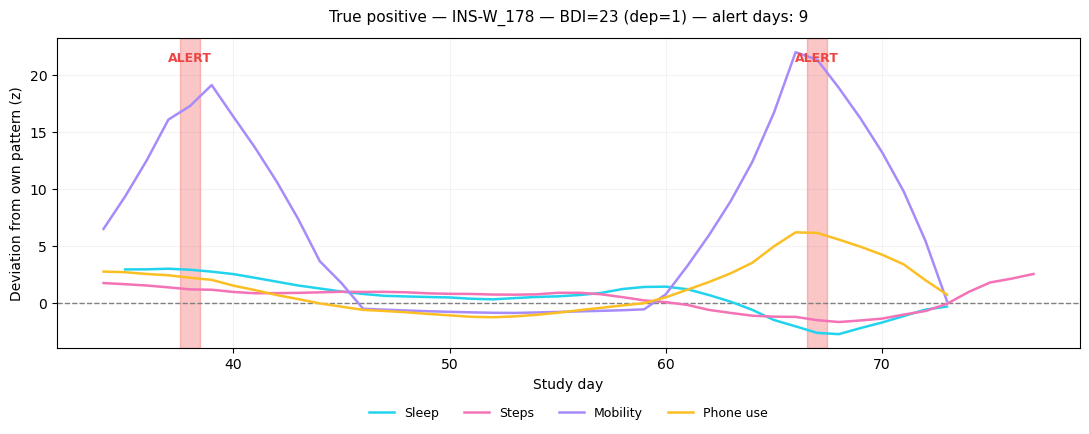

In [115]:
draw_trajectory(pid_TP, "True positive")

La trayectoria muestra dos episodios claramente diferenciados. En el primero, en torno a los días 37-41, la movilidad de la persona sube fuertemente alcanzando un z cercano a 19 (un pico fuera del rango habitual de las otras señales), mientras el resto de dimensiones se mantiene en una banda moderada en torno a +1 o +2. La regla del Bloque 5 dispara aquí porque el dominio de activación se mantiene desviado más de cinco días seguidos y converge con al menos uno de los otros dos dominios.

Entre los días 45 y 60 la trayectoria se calma: las cuatro señales oscilan próximas a cero. Esto es lo esperable para un periodo sin alerta: no hay convergencia sostenida que la regla pueda interpretar como cambio.

En torno al día 67 arranca la segunda racha. La movilidad vuelve a dispararse, esta vez con un pico aún más extremo (z cercano a 22), acompañada esta vez de **un patrón distinto**: el uso del móvil sube también de forma marcada (a z≈6), el sueño cae a z≈-2.7 y los pasos caen ligeramente a z≈-1.5. La forma del segundo episodio es claramente distinta a la del primero: en el primero la desviación es predominantemente de movilidad; en el segundo se desvían a la vez las cuatro señales, con dirección opuesta entre la activación (al alza) y el sueño (a la baja).

Lo que la figura demuestra es que el sistema **no se limita a detectar magnitud absoluta**: detecta que durante cinco o más días seguidos al menos dos de los tres dominios convergen en haberse separado del patrón propio. Las dos rachas de esta persona aparecen porque cumplen ese criterio en dos ventanas distintas del seguimiento. La regla, vista en una persona concreta, opera tal y como se construyó en el Bloque 5.

##### **Falso positivo: INS-W_120**

Persona con BDI final de 0 (dep=0) y nueve días-alerta consecutivos. Según el argumento del Bloque 6.2, los 30 FP del sistema no son errores de detección sino desviaciones conductuales reales y sostenidas que no se han traducido al BDI al final del estudio. El caso individual permite verificarlo.

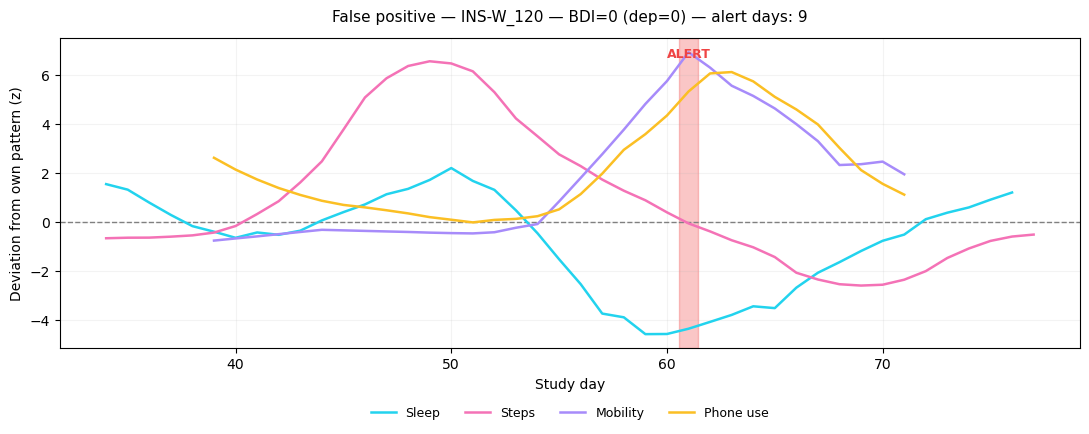

In [116]:
draw_trajectory(pid_FP, "False positive")

La trayectoria de esta persona contradice de manera contundente la lectura ingenua del FP como "error del sistema". En torno a los días 50-65 se observa un cambio conductual de magnitud extraordinaria. Primero los pasos suben hasta un z cercano a +6.5 (día 50); después caen, mientras el uso del móvil y la movilidad se disparan hasta picos próximos a +6 (día 62, en la banda de alerta) y el sueño se desploma hasta z≈-4.5. Las cuatro señales se separan a la vez, en magnitudes muy alejadas del patrón propio de la persona.

La regla dispara porque al menos dos de los tres dominios cumplen los cinco días consecutivos con convergencia. Lo que el sistema detectó es real: esta persona vivió, en esa ventana, un cambio conductual muy sostenido respecto a su línea base.

Lo que no ocurrió es que ese cambio se tradujera al BDI: terminó el cuestionario con un 0, el valor mínimo posible. Esa desconexión entre la desviación conductual y el desenlace clínico es justo lo que el Bloque 6 cuantificó sobre toda la cohorte como asociación débil. La figura lo aclara visualmente: la debilidad no viene de que el sistema ``se invente`` alertas, sino de que **detectar desviación conductual sostenida no es lo mismo que detectar depresión clínica**. La regla hace bien su trabajo, marca a quien se desvía de su patrón; lo que no puede garantizar es que esa desviación signifique síntomas depresivos al final del seguimiento.

##### **Falso negativo: INS-W_156**

Persona con BDI final de 46 (el más alto del grupo de FN) y cero días-alerta. Según el argumento del Bloque 6.2, 24 de los 26 FN son personas que mostraron desviaciones conductuales puntuales que la regla descartó deliberadamente por no sostenerse cinco días consecutivos con convergencia 2/3. El caso individual permite verlo. 

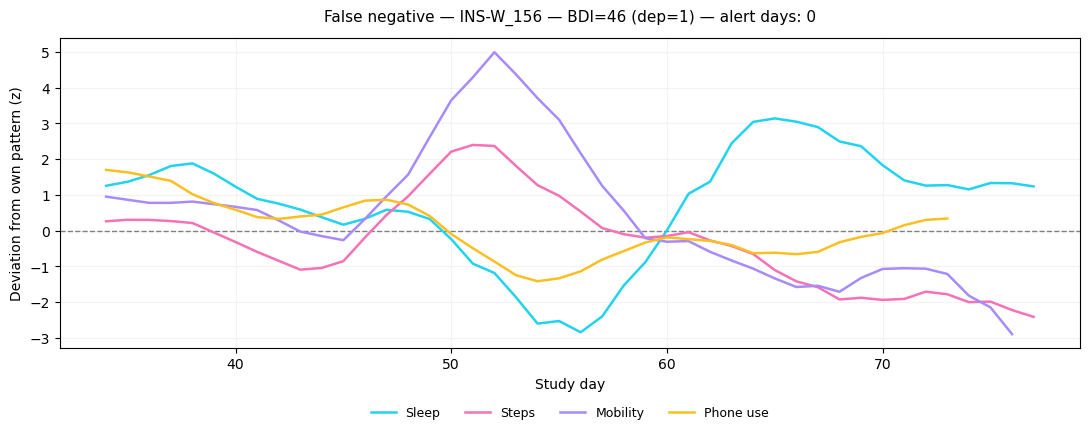

In [117]:
draw_trajectory(pid_FN, "False negative")

La trayectoria muestra desviaciones puntuales claras en cada dimensión, pero ninguna se sostiene cinco días consecutivos junto con otras dos.

Los picos están repartidos en el tiempo, no alineados: hacia el día 52 la movilidad sube a z≈+5 y los pasos a z≈+2.5, mientras el sueño va cayendo hacia su mínimo de z≈-2.7, que alcanza unos días después (54-55). Más tarde, hacia los días 64-66, el sueño sube a un máximo de z≈+3 mientras las otras tres señales están moderadamente por debajo de cero.

Las desviaciones existen, son visibles y son consistentes con la imagen de una persona cuya conducta no es estable. Lo que no aparece nunca es un tramo en el que al menos dos dominios cumplan a la vez los cinco días seguidos con convergencia: los picos de movilidad caen en unos días, los de sueño en otros, los descensos de pasos en otros más. La regla del Bloque 5 está construida precisamente para no activarse ante esto: prioriza la especificidad y exige una credibilidad estructural en la convergencia.

La figura permite ver con claridad el trade-off documentado en el Bloque 5: el sistema, calibrado a 2,0/5, prefiere dejar pasar casos donde la conducta varía sin un patrón estable antes que generar alertas sobre desviaciones aisladas. Esta persona, pese a su BDI de 46, es uno de esos casos.

### 8.3. Cierre del Bloque 8

``¿Qué construye el bloque?``

Una capa de análisis individual que baja del dato del conjunto al caso concreto. Sobre los cuatro cuadrantes definidos por el cruce entre alerta del sistema y BDI≥14, se elige un representante de cada uno de los tres relevantes y se inspecciona su trayectoria de las cuatro señales conductuales con la marca temporal de cada alerta disparada. El formato gráfico replica el lenguaje visual del portfolio público del proyecto para mantener continuidad entre las dos capas de presentación.

``¿Cómo se decidió la selección de los tres casos?``

Los tres representantes se eligen por su capacidad de ilustrar visualmente los argumentos abiertos en bloques anteriores. INS-W_178 se selecciona por presentar dos rachas separadas, lo que ilustra que el sistema detecta episodios múltiples en una misma persona, y por ser el participante por defecto del portfolio público, lo que mantiene continuidad. INS-W_120 se selecciona por ser el contraste más extremo posible en el cuadrante FP (nueve días-alerta sobre una persona con BDI=0). INS-W_156 se selecciona por ser el caso más extremo del cuadrante FN (BDI=46 con cero alertas).

``¿Qué muestran los datos?``

Las tres trayectorias confirman visualmente lo que las métricas del conjunto del Bloque 6 ya señalaban.

El **verdadero positivo** muestra cómo es una alerta del sistema vista a escala individual: convergencia sostenida en al menos dos dominios durante al menos cinco días. INS-W_178 lo presenta en dos episodios temporalmente separados con formas distintas entre sí.

El **falso positivo** verifica que los 30 FP del Bloque 6.2 no son errores de detección. INS-W_120 muestra una desviación conductual de magnitud extraordinaria, con las cuatro señales separándose a la vez de su patrón propio; el sistema detecta algo real. Lo que la regla no puede asegurar es que esa desviación conductual signifique síntomas depresivos al final del seguimiento.

El **falso negativo** verifica que los 24 FN no son fallos del sistema sino consecuencia directa del filtro de credibilidad de la regla. INS-W_156 presenta desviaciones puntuales claras en cada dimensión, pero ninguna convergente con otra durante cinco días seguidos. La regla, calibrada a 2,0/5, prioriza especificidad y descarta deliberadamente este tipo de patrón.

El Bloque 8 cierra la fase de Evaluación con una capa de inspección individual que sirve a dos audiencias: la audiencia técnica que reconoce en las trayectorias la lógica de la regla en acción y la audiencia clínica que necesita ver el caso concreto sobre el que se actuaría. Ambas leen el mismo gráfico con propósitos distintos pero compatibles.

---
## Cierre del proyecto

Este cuaderno ha construido, de principio a fin, un sistema de detección de desviación conductual sostenida a partir de datos pasivos de wearable y móvil. No es un predictor de depresión: es un detector que avisa cuando una persona se aparta de su propio patrón habitual de forma sostenida y en varios frentes a la vez, para que un terapeuta pueda interpretar ese cambio en su contexto.

El recorrido ha pasado por ocho bloques encadenados:

- **Bloque 1 — Viabilidad.** Se auditó la fuente de datos y se eligió la cohorte INS-W_1 de GLOBEM (155 participantes, 92 días, pre-COVID), priorizando una muestra pequeña y limpia frente a uno mayor con distorsión externa. Sin densidad, duración y estructura suficientes, todo lo demás sería especulación.

- **Bloque 2 — Baseline individual.** Se construyó, para cada persona y dimensión, un patrón de referencia propio: la media y la desviación típica de sus 21 días previos, calculadas con un desfase que evita contaminar la referencia con el presente.

- **Bloque 3 — Z-score intra-sujeto.** Se midió cuánto se aparta cada persona de su propio patrón, no de una población. Una desviación de la misma magnitud no significa lo mismo en dos personas distintas: cada una se compara consigo misma.

- **Bloque 4 — Estructura temporal.** Se descubrió que la dependencia entre días consecutivos del z-score es un artefacto del baseline, no señal conductual. La información relevante no está en la relación entre días, sino en el nivel sostenido del z-score a lo largo del tiempo.

- **Bloque 5 — La regla.** Se definió el sistema: un umbral de 2,0 sobre la desviación sostenida, persistencia de cinco días consecutivos y convergencia en al menos dos de los tres dominios (sueño, activación, uso pasivo). El resultado son 186 días-alerta en 56 personas. El umbral se eligió priorizando la credibilidad ante el terapeuta sobre el volumen de alertas.

- **Bloque 6 — Modelado.** Se comprobó que las cuatro señales conductuales contienen información suficiente (AUC 0,832 anticipando la propia alerta) y que ningún modelo supervisado supera a la regla en su relación con el desenlace clínico. Se caracterizaron las alertas en tres patrones y se construyó el aviso que el sistema entregaría al terapeuta.

- **Bloque 7 — Validación.** Se demostró que las alertas son señal real y no artefacto: el sistema no se activa sobre datos sin estructura conductual, dos técnicas independientes (CUSUM y EWMA) corroboran el 100% de los episodios, y los avisos llegan frescos, con el episodio en curso o recién terminado.

- **Bloque 8 — Caso individual.** Se bajó del dato del conjunto a la persona concreta, mostrando sobre tres trayectorias reales (un verdadero positivo, un falso positivo y un falso negativo) por qué el sistema acierta al marcar o al no marcar, y haciendo visible la diferencia entre detectar desviación conductual y detectar depresión clínica.

El hilo que atraviesa los ocho bloques es uno solo: medir el comportamiento de cada persona contra sí misma, no contra una población, y avisar solo cuando el cambio es sostenido, convergente y creíble. El sistema renuncia deliberadamente a detectar cambios incipientes o aislados a cambio de que cada aviso que emite corresponda a un episodio conductual real y verificable.

Con esto se cierra el trabajo de análisis y construcción del sistema. Lo que queda por delante pertenece a una fase distinta y posterior: llevar el sistema a un uso real con pacientes, donde una prueba piloto deberá determinar si estos avisos resultan clínicamente útiles en la práctica, y definir el protocolo de qué hacer cuando una alerta llega al terapeuta. Esa validación con personas reales es la continuación natural de este cuaderno, y la que dirá si el sistema, que aquí ha demostrado ser internamente sólido, aporta valor en la consulta.